# Cap. 4 — Métodos lineales para clasificación

📕 *The Elements of Statistical Learning* (Hastie, Tibshirani & Friedman), cap. 4 · págs. impresas 101–138

Este notebook explica el capítulo completo, con la cuenta hecha paso a paso y código que corre. Notación: la de ESL.

## Mapa del capítulo

| Sección | Tema | Idea central |
|---|---|---|
| 4.1 | Introducción | Clasificar = partir el espacio con fronteras; "lineal" quiere decir frontera lineal |
| 4.2 | Regresión sobre matriz indicadora | La forma más ingenua; falla por *masking* |
| 4.3 | LDA y QDA | Modelo generativo gaussiano; frontera lineal (Σ común) o cuadrática |
| 4.3.1–4.3.3 | RDA, cómputo de LDA, rango reducido | Regularizar, esferizar, proyectar a ≤ K−1 dimensiones |
| 4.4 | Regresión logística | Modelo discriminativo; ajuste por IRLS; inferencia; L1 |
| 4.5 | Hiperplanos separadores | Perceptrón y margen óptimo (puente a SVM) |
| Ejercicios 4.1–4.9 | Complementos del libro | Los citamos donde aparecen: 4.1 y 4.8 en §4.3.3, 4.2 en §4.3, 4.3 en el cierre de §4.3.3, 4.4 en §4.4.1, 4.5 en §4.4.5 y 4.6 en §4.5.1. No desarrollamos el 4.7 (sumar $D^*$ sobre todas las observaciones con $\|\beta\|=1$) ni el 4.9 (programar QDA sobre las vocales), y tampoco las notas bibliográficas |

Los datos de los libros (South African Heart Disease, vowel) no están en el repo: donde hace falta, los ejemplos usan datos simulados o de `sklearn`, y el texto lo aclara.

In [1]:
# Setup
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## 4.1 Introducción: qué quiere decir "método lineal de clasificación"

📕 ESL §4.1 (págs. impresas 101–103)

> **Pregunta guía:** ¿qué significa que un clasificador sea lineal, y alcanza con que la *frontera* lo sea?

#### La idea en criollo

Hasta acá, en la regresión, la salida $Y$ era un número. Ahora la salida es una **etiqueta**: un elemento de un conjunto discreto de $K$ clases, que ESL llama $\mathcal{G}$ y numera $1, 2, \dots, K$. Nuestro predictor, $G(x)$, dice a qué clase pertenece un punto $x$.

Como $G(x)$ solo toma valores discretos, siempre podemos pensar que **partió el espacio de entrada en regiones**, una por clase. Lo que separa una región de otra es la **frontera de decisión**. En el capítulo 2 vimos que esas fronteras pueden ser rugosas (k-vecinos) o suaves (un modelo lineal).

Un método es **lineal para clasificación** cuando esas fronteras son hiperplanos: rectas en 2D, planos en 3D, y así. Nada más que eso. El capítulo entero trata de *distintas maneras de encontrar* esos hiperplanos, y las diferencias entre métodos están en **cómo se ajusta** la función lineal a los datos, no en la forma de la frontera.

> **Analogía: las fronteras entre provincias dibujadas con regla.** Si el mapa de un país se dividiera con líneas rectas, cada punto del mapa caería en una región y las regiones se tocarían a lo largo de segmentos rectos. Eso es un clasificador lineal con varias clases.
>
> **Dónde se rompe:** en un mapa de provincias las regiones las dibuja alguien a mano. Acá las rectas salen de comparar $K$ funciones ajustadas a los datos, y distintos métodos de ajuste dan rectas distintas para **los mismos datos**. El problema real es elegir bien el método de ajuste, no dibujar rectas.

#### Formalizándolo

##### Frontera a partir de funciones ajustadas

En el capítulo 2 ajustamos un modelo lineal a cada variable indicadora de clase y clasificamos a la clase con mayor valor ajustado. Escribimos el modelo ajustado para la clase $k$ como

$$\hat f_k(x) = \hat\beta_{k0} + \hat\beta_k^T x,$$

donde $\hat\beta_{k0}$ es el intercepto estimado (un número) y $\hat\beta_k$ el vector de coeficientes estimados (uno por variable de entrada). El sombrero indica que son estimados a partir de los datos.

La frontera entre las clases $k$ y $\ell$ es el conjunto de puntos donde ambas funciones empatan, $\hat f_k(x) = \hat f_\ell(x)$. Pasamos todo a un lado (restamos) y queda:

$$\{x : (\hat\beta_{k0} - \hat\beta_{\ell 0}) + (\hat\beta_k - \hat\beta_\ell)^T x = 0\}.$$

Fijate qué es esto: un número más un producto interno con un vector fijo, igualado a cero. Es la ecuación de un **conjunto afín** (un hiperplano que no necesita pasar por el origen). ESL aclara en una nota al pie que, estrictamente, un hiperplano pasa por el origen y un conjunto afín no, pero que a veces se ignora la diferencia. Como lo mismo vale para **cada par** de clases, el espacio queda partido en regiones de clasificación constante, con fronteras **lineales por tramos**.

##### Funciones discriminantes y posteriores

Este enfoque es un caso de una familia: modelar una **función discriminante** $\delta_k(x)$ por clase y clasificar $x$ a la clase con mayor $\delta_k(x)$. Otra familia modela las **probabilidades posteriores** $\Pr(G = k \mid X = x)$ (la probabilidad de pertenecer a la clase $k$ sabiendo que observamos $x$). Si $\delta_k(x)$ o $\Pr(G = k \mid X = x)$ son lineales en $x$, las fronteras son lineales.

Pero alcanza con menos: **alguna transformación monótona** de $\delta_k$ o del posterior tiene que ser lineal. (Una transformación monótona no cambia *cuál* de dos valores es mayor, así que no mueve la frontera.)

¿Por qué alcanza con el orden? Porque la regla óptima (Bayes, clase 1) es $\hat G(x)=\arg\max_k \Pr(G=k\mid X=x)$: solo importa **cuál** posterior es mayor, no su valor. Cualquier transformación monótona de los posteriores da el mismo $\arg\max$, así que alcanza con que su **ranking** quede descrito por funciones lineales.

##### El ejemplo de dos clases: la logit

Para dos clases, un modelo popular para los posteriores es

$$\Pr(G = 1 \mid X = x) = \frac{\exp(\beta_0 + \beta^T x)}{1 + \exp(\beta_0 + \beta^T x)}, \qquad \Pr(G = 2 \mid X = x) = \frac{1}{1 + \exp(\beta_0 + \beta^T x)}. \tag{4.1}$$

Las dos probabilidades suman 1 (mismo denominador, numeradores $e^{z}$ y $1$ con $z = \beta_0 + \beta^T x$). Dividimos una por la otra: el denominador común se cancela y queda $e^{z}$. Tomando logaritmo:

$$\log \frac{\Pr(G = 1 \mid X = x)}{\Pr(G = 2 \mid X = x)} = \beta_0 + \beta^T x. \tag{4.2}$$

La transformación $\log[p/(1-p)]$ es la **logit**, y al logaritmo del cociente de probabilidades se lo llama **log-odds**. Acá la transformación monótona que se vuelve lineal es la logit. La frontera es donde las dos clases son igual de probables: cociente igual a 1, log-odds igual a cero, es decir el hiperplano $\{x \mid \beta_0 + \beta^T x = 0\}$.

##### Generalizar sin salir de lo lineal

Que todo el capítulo hable de fronteras lineales no es tan restrictivo como parece. Podemos **ampliar** las variables $X_1, \dots, X_p$ agregando sus cuadrados y productos cruzados $X_1^2, X_2^2, \dots, X_1 X_2, \dots$. Son $p(p+1)/2$ variables nuevas. Una función **lineal en el espacio ampliado** es una función **cuadrática en el espacio original**, y entonces una frontera lineal ahí es una frontera cuadrática acá.

La Figura 4.1 de ESL lo ilustra con los mismos datos de tres clases: a la izquierda, fronteras lineales (por LDA) en las 2 dimensiones originales; a la derecha, fronteras lineales en el espacio de cinco dimensiones $X_1, X_2, X_1X_2, X_1^2, X_2^2$, que en el plano original se ven curvas. Esto se generaliza a cualquier **transformación de base** $h(X)$ con $h : \mathbb{R}^p \to \mathbb{R}^q$ y $q > p$, tema de capítulos posteriores.

#### ¿Por qué nos importa?

Porque fija el vocabulario del capítulo entero y previene una confusión frecuente: "lineal" habla de **la forma de la frontera** (un hiperplano) o, más exactamente, de que **algo** (una función, o una transformación monótona del posterior) es lineal en las variables. No habla de que los datos sean linealmente separables ni de que el método sea "simple".

Además es el truco más barato para conseguir flexibilidad: si una frontera lineal no alcanza, **no cambiás de método, cambiás de variables**. Vas a ver el mismo truco en regresión polinómica, en splines y en el kernel de las SVM.

#### En código

Reproducimos el fenómeno de la Figura 4.1: tres clases simuladas con LDA en las variables originales (fronteras rectas) y LDA en el espacio ampliado con $X_1^2, X_2^2, X_1X_2$ (fronteras curvas en el plano original). Usamos `LinearDiscriminantAnalysis` de sklearn porque, por ahora, lo único que nos interesa es la forma de las fronteras (la derivación de LDA llega en §4.3).

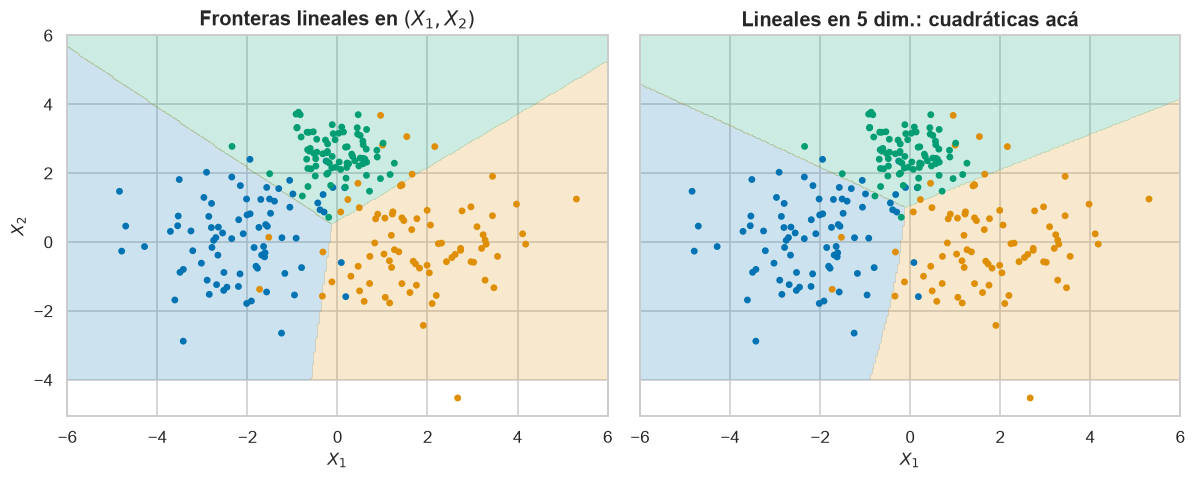

Error de entrenamiento lineal / ampliado: 0.104 0.083


In [2]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import PolynomialFeatures

rng_41 = np.random.default_rng(0)
# Tres nubes: dos con mucha dispersion y la de arriba mas chica, para que la curvatura ayude.
centros_41 = np.array([[-2.0, 0.0], [2.0, 0.0], [0.0, 2.5]])
escalas_41 = np.array([1.2, 1.2, 0.6])
X_41 = np.vstack([c + e * rng_41.standard_normal((80, 2)) for c, e in zip(centros_41, escalas_41)])
g_41 = np.repeat([0, 1, 2], 80)

# poly2 agrega X1^2, X1*X2, X2^2 (sin la columna de unos: LDA ya tiene intercepto).
poly_41 = PolynomialFeatures(2, include_bias=False)
lda_lin_41 = LinearDiscriminantAnalysis().fit(X_41, g_41)
lda_cuad_41 = LinearDiscriminantAnalysis().fit(poly_41.fit_transform(X_41), g_41)

u_41, v_41 = np.meshgrid(np.linspace(-6, 6, 300), np.linspace(-4, 6, 300))
malla_41 = np.c_[u_41.ravel(), v_41.ravel()]
pred_41 = [lda_lin_41.predict(malla_41), lda_cuad_41.predict(poly_41.transform(malla_41))]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
titulos_41 = ["Fronteras lineales en $(X_1, X_2)$", "Lineales en 5 dim.: cuadráticas acá"]
for ax, p, t in zip(axes, pred_41, titulos_41):
    ax.contourf(u_41, v_41, p.reshape(u_41.shape), alpha=0.2, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=sns.color_palette("colorblind", 3))
    ax.scatter(*X_41.T, c=[sns.color_palette("colorblind")[i] for i in g_41], s=12)
    ax.set_title(t); ax.set_xlabel("$X_1$")
axes[0].set_ylabel("$X_2$")
plt.tight_layout(); plt.show()
print("Error de entrenamiento lineal / ampliado:",
      (lda_lin_41.predict(X_41) != g_41).mean().round(3),
      (lda_cuad_41.predict(poly_41.transform(X_41)) != g_41).mean().round(3))

A la izquierda las tres regiones se tocan en rectas. A la derecha las mismas tres clases, con el **mismo método** (LDA, que sigue buscando fronteras lineales), tienen fronteras curvas, porque la linealidad vive en el espacio de cinco variables. Como la nube de arriba es más compacta que las de los costados, una frontera curva la rodea mejor y el error de entrenamiento baja un poco (de 0,10 a 0,08 en esta semilla; la ganancia es modesta porque los datos son casi lineales).

#### ⚠️ Confusión típica

Creer que "método lineal" significa "solo sirve si las clases se separan con una recta". Lo lineal es la **frontera en el espacio donde el método trabaja**. Si ampliás ese espacio con cuadrados y productos cruzados, el mismo método lineal dibuja fronteras curvas en el espacio original, como en la figura de arriba.

Segunda confusión: pensar que la frontera de un modelo de $K$ clases es *un* hiperplano. Es **lineal por tramos**: entre cada par de clases hay un hiperplano, y las regiones quedan delimitadas por los trozos que realmente son frontera de dos clases vecinas.

## 4.2 Regresión lineal de una matriz indicadora

📕 ESL §4.2 (págs. impresas 103–107)

> **Pregunta guía:** ¿se puede clasificar regresando las indicadoras de clase, y cuándo deja de funcionar?

#### La idea en criollo

Es el método más ingenuo de clasificación lineal, y por eso es el mejor punto de partida. Si la regresión sabe predecir un número, y las clases son etiquetas, **convertimos las etiquetas en números**: para cada clase armamos una columna de ceros y unos que vale 1 si la observación es de esa clase. Ajustamos una regresión lineal por columna. Para un punto nuevo miramos las $K$ predicciones y gana la clase con la predicción más alta.

Respuesta corta: **anda razonablemente con 2 clases y falla de una manera específica y fea con 3 o más**: el *enmascaramiento* (masking).

> **Analogía: $K$ jueces independientes, cada uno con una regla rígida.** Cada juez mira un punto y puntúa "qué tan de mi clase parece". Gana el juez con mayor puntaje.
>
> **Dónde se rompe:** los jueces no se enteran unos de otros y cada uno solo puede puntuar con una recta. Si una clase queda *en el medio* de las otras, su juez solo dispone de una recta que, por simetría, queda casi plana y baja, y nunca supera a los puntajes de los jueces de los extremos.

#### Formalizándolo

##### La matriz indicadora y el ajuste

Si $G$ tiene $K$ clases, definimos $K$ **variables indicadoras** $Y_k$, con $k = 1, \dots, K$:

$$Y_k = 1 \text{ si } G = k, \qquad Y_k = 0 \text{ en otro caso.}$$

Las juntamos en el vector $Y = (Y_1, \dots, Y_K)$. Con los $N$ casos de entrenamiento armamos la **matriz de respuesta indicadora** $\mathbf{Y}$, de tamaño $N \times K$: todo ceros y unos, con **un único 1 por fila** (la columna de la clase de esa observación).

Ajustamos una regresión lineal a **cada columna** de $\mathbf{Y}$ a la vez. Con $\mathbf{X}$ la matriz de diseño, $N \times (p+1)$, con una primera columna de unos para el intercepto, el ajuste es

$$\hat{\mathbf{Y}} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}. \tag{4.3}$$

Es la misma fórmula del capítulo 3 (ESL §3.2), pero con $\mathbf{y}$ reemplazado por una matriz. Cada columna de $\mathbf{Y}$ tiene su propio vector de coeficientes, así que los coeficientes forman una matriz $\hat{\mathbf{B}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}$ de tamaño $(p+1) \times K$. (Multiplicar $(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$ por $\mathbf{Y}$ aplica la misma operación a cada columna por separado.)

**Regla de clasificación** para una observación nueva con entrada $x$:

1. Calculamos el **vector ajustado** $\hat f(x)^T = (1, x^T)\hat{\mathbf{B}}$, un vector de $K$ componentes.
2. Nos quedamos con la componente más grande:

$$\hat G(x) = \arg\max_{k \in \mathcal{G}} \hat f_k(x). \tag{4.4}$$

($\arg\max$ quiere decir "el $k$ donde se alcanza el máximo", no el valor del máximo.)

> 🔗 **Conexión con las clases 2 y 3**: (4.3) es la ecuación normal de la clase 2 con $\mathbf{y}$ reemplazado por una matriz, o sea $\hat{\mathbf{Y}}=\mathbf{H}\mathbf{Y}$ con la **misma** matriz sombrero $\mathbf{H}=\mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$ (§3 de la clase 2; $UU^T$ en términos de la SVD de la clase 3): proyecta cada columna de $\mathbf{Y}$ sobre el mismo subespacio, porque $\mathbf{H}$ solo depende de $\mathbf{X}$.

##### ¿Con qué justificación? Del posterior al indicador

Hasta acá armamos la receta (regresar cada columna de $\mathbf{Y}$ y elegir el $\arg\max$). Falta ver por qué debería funcionar. El hilo tiene cuatro eslabones.

**1. Bayes dice que hay que mirar el posterior.** El clasificador óptimo es $\hat G(x)=\arg\max_k \Pr(G=k\mid X=x)$. Si tuviéramos los posteriores, terminamos.

**2. El indicador esconde el posterior.** Como $Y_k$ vale 1 o 0,

$$E(Y_k \mid X = x) = 1\cdot\Pr(G=k\mid X=x) + 0\cdot\Pr(G\neq k\mid X=x) = \Pr(G = k \mid X = x).$$

Regresar $Y_k$ sobre $x$ apunta, entonces, al posterior de la clase $k$.

**3. Pero OLS no estima el posterior: estima su mejor aproximación lineal.** Mínimos cuadrados busca, entre las funciones lineales en $x$, la más cercana a $E(Y_k\mid x)$ en el sentido $L_2$. Un posterior es una probabilidad y queda acotado en $[0,1]$; una recta no se acota nunca. Por eso los $\hat f_k(x)$ pueden salirse de $[0,1]$, sobre todo lejos de los datos (fuera de la **envoltura convexa** de entrenamiento). Es el costo de la rigidez, y lo que plantea ESL: ¿son buenas estimaciones y, sobre todo, importa que lo sean?

**4. Suman 1, pero no son probabilidades.** Con intercepto, $\mathbf{1}_N$ es una columna de $\mathbf{X}$, así que $\mathbf{H}\mathbf{1}_N=\mathbf{1}_N$ ($\mathbf{H}$ deja fijo todo lo que ya está en el espacio columna). Y como cada fila de $\mathbf{Y}$ tiene un único 1, $\mathbf{Y}\mathbf{1}_K=\mathbf{1}_N$:

$$\hat{\mathbf{Y}}\mathbf{1}_K=\mathbf{H}\mathbf{Y}\mathbf{1}_K=\mathbf{H}\mathbf{1}_N=\mathbf{1}_N.$$

Para un $x$ nuevo vale igual: $\hat{\mathbf{B}}\mathbf{1}_K=e_0$ (con $e_0=(1,0,\dots,0)^T$) y $(1,x^T)e_0=1$. Sin intercepto la propiedad se cae. Pero sumar 1 no alcanza para ser probabilidad: pueden ser negativos o mayores que 1.

**Entonces, ¿importa que se salgan de $[0,1]$?** Para clasificar, no: usamos solo el $\arg\max$ (es lo que dijimos en §4.1 sobre las transformaciones monótonas: solo importa el ranking), y alcanza con que el **orden** entre las $\hat f_k$ sea el correcto aunque los valores estén mal. El método se rompe únicamente si el **ranking se invierte**, es decir, si la clase correcta no queda arriba. Y eso pasa, de manera sistemática, con el enmascaramiento (más abajo). ESL aclara además que estas violaciones no garantizan que el método falle, y que con regresión sobre **expansiones de base** $h(X)$ puede dar estimaciones consistentes de los posteriores (capítulo 5).

> 🔗 **Conexión con las clases 1 y 2**: es la cuenta de la clase 1 (§4) para una $Y$ binaria. Como bajo pérdida cuadrática el óptimo es la media condicional (clase 1, §8), regresar el indicador es la "opción 3" de ese §8; lo que agrega la clase 2 es el supuesto de que esa esperanza es lineal en $x$.

##### Segundo punto de vista: reproducir el objetivo

Otra forma de ver lo mismo: a cada clase le asignamos un **objetivo** $t_k$, la $k$-ésima columna de $I_K$, ajustamos por cuadrados mínimos y clasificamos al objetivo más cercano:

$$\min_{\mathbf{B}} \sum_{i=1}^N \| y_i - [(1, x_i^T)\mathbf{B}]^T \|^2, \tag{4.5} \qquad\qquad \hat G(x) = \arg\min_k \|\hat f(x) - t_k\|^2. \tag{4.6}$$

Da exactamente lo mismo que (4.4) por dos razones. **(i)** La norma al cuadrado es una suma sobre componentes, así que el criterio se parte en $K$ regresiones independientes: nada en el modelo liga las respuestas, y el valor de (4.5) es la suma de los $K$ $RSS$ de la clase 2, uno por columna. **(ii)** $\|\hat f - t_k\|^2 = \sum_j \hat f_j^2 - 2\hat f_k + 1$, y solo $-2\hat f_k$ depende de $k$: minimizar la distancia es maximizar $\hat f_k$.

#### ¿Por qué nos importa?

Es la vara de comparación del capítulo. Se implementa con un solo ajuste de cuadrados mínimos, y sus fallas son instructivas: explican por qué **hacen falta** LDA y regresión logística. La idea de codificar clases como objetivos vectoriales sirve para entender qué hace cada método con las mismas salidas.

#### En código

Primero, a mano con numpy: matriz indicadora, $\hat{\mathbf{B}}$ por cuadrados mínimos, las tres propiedades (suma 1, valores fuera de $[0, 1]$, equivalencia argmax/argmin) y, al final, la versión de librería. Usamos los mismos datos de tres clases que armamos en §4.1.

In [3]:
K_42 = 3
N_42 = len(g_41)
X_42 = np.c_[np.ones(N_42), X_41]                  # columna de unos para el intercepto
Y_42 = np.eye(K_42)[g_41]                          # matriz indicadora N x K: un 1 por fila

# B_hat = (X^T X)^{-1} X^T Y, pero con lstsq para no invertir nada (ver §3.2 de ESL).
B_42, *_ = np.linalg.lstsq(X_42, Y_42, rcond=None)  # (p+1) x K: una columna de coef. por clase
Yhat_42 = X_42 @ B_42                               # ajuste (4.3)

print("forma de Y:", Y_42.shape, "| forma de B:", B_42.shape)
print("filas de Y suman 1:", np.allclose(Y_42.sum(axis=1), 1))
print("filas de Y_hat suman 1 (hay intercepto):", np.allclose(Yhat_42.sum(axis=1), 1))
print(f"rango de f_hat: [{Yhat_42.min():.2f}, {Yhat_42.max():.2f}]  "
      f"-> fuera de [0,1]: {((Yhat_42 < 0) | (Yhat_42 > 1)).mean():.1%} de las entradas")

G_argmax_42 = Yhat_42.argmax(axis=1)                              # regla (4.4)
G_target_42 = ((Yhat_42[:, None, :] - np.eye(K_42)) ** 2).sum(-1).argmin(axis=1)  # regla (4.6)
print("(4.4) == (4.6):", np.array_equal(G_argmax_42, G_target_42))
print("error de entrenamiento:", (G_argmax_42 != g_41).mean().round(3))

forma de Y: (240, 3) | forma de B: (3, 3)
filas de Y suman 1: True
filas de Y_hat suman 1 (hay intercepto): True
rango de f_hat: [-0.84, 1.50]  -> fuera de [0,1]: 21.9% de las entradas
(4.4) == (4.6): True
error de entrenamiento: 0.088


##### 🏭 Así se hace en la industria

En sklearn, `LinearRegression` acepta una respuesta multi-columna y ajusta una regresión por columna. Es exactamente el $\hat{\mathbf{B}}$ de arriba (sklearn separa el intercepto, pero es el mismo modelo).

In [4]:
from sklearn.linear_model import LinearRegression

reg_42 = LinearRegression().fit(X_41, Y_42)        # sklearn agrega el intercepto solo
B_sk_42 = np.vstack([reg_42.intercept_, reg_42.coef_.T])  # apilamos para comparar con B_42
print("coeficientes iguales:", np.allclose(B_42, B_sk_42))
print("clasificaciones iguales:", np.array_equal(reg_42.predict(X_41).argmax(axis=1), G_argmax_42))

coeficientes iguales: True
clasificaciones iguales: True


#### El problema del enmascaramiento (masking)

Para $K \ge 3$ hay un problema serio, sobre todo cuando $K$ es grande. Por la rigidez del modelo, **unas clases pueden quedar enmascaradas por otras**. En las tres nubes de §4.1 no hay masking (error de entrenamiento 0,088 en la celda de la matriz indicadora): las clases no están alineadas. Las alineamos y aparece.

**La intuición, antes de la cuenta.** Pensá en tres clases alineadas sobre una recta, con la clase 2 *en el medio*. Su indicador $Y_2$ vale 1 solo en el tramo central y 0 a los dos lados: una "joroba". Una recta no puede hacer una joroba, y la que mejor ajusta por cuadrados mínimos queda casi **plana**, en torno a $1/3$. Las rectas de las clases 1 y 3, en cambio, suben y bajan, y salvo en el punto donde se cruzan las tres siempre una de las dos queda por encima de la plana. **La clase del medio nunca gana el $\arg\max$**: es el ranking invertido por rigidez que anticipamos en "¿Con qué justificación?". La Figura 4.2 de ESL muestra un caso extremo con $K = 3$: tres clases en $\mathbb{R}^2$ perfectamente separables con fronteras lineales, y sin embargo la regresión lineal de los indicadores **no encuentra nunca** la clase del medio (nunca domina). LDA, en cambio, separa las tres bien.

La Figura 4.3 lo explica en una dimensión. Se proyectan los datos sobre la recta que une los tres centroides (en ese ejemplo no hay información en la dirección ortogonal) y se codifican las tres respuestas $Y_1, Y_2, Y_3$. Las tres rectas de regresión salen así: la de la clase del medio es **horizontal** y sus valores ajustados **nunca son los mayores**, así que las observaciones de la clase 2 se clasifican como clase 1 o clase 3. Con regresión **cuadrática** en vez de lineal, el problema se resuelve en este ejemplo (error de entrenamiento 0,33 con grado 1 y 0,04 con grado 2 en la figura del libro; el error de Bayes es 0,025).

Reproducimos primero la Figura 4.3 (una dimensión, tres clases) con grados 1 y 2.

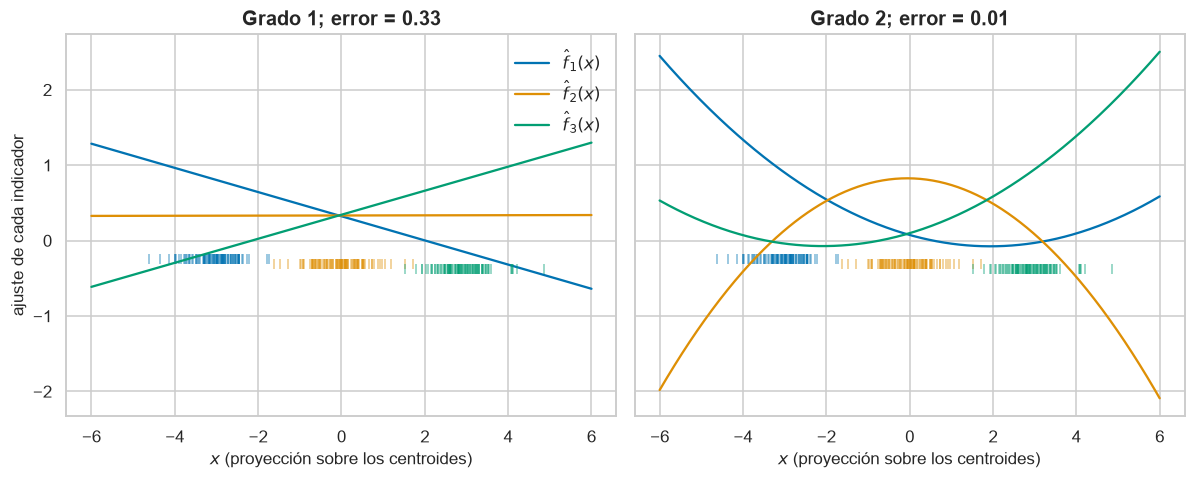

error de entrenamiento, grado 1 y grado 2: [0.333 0.013]


In [5]:
from sklearn.preprocessing import PolynomialFeatures as PF

def masking_1d_42(K, sep=3.0, n=100, sd=0.6, seed=1):
    # K clases alineadas en una recta, equiespaciadas y centradas en 0.
    r = np.random.default_rng(seed)
    centros = (np.arange(K) - (K - 1) / 2) * sep
    x = np.concatenate([c + sd * r.standard_normal(n) for c in centros])
    return x[:, None], np.repeat(np.arange(K), n)

def ajustar_42(x, g, grado):
    F = PF(grado, include_bias=False).fit_transform(x)   # 1, x, x^2, ... (regresion polinomica)
    m = LinearRegression().fit(F, np.eye(g.max() + 1)[g])  # una regresion por indicador
    return m, (m.predict(F).argmax(1) != g).mean()

x3_42, g3_42 = masking_1d_42(3)
xs_42 = np.linspace(-6, 6, 400)[:, None]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
errs_42 = []
for ax, d in zip(axes, [1, 2]):
    m, err = ajustar_42(x3_42, g3_42, d)
    errs_42.append(err)
    curvas = m.predict(PF(d, include_bias=False).fit_transform(xs_42))
    for k in range(3):
        ax.plot(xs_42, curvas[:, k], label=f"$\\hat f_{k+1}(x)$")
        ax.plot(x3_42[g3_42 == k], np.full((g3_42 == k).sum(), -0.25 - 0.06 * k), "|",
                color=sns.color_palette("colorblind")[k], alpha=0.5)   # rug plot
    ax.set_title(f"Grado {d}; error = {err:.2f}"); ax.set_xlabel("$x$ (proyección sobre los centroides)")
axes[0].set_ylabel("ajuste de cada indicador"); axes[0].legend()
plt.tight_layout(); plt.show()
print("error de entrenamiento, grado 1 y grado 2:", np.round(errs_42, 3))

A la izquierda, con grado 1, la recta de la clase 2 (la del medio) queda casi horizontal, en $\approx 1/3$: por simetría las tres rectas se cruzan en $x = 0$ en ese valor, y la clase 2 solo gana en un punto. A la derecha, con grado 2, la clase 2 tiene una parábola con un pico en el centro y las tres clases se separan. El error pasa de 0,33 (un tercio de las observaciones, toda la clase del medio) a cerca de 0,01 (el `print` da 0,333 y 0,013). Es el mismo fenómeno de la Figura 4.3, con datos simulados por nosotros.

**¿Y con más clases?** Según ESL, con $K = 4$ clases alineadas así una cuadrática ya no "baja" lo bastante rápido y se necesitaría una cúbica. La regla general, laxa: con $K \ge 3$ clases alineadas **pueden hacer falta términos polinómicos hasta grado $K-1$**, una cota del peor caso y no una garantía (con clases muy separadas puede alcanzar con menos). Son polinomios a lo largo de la dirección que pasa por los centroides, y esa dirección puede tener orientación arbitraria: en un espacio de entrada de dimensión $p$, resolver el peor caso exigiría términos polinómicos generales y productos cruzados de grado total $K-1$, o sea $O(p^{K-1})$ términos. Lo seguro es que **los grados bajos enmascaran**.

Por último, la versión bidimensional (Figura 4.2): tres clases en el plano a lo largo de una recta, separables, y las regiones de decisión de regresión lineal frente a las de LDA.

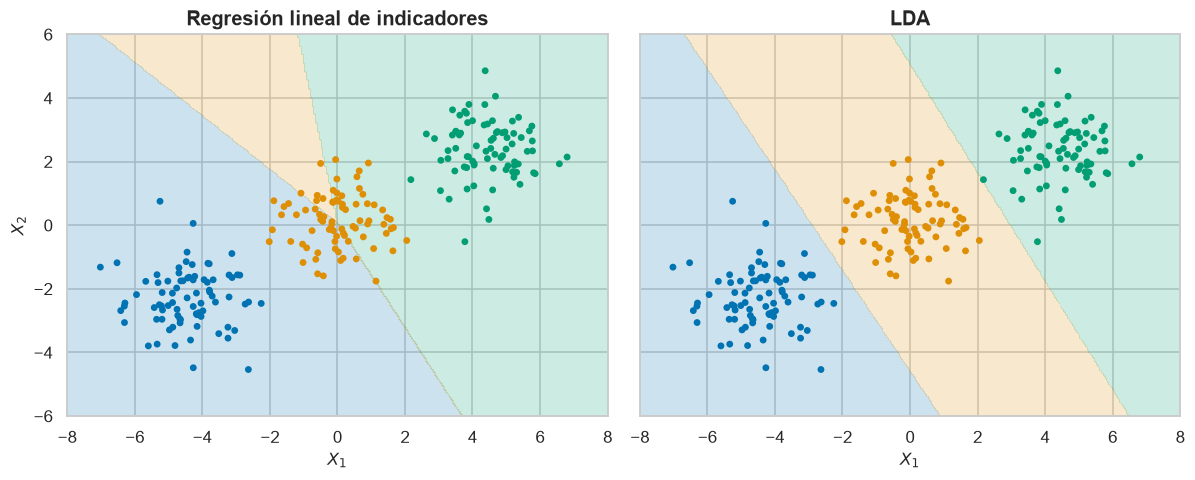

error regresión: 0.304 | error LDA: 0.0


In [6]:
rng_2d_42 = np.random.default_rng(3)
dir_42 = np.array([1.0, 0.5]) / np.hypot(1.0, 0.5)   # direccion sobre la que se alinean las clases
cent_42 = np.array([-5.0, 0.0, 5.0])[:, None] * dir_42
X2d_42 = np.vstack([c + 0.9 * rng_2d_42.standard_normal((80, 2)) for c in cent_42])
g2d_42 = np.repeat([0, 1, 2], 80)

reg2d_42 = LinearRegression().fit(X2d_42, np.eye(3)[g2d_42])
lda2d_42 = LinearDiscriminantAnalysis().fit(X2d_42, g2d_42)
a_42, b_42 = np.meshgrid(np.linspace(-8, 8, 300), np.linspace(-6, 6, 300))
M_42 = np.c_[a_42.ravel(), b_42.ravel()]
pcol_42 = sns.color_palette("colorblind", 3)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, pred, t in zip(axes, [reg2d_42.predict(M_42).argmax(1), lda2d_42.predict(M_42)],
                       ["Regresión lineal de indicadores", "LDA"]):
    ax.contourf(a_42, b_42, pred.reshape(a_42.shape), alpha=0.2, levels=[-0.5, 0.5, 1.5, 2.5], colors=pcol_42)
    ax.scatter(*X2d_42.T, c=[pcol_42[i] for i in g2d_42], s=12)
    ax.set_title(t); ax.set_xlabel("$X_1$")
axes[0].set_ylabel("$X_2$")
plt.tight_layout(); plt.show()
print("error regresión:", (reg2d_42.predict(X2d_42).argmax(1) != g2d_42).mean().round(3),
      "| error LDA:", (lda2d_42.predict(X2d_42) != g2d_42).mean().round(3))

En el panel de la izquierda la clase del medio casi no tiene región propia: la regresión la ignora, pese a que las tres nubes están bien separadas por rectas. En el panel de la derecha LDA dibuja tres regiones. Mismo dato, misma forma de frontera (lineal), distinto método de ajuste: es justamente lo que anunció §4.1.

#### Un caso realista: las vocales

ESL (Figura 4.4 y Tabla 4.1) usa datos de **reconocimiento de vocales**: $K = 11$ clases en $p = 10$ dimensiones, un problema difícil (los mejores métodos rondan el 40% de error en test). De las diez dimensiones, tres concentran el 90% de la varianza, o sea que las once clases viven casi en un subespacio chico.

| Método | Entrenamiento | Test |
|---|---|---|
| Regresión lineal | 0,48 | 0,67 |
| LDA | 0,32 | 0,56 |
| QDA | 0,01 | 0,53 |
| Regresión logística | 0,22 | 0,51 |

Según ESL, la regresión lineal sale perjudicada por el enmascaramiento (errores de entrenamiento y de test más de un 10% mayores). QDA, con 1% de entrenamiento y 53% en test, es sobreajuste (la cuenta de parámetros está en §4.3). No reproducimos el conjunto porque no viene con sklearn; la simulación de arriba ya muestra el mecanismo.

#### ⚠️ Confusión típica

- **Leer $\hat f_k(x)$ como probabilidad.** Suman 1, pero pueden ser negativos o mayores que 1 (la celda de la matriz indicadora lo mostró con números: el 21,9 % de las entradas de $\hat{\mathbf Y}$ cayó fuera de $[0,1]$). Sirven para elegir la clase con el $\arg\max$, no como probabilidades calibradas.
- **Creer que el masking se arregla con más datos.** Es estructural: con $N \to \infty$ la recta del medio sigue plana. Se arregla cambiando la base (grado $K-1$), el método (LDA, logística) o ambos.
- **Esperar el problema con 2 clases.** Con $K = 2$, $\hat f_2 = 1 - \hat f_1$ y comparar equivale a una sola regresión con umbral en $1/2$. No hay "medio" para enmascarar.

#### ❓ La pregunta que quedó abierta

¿Importa que los $\hat f_k$ no sean buenos posteriores? Solo si el orden se rompe, y el enmascaramiento lo rompe cuando las clases se alinean. ESL propone LDA (§4.3), regresión logística (§4.4) y la expansión de base (capítulo 5).

**Puente a §4.3.** En la figura de las tres nubes alineadas, LDA separó las tres clases con error 0,0 donde la regresión lineal tuvo 0,30. ¿Qué hace distinto LDA? Es lo que sigue.

## 4.3 Análisis discriminante lineal (LDA) y cuadrático (QDA)

📕 ESL §4.3 (texto principal, antes de §4.3.1)

> **Pregunta guía:** si modelamos cómo se ven los datos *dentro* de cada clase, ¿por qué la frontera entre clases sale recta (LDA) o curva (QDA)?

#### La idea en criollo

Hasta ahora modelamos $\Pr(G\mid X)$ directamente (regresión sobre indicadores, y en §4.4 la logística). Acá damos vuelta el problema: modelamos **cómo se ven los datos dentro de cada clase** y después usamos Bayes para pasar a la probabilidad de cada clase.

1. Suponés que dentro de cada clase los predictores $X$ forman una "nube" elíptica (una normal multivariada).
2. Estimás de los datos el centro de cada nube, su forma y cuánto pesa cada clase.
3. Para un punto nuevo, preguntás qué clase lo vuelve más plausible, contando también qué tan frecuente es esa clase.

La diferencia entre LDA y QDA es una sola pregunta: **¿las nubes tienen todas la misma forma, o cada una la suya?** Si comparten forma, las fronteras son rectas. Si no, son curvas cuadráticas.

Todo lo que sigue se ilustra con **un único ejemplo**: dos clases en $p=2$, primero con nubes de igual forma (LDA) y después con una clase más dispersa (QDA).

#### Núcleo: de Bayes a una frontera lineal

**Pregunta guía:** ¿qué hay que suponer para que comparar clases se reduzca a una función lineal de $x$?

##### Paso 1. Bayes con densidades por clase

*Qué buscamos:* escribir la probabilidad de cada clase en función de algo que sí sabemos modelar: cómo se distribuye $x$ dentro de cada clase.

$G$ es la clase (toma valores $1,\dots,K$). $f_k(x)$ es la **densidad condicional** de $X$ en la clase $k$: qué tan plausible es ver el valor $x$ si sabemos que el punto es de la clase $k$ (la "altura" de la nube de la clase $k$ en el punto $x$). $\pi_k$ es la **probabilidad a priori** de la clase $k$, cuánto pesa antes de mirar $x$, con $\sum_k\pi_k=1$. Bayes más la ley de probabilidad total dan

$$\Pr(G=k\mid X=x)=\frac{f_k(x)\,\pi_k}{\sum_{\ell=1}^{K} f_\ell(x)\,\pi_\ell}$$

**Línea clave: el denominador no depende de $k$.** Para comparar clases se cancela, así que alcanza con $f_k(x)\pi_k$. ESL lo resume así: tener los $f_k(x)$ es casi lo mismo que tener los posteriores.

##### Paso 2. Los ingredientes de la nube: $\mu_k$ y $\Sigma_k$

*Qué buscamos:* un modelo concreto para $f_k$. Elegimos la normal de dimensión $p$, que queda determinada por dos objetos. Ojo: los dos describen a $X$ **entre los puntos de la clase $k$**; la etiqueta $G$ no tiene covarianza, solo dice a qué clase pertenece el punto.

- $\mu_k$ (vector de $p$ medias): el **centro** de la nube de la clase $k$.
- $\Sigma_k$ (matriz $p\times p$): la **covarianza** de $X$ dentro de la clase $k$. Con $p=2$,
$$\Sigma_k=\begin{pmatrix}\sigma_{11}&\sigma_{12}\\ \sigma_{12}&\sigma_{22}\end{pmatrix},$$
donde $\sigma_{11}$ y $\sigma_{22}$ son las varianzas de $X_1$ y de $X_2$ dentro de la clase (cuánto se dispersa la nube en cada eje) y $\sigma_{12}$ la covarianza entre ambas (si es positiva, cuando $X_1$ sube $X_2$ tiende a subir: la nube queda inclinada). En una frase: $\mu_k$ dice **dónde** está la nube y $\Sigma_k$ dice **qué forma, tamaño e inclinación** tiene (una elipse si $p=2$).

**El ejemplo corriente.** Dos clases en $p=2$ (en el código las llamamos 0 y 1), con $\mu_0=(0,\,0)$, $\mu_1=(2,\,1{,}5)$ y, por ahora, la misma $\Sigma=\begin{pmatrix}1{,}5&0{,}8\\0{,}8&1\end{pmatrix}$: $\sigma_{11}=1{,}5$ y $\sigma_{22}=1$ son las dispersiones por eje (la nube se abre más en $X_1$) y $\sigma_{12}=0{,}8>0$ la inclina hacia arriba a la derecha. Es el ejemplo que aparece en código en "Estimación con datos".

La densidad normal es (ESL (4.8))

$$f_k(x)=\frac{1}{(2\pi)^{p/2}|\Sigma_k|^{1/2}}\exp\!\Big\{-\tfrac12 (x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k)\Big\}$$

$\Sigma_k$ es simétrica y definida positiva, lo que garantiza que $\Sigma_k^{-1}$ existe y que la forma cuadrática $(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k)$ nunca es negativa (el exponente es $-\tfrac12$ de ella: vale $0$ en el centro y decrece al alejarse). Esa forma cuadrática es la **distancia de Mahalanobis al cuadrado** entre $x$ y el centro: con $\Sigma_k=I$ es la distancia euclídea al cuadrado, y en general es una distancia que "sabe" la forma de la nube (se estira donde la nube se estira). **Al tomar logaritmo el exponencial desaparece y queda una forma cuadrática en $x$**: todo el argumento que sigue sale de ahí.

##### Paso 3. LDA: nubes de igual forma, y por qué la frontera es lineal

**La hipótesis de LDA.** LDA supone $\Sigma_k=\Sigma$ **para todo $k$**: las nubes tienen la misma forma, tamaño e inclinación y solo difieren en el centro $\mu_k$ (elipses idénticas puestas en lugares distintos). Es un **supuesto de modelado**, no algo que salga de los datos: se adopta porque (i) hace que la parte cuadrática se cancele, como vamos a ver, y (ii) reduce mucho los parámetros a estimar (cuenta más abajo). Cómo se estima esa $\Sigma$ única a partir de datos se explica en Estimación.

*Qué buscamos:* responder **¿qué parte del log-cociente de posteriores depende de $x$ de forma cuadrática?** Comparamos clases con el log-cociente porque $\Pr(k\mid x)>\Pr(\ell\mid x)$ si y solo si es positivo, y porque convierte productos en sumas. Por el Paso 1 el denominador se cancela:

$$\log\frac{\Pr(G=k\mid X=x)}{\Pr(G=\ell\mid X=x)}=\log\frac{f_k(x)}{f_\ell(x)}+\log\frac{\pi_k}{\pi_\ell}$$

Con $\Sigma$ común, los factores $(2\pi)^{p/2}|\Sigma|^{1/2}$ son idénticos arriba y abajo y se cancelan: queda la diferencia de exponentes. Expandimos cada uno (usando $x^T\Sigma^{-1}\mu=\mu^T\Sigma^{-1}x$, porque un escalar es igual a su transpuesta):

$$(x-\mu_k)^T\Sigma^{-1}(x-\mu_k)=x^T\Sigma^{-1}x-2x^T\Sigma^{-1}\mu_k+\mu_k^T\Sigma^{-1}\mu_k$$

**Línea clave: al restar la versión con $\ell$, el término $x^T\Sigma^{-1}x$ se cancela porque $\Sigma$ es la misma.** Esa es toda la razón de la linealidad. Con la identidad $\mu_k^T\Sigma^{-1}\mu_k-\mu_\ell^T\Sigma^{-1}\mu_\ell=(\mu_k+\mu_\ell)^T\Sigma^{-1}(\mu_k-\mu_\ell)$ (se verifica abriendo el lado derecho: los cruzados se cancelan por simetría) queda

$$\log\frac{\Pr(G=k\mid X=x)}{\Pr(G=\ell\mid X=x)}=\log\frac{\pi_k}{\pi_\ell}-\tfrac12(\mu_k+\mu_\ell)^T\Sigma^{-1}(\mu_k-\mu_\ell)+x^T\Sigma^{-1}(\mu_k-\mu_\ell)$$

Es una constante más $x$ multiplicado por un vector fijo: **lineal en $x$**. La frontera entre $k$ y $\ell$ es donde esto vale $0$ (los dos posteriores se igualan): un hiperplano (una recta si $p=2$). Vale para cada par, así que todas las fronteras son lineales.

##### Paso 4. Funciones discriminantes $\delta_k$ y lectura geométrica

*Qué buscamos:* no arrastrar pares $(k,\ell)$. Agrupamos lo que depende solo de $k$ en un **puntaje por clase**, la **función discriminante lineal** (ESL (4.10)):

$$\delta_k(x)=x^T\Sigma^{-1}\mu_k-\tfrac12\mu_k^T\Sigma^{-1}\mu_k+\log\pi_k$$

El log-odds del Paso 3 es exactamente $\delta_k(x)-\delta_\ell(x)$, y $\delta_k$ difiere de $\log\Pr(G=k\mid x)$ solo en una constante que no depende de $k$. Por eso la regla de Bayes y el posterior se leen directo de los puntajes:

$$\hat G(x)=\arg\max_k\ \delta_k(x),\qquad \Pr(G=k\mid x)=\frac{e^{\delta_k(x)}}{\sum_\ell e^{\delta_\ell(x)}}$$

La segunda fórmula es la **softmax** de los puntajes: convierte $K$ números cualesquiera en probabilidades (positivas, que suman 1). La volvés a ver en §4.4.

**Línea clave (completar el cuadrado):** $\delta_k(x)=-\tfrac12(x-\mu_k)^T\Sigma^{-1}(x-\mu_k)+\log\pi_k+\tfrac12x^T\Sigma^{-1}x$, y el último término es el mismo para todas las clases. Entonces maximizar $\delta_k$ equivale a **minimizar $(x-\mu_k)^T\Sigma^{-1}(x-\mu_k)-2\log\pi_k$**: asignás $x$ al centroide más cercano en distancia de Mahalanobis, corrida por el prior (una clase frecuente empuja la frontera hacia las raras).

Con $\Sigma=\sigma^2I$ y priors iguales sería el centroide más cercano en distancia euclídea y las fronteras serían las mediatrices entre centroides. En general **no lo son**, porque $\Sigma^{-1}$ deforma el espacio. Transformar los datos con $\Sigma^{-1/2}$ (**esferizar**; lo definimos en §4.3.2) vuelve a poner las nubes redondas y la regla euclídea; es la idea que usa el LDA de rango reducido.

> 🔗 **Conexión con la clase 1**: este es el "Ejemplo 3" que la clase 1 dejó prometido (§4) y el caso más limpio de la **familia 1** del §7: un modelo generativo que estima $p(x\mid G=k)$ y $\pi_k$ y saca la posterior con Bayes (el `GaussianNB` de entonces, ahora con normales multivariadas que tienen covarianza y no solo varianza). Y "el denominador se cancela porque no depende de $k$" es el argumento de §5: para decidir no hace falta $p(x)$.

#### Estimación con datos

**Pregunta guía:** en la práctica no conocemos $\pi_k$, $\mu_k$ ni $\Sigma$. ¿Cómo los reemplazamos?

Con las $N$ observaciones de entrenamiento ($N_k$ en la clase $k$; el sombrero indica "estimado") se estiman así:

- $\hat\pi_k=N_k/N$: la proporción de la clase en la muestra.
- $\hat\mu_k=\sum_{g_i=k}x_i/N_k$: el promedio de los puntos de la clase $k$ (el centro de su nube).
- $\hat\Sigma$, la **covarianza pooled** ("agrupada"). Suponemos **una** $\Sigma$ para todas las nubes, pero tenemos $K$ muestras con centros distintos. La construimos así: a cada punto le restamos la media **de su propia clase** (las $K$ nubes quedan centradas en el origen, apiladas) y promediamos los productos externos de todos los puntos juntos:

$$\hat\Sigma=\frac{1}{N-K}\sum_{k=1}^K\sum_{g_i=k}(x_i-\hat\mu_k)(x_i-\hat\mu_k)^T$$

Es el promedio de las covarianzas de cada clase, ponderado por su tamaño: $\hat\Sigma=\sum_k\frac{N_k-1}{N-K}\hat\Sigma_k$, con $\hat\Sigma_k$ la covarianza muestral de la clase $k$. **Por qué no usar la covarianza de todos los puntos juntos:** las medias distintas estirarían la nube en la dirección que une los centros, y esa variación *entre* clases no es la forma de ninguna de las nubes.

**Sobre el divisor $N-K$.** Para estimar $K$ medias "gastamos" $K$ grados de libertad, igual que la varianza muestral divide por $n-1$ y no por $n$; con $N-K$ el estimador es insesgado. ESL usa $N-K$; `sklearn` usa $N$ en su atributo `covariance_`.

Con estos estimadores se arma $\hat\delta_k$ y la regla estimada, cuya frontera baila alrededor de la de Bayes (ESL Fig. 4.5, panel derecho).

#### En código: el ejemplo corriente

Dos clases en $p=2$ con la **misma** $\Sigma$ y distinto centro. Estimamos a mano con 50 puntos por clase y comparamos contra la librería.

In [7]:
from scipy.spatial.distance import cdist
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Dos clases en p=2: mismas formas (Sigma común), distinto centro
mu_e = np.array([[0.0, 0.0], [2.0, 1.5]]); S_e = np.array([[1.5, 0.8], [0.8, 1.0]])
def sim_e(n, Ss, seed):                                   # n puntos por clase, la clase k usa Sigma = Ss[k]
    r = np.random.default_rng(seed)
    return np.vstack([r.multivariate_normal(mu_e[k], Ss[k], n) for k in range(2)]), np.repeat([0, 1], n)

def delta_e(X, pi, mu, S):                                # delta_k = x'S^-1 mu_k - 1/2 mu_k'S^-1 mu_k + log pi_k
    Si = np.linalg.inv(S)
    return X @ Si @ mu.T - 0.5 * np.einsum("kp,pq,kq->k", mu, Si, mu) + np.log(pi)

X_e, g_e = sim_e(50, [S_e, S_e], 0); Xt_e, gt_e = sim_e(5000, [S_e, S_e], 1)
N_e = len(X_e); pi_e = np.bincount(g_e) / N_e                                  # pi_k = N_k / N
mu_h = np.array([X_e[g_e == k].mean(0) for k in range(2)])                     # centro de cada nube
S_h = sum((X_e[g_e == k] - mu_h[k]).T @ (X_e[g_e == k] - mu_h[k]) for k in range(2)) / (N_e - 2)  # pooled, N-K
print("Sigma verdadera:\n", S_e, "\nSigma pooled (estimada con 100 puntos):\n", S_h.round(2))

pred_e = delta_e(Xt_e, pi_e, mu_h, S_h).argmax(1)
lda_e = LinearDiscriminantAnalysis(solver="lsqr").fit(X_e, g_e)
print("a mano == sklearn:", np.array_equal(pred_e, lda_e.predict(Xt_e)))
maha_e = cdist(Xt_e, mu_h, "mahalanobis", VI=np.linalg.inv(S_h)) ** 2
print("argmin(Mahalanobis^2 - 2 log pi) == argmax delta:", np.array_equal((maha_e - 2 * np.log(pi_e)).argmin(1), pred_e))

Sigma verdadera:
 [[1.5 0.8]
 [0.8 1. ]] 
Sigma pooled (estimada con 100 puntos):
 [[1.54 0.74]
 [0.74 0.83]]
a mano == sklearn: True
argmin(Mahalanobis^2 - 2 log pi) == argmax delta: True


La $\hat\Sigma$ pooled, estimada con solo 100 puntos, se acerca a la verdadera. Nuestra regla a mano coincide con `LinearDiscriminantAnalysis` de sklearn en las 10000 predicciones de test, y elegir el mayor $\hat\delta_k$ da lo mismo que el centroide más cercano en Mahalanobis corregido por el prior (el Paso 4 hecho número). Que `sklearn` divida por $N$ y ESL por $N-K$ cambia un poco la escala de $\hat\Sigma$, pero con priors iguales (acá 50 y 50) no cambia ninguna predicción: escalar $\hat\Sigma$ por una constante escala los dos primeros términos de $\hat\delta_k$ y deja igual a $\log\hat\pi_k$, que es el mismo para las dos clases.

#### QDA: cada clase con su covarianza

**Pregunta guía:** ¿qué cambia en el argumento si cada clase tiene su propia $\Sigma_k$?

Se rompe exactamente la línea clave del Paso 3: $x^T\Sigma_k^{-1}x$ queda distinto en cada clase y **no se cancela**, y los determinantes $|\Sigma_k|$ tampoco. La función discriminante **cuadrática** es (ESL (4.12))

$$\delta_k(x)=-\tfrac12\log|\Sigma_k|-\tfrac12(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k)+\log\pi_k$$

y la frontera $\{x:\delta_k(x)=\delta_\ell(x)\}$ es una ecuación cuadrática en $x$ (en $p=2$: elipse, parábola, hipérbola o par de rectas). Los estimadores son los mismos, con una $\hat\Sigma_k$ por clase calculada solo con los puntos de la clase $k$ (sin "pooling").

Seguimos con el **mismo ejemplo**: mismos centros, pero la clase 1 ahora es más dispersa e inclinada distinto. Comparamos LDA, QDA y la frontera de Bayes (calculada con los parámetros verdaderos, el techo).

LDA      0.1824
QDA      0.1305
Bayes    0.1248
Name: error de test, dtype: float64


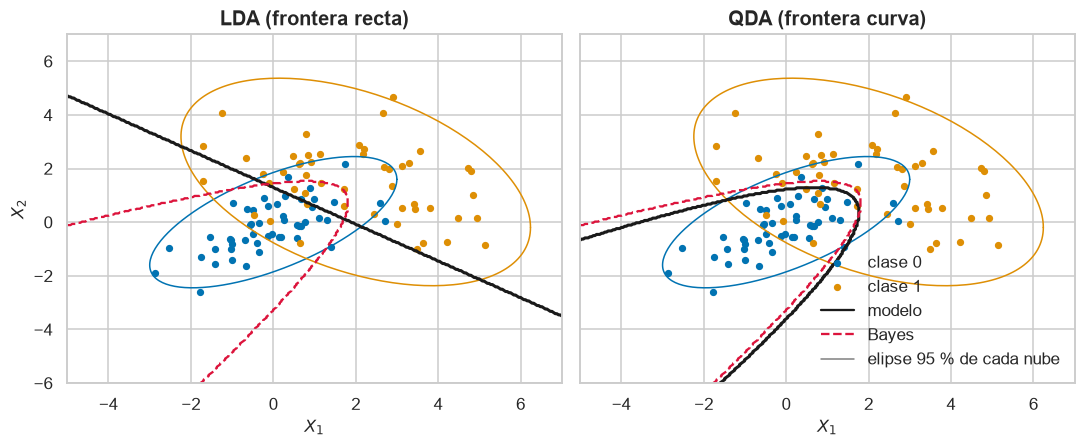

In [8]:
# Misma media, pero la clase 1 más dispersa e inclinada distinto -> las Sigma_k difieren
S1_e = np.array([[3.0, -1.2], [-1.2, 2.5]]); Ss_e = [S_e, S1_e]
X_q, g_q = sim_e(50, Ss_e, 2); Xt_q, gt_q = sim_e(5000, Ss_e, 3)
def delta_q(X, mu, Ss):                                   # QDA con pi = 1/2 (clases balanceadas)
    return np.array([-0.5 * np.linalg.slogdet(Ss[k])[1] - 0.5 * np.einsum("ij,jk,ik->i", X - mu[k], np.linalg.inv(Ss[k]), X - mu[k])
                     for k in range(2)]).T
lda_q = LinearDiscriminantAnalysis().fit(X_q, g_q); qda_q = QuadraticDiscriminantAnalysis().fit(X_q, g_q)
err_q = pd.Series({"LDA": 1 - lda_q.score(Xt_q, gt_q), "QDA": 1 - qda_q.score(Xt_q, gt_q),
                   "Bayes": (delta_q(Xt_q, mu_e, Ss_e).argmax(1) != gt_q).mean()}, name="error de test")
print(err_q.round(4))

xx, yy = np.meshgrid(np.linspace(-5, 7, 300), np.linspace(-6, 7, 300)); gr = np.c_[xx.ravel(), yy.ravel()]
bayes = delta_q(gr, mu_e, Ss_e).argmax(1).reshape(xx.shape)
fig, axs = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True); col = sns.color_palette("colorblind", 2)
th = np.linspace(0, 2 * np.pi, 200); circ = np.vstack([np.cos(th), np.sin(th)])
elipse = lambda k: mu_e[k][:, None] + np.sqrt(5.99) * np.linalg.cholesky(Ss_e[k]) @ circ   # contorno del 95 % de la nube k
for ax, m, tit in zip(axs, [lda_q, qda_q], ["LDA (frontera recta)", "QDA (frontera curva)"]):
    for k in range(2):
        ax.scatter(*X_q[g_q == k].T, s=14, color=col[k], label=f"clase {k}")
        ax.plot(*elipse(k), color=col[k], lw=1)
    ax.contour(xx, yy, m.predict(gr).reshape(xx.shape), levels=[0.5], colors="k", linewidths=2)
    ax.contour(xx, yy, bayes, levels=[0.5], colors="crimson", linestyles="--", linewidths=1.5)
    ax.set_title(tit); ax.set_xlabel("$X_1$")
axs[0].set_ylabel("$X_2$"); axs[1].plot([], [], "k", label="modelo"); axs[1].plot([], [], "--", c="crimson", label="Bayes")
axs[1].plot([], [], color="gray", lw=1, label="elipse 95 % de cada nube"); axs[1].legend()
plt.tight_layout(); plt.show()

QDA casi empata con Bayes (0,1305 contra 0,1248); LDA es la peor (0,1824) porque una recta no puede captar que la clase 1 es más dispersa. En la figura, la recta de LDA corta mal la región de la clase 1 y la curva de QDA acompaña a la punteada de Bayes. Las elipses finas (el 95 % de cada nube, con su $\Sigma_k$ verdadera) muestran el porqué: la de la clase 1 es más grande y está inclinada al revés, y una sola $\Sigma$ no puede representar a las dos.

Otra forma de obtener fronteras cuadráticas es correr **LDA** sobre las variables ampliadas $X_1,X_2,X_1X_2,X_1^2,X_2^2$: es lineal en las 5 variables y cuadrática en las originales. No es idéntica a QDA, porque impone una covarianza común en esas 5 dimensiones; ESL (Fig. 4.6) muestra que la diferencia entre ambas suele ser pequeña. No la corremos acá.

> 🔗 **Conexión con la clase 1**: en la clase 1 (§5, "Confusión típica") quedó anotado que con dos gaussianas de distinta varianza la región de una clase podía ser "el centro" y la de la otra "las dos colas". Eso es QDA en una dimensión: como los términos cuadráticos no se cancelan, la frontera deja de ser un umbral y pasa a ser una ecuación cuadrática. En $p=2$ esos umbrales son las curvas de este gráfico.

#### Costo en parámetros

**Pregunta guía:** ¿cuánto "cuesta" la flexibilidad de QDA?

Las fronteras dependen solo de las diferencias $\delta_k-\delta_K$ respecto de una clase de referencia (la última), así que contamos parámetros **por frontera**:

- **LDA:** cada frontera es una función lineal de $x$: $p$ coeficientes y una constante, o sea $p+1$. En total $(K-1)(p+1)$.
- **QDA:** la parte cuadrática es una matriz simétrica $p\times p$ (solo cuentan la diagonal y lo que está arriba: $p(p+1)/2$ números), más la lineal ($p$) y la constante ($1$): $p(p+3)/2+1$. En total $(K-1)\{p(p+3)/2+1\}$.

**Línea clave: QDA crece cuadráticamente en $p$ y LDA linealmente.** Una aclaración sobre la nota de ESL: **cada frontera** de LDA queda definida por solo $p+1$ números, aunque para obtenerlos haya que estimar toda $\hat\Sigma$ ($p(p+1)/2$ parámetros). Son cosas distintas: parámetros a estimar versus parámetros que definen cada frontera. Si en cambio contás **todo lo que hay que estimar**, LDA necesita $Kp+p(p+1)/2+(K-1)$ (medias, una $\hat\Sigma$ común y priors) y QDA $Kp+K\,p(p+1)/2+(K-1)$ (una $\hat\Sigma_k$ por clase); con $p=10$ y $K=3$ son $87$ y $197$.

Con $K=11$ y $p=10$ (los datos de vocales, ESL Tabla 4.1) son $110$ contra $660$. Con $p=100$ y $K=11$, QDA necesita más de $51000$ contra $1010$ de LDA: sin muchísimos datos, QDA sobreajusta. De ahí la regularización de la sección siguiente (RDA).

> 🔗 **Conexión con la clase 4**: que $\hat\Sigma_k$ sea singular cuando $N_k\le p$ es el mismo problema de la clase 4 cuando $N<p$ y $\mathbf{X}^T\mathbf{X}$ pierde rango: la matriz no se puede invertir y $\delta_k$ no está definida. Los 51000 parámetros de QDA son la versión en clasificación de "más predictores que observaciones". La salida también va a ser la de la clase 4: sumarle algo a la diagonal (lo vas a ver en RDA).

#### ¿Por qué funcionan, y qué no confundir?

**Pregunta guía:** si los datos casi nunca son realmente gaussianos, ¿por qué LDA y QDA andan tan bien?

Según ESL, en el proyecto STATLOG (Michie et al., 1994) LDA estuvo entre los tres mejores clasificadores en 7 de 22 conjuntos de datos, QDA en 4, y al menos uno de los dos en 10. La explicación que da ESL no es que los datos sean gaussianos ni que las covarianzas sean iguales, sino un **compromiso sesgo-varianza**: los datos solo soportan fronteras simples, y el modelo gaussiano las estima con **baja varianza**. Aceptás el sesgo de forzar una frontera lineal a cambio de estimarla de forma mucho más estable. Es una hipótesis, no una demostración, y es menos creíble para QDA, que tiene muchos parámetros. De ahí el puente a la sección siguiente: si LDA tiene sesgo y QDA tiene varianza, ¿existe algo intermedio? Sí: RDA, que encoge las covarianzas de QDA hacia la común.

#### ⚠️ Confusión típica

- **"LDA asume datos gaussianos, así que no sirve si no lo son."** No es tan así: con dos clases la dirección discriminante coincide con la de mínimos cuadrados (lo vemos abajo), y esa cuenta no usa la gaussianidad. Solo el punto de corte depende de ella.
- **Confundir $\hat\Sigma$ pooled con la covarianza total de los datos.** La pooled centra cada punto en la media **de su clase**; la total mezcla la variación *dentro* de las clases con la variación *entre* clases.
- **Creer que la frontera es la mediatriz entre centroides.** Solo lo es con $\Sigma=\sigma^2I$ y priors iguales.
- **Creer que QDA siempre es mejor por ser más flexible.** Con pocos datos o $p$ grande, su varianza arruina el sesgo que ahorra.

#### Extra: LDA de dos clases y mínimos cuadrados

Con dos clases, LDA asigna a la clase 2 si (ESL (4.11))

$$x^T\hat\Sigma^{-1}(\hat\mu_2-\hat\mu_1)>\tfrac12(\hat\mu_2+\hat\mu_1)^T\hat\Sigma^{-1}(\hat\mu_2-\hat\mu_1)-\log(N_2/N_1)$$

que es $\hat\delta_2(x)>\hat\delta_1(x)$ escrito con los estimadores. Chequeo contra la clase 1: con $p=1$, $\Sigma=1$, priors iguales y medias $0$ y $2$, la condición da $x>1$, justo el umbral donde se cruzaban las dos campanas. Si codificás las clases como $+1$ y $-1$ y hacés regresión por mínimos cuadrados, el vector de coeficientes resulta **proporcional** a la dirección $\hat\Sigma^{-1}(\hat\mu_2-\hat\mu_1)$ (ESL lo deja como Ejercicio 4.2; acá lo verificamos numéricamente, no lo demostramos). Pero:

- Si $N_1\neq N_2$ los **interceptos difieren**: la dirección coincide, el corte no. El término $-\log(N_2/N_1)$ mueve la frontera a favor de la clase más frecuente (el test médico de la clase 1 hecho cuenta: ignorar el prior ignora cuánta gente hay de cada clase).
- La dirección no usa gaussianidad; el corte sí. Por eso ESL sugiere elegirlo minimizando el error de entrenamiento.
- Con más de dos clases, LDA **no** coincide con regresión sobre indicadores y evita el *masking* de §4.2. La conexión general es *optimal scoring* (ESL cap. 12).

Verificación con las mismas dos clases, ahora desbalanceadas (40 contra 160):

In [9]:
from sklearn.linear_model import LinearRegression

# Mismas dos clases (misma Sigma) pero desbalanceadas, 40 vs 160: dirección de LDA vs mínimos cuadrados con objetivo +1/-1
r_d = np.random.default_rng(5)
Xd = np.vstack([r_d.multivariate_normal(mu_e[0], S_e, 40), r_d.multivariate_normal(mu_e[1], S_e, 160)])
gd = np.r_[np.zeros(40), np.ones(160)].astype(int)
mu_d = np.array([Xd[gd == k].mean(0) for k in range(2)])
S_d = sum((Xd[gd == k] - mu_d[k]).T @ (Xd[gd == k] - mu_d[k]) for k in range(2)) / (len(gd) - 2)
w_d = np.linalg.solve(S_d, mu_d[1] - mu_d[0])             # dirección LDA: S^-1 (mu_1 - mu_0)
ls_d = LinearRegression().fit(Xd, np.where(gd == 1, 1.0, -1.0))
print("cociente coef_LS / w_LDA (constante => misma dirección):", ls_d.coef_ / w_d)

corte_lda = 0.5 * (mu_d[1] + mu_d[0]) @ w_d - np.log(160 / 40)               # corte de LDA (ESL 4.11)
corte_ls = -ls_d.intercept_ / np.linalg.norm(ls_d.coef_) * np.linalg.norm(w_d)  # corte de mínimos cuadrados, misma escala de w
print(f"corte LDA: {corte_lda:.3f} | corte LS: {corte_ls:.3f}")

cociente coef_LS / w_LDA (constante => misma dirección): [0.20485197 0.20485197]
corte LDA: 0.324 | corte LS: -0.146


El cociente es constante: la **dirección** es la misma. Los cortes difieren (0,324 contra $-0{,}146$) porque $N_1\neq N_2$.

Con esto cerramos LDA y QDA. Queda la pregunta con la que terminó "¿Por qué funcionan...?": si LDA tiene sesgo y QDA tiene varianza, ¿hay algo entre una covarianza por clase y una común? Sí: RDA, la primera subsección que sigue.

## 4.3.1–4.3.3 RDA, cómputo de LDA y LDA de rango reducido

📕 ESL §4.3.1–4.3.3

Hasta acá, QDA estima una covarianza $\hat\Sigma_k$ por clase y LDA una sola, común, $\hat\Sigma$. Esta sección sigue un hilo de cuatro pasos:

1. **RDA** es un dial que va de QDA a LDA: cuánta covarianza *propia* le dejás a cada clase.
2. **Esferizar** (deformar el espacio hasta que las nubes queden redondas) convierte a LDA en "ir al centroide más cercano".
3. Los $K$ centroides viven en un subespacio de dimensión a lo sumo $K-1$. Ahí se puede **mirar, reducir y regularizar**.
4. **Fisher** llega al mismo subespacio sin suponer gaussianas.

Al final, dos simulaciones muestran dos de los tres "diales" de complejidad que aparecen en el camino ($L$ y $\alpha$); el tercero, $\gamma$, queda en texto (los vamos a definir en su momento).

### 4.3.1 Regularized Discriminant Analysis

**Pregunta guía: ¿estimo una covarianza por clase o una sola? ¿Hay un punto medio?** Sí: RDA mezcla las dos con un dial, y el mejor ajuste suele estar en el medio.

LDA y QDA responden distinto a la misma pregunta:

- **QDA**: una $\hat\Sigma_k$ por clase. Es flexible, pero cada una tiene unos $p(p+1)/2$ números y se estima con los $N_k$ puntos de *una sola* clase. Con pocos datos queda ruidosa (o singular, si $N_k \le p$).
- **LDA**: una sola $\hat\Sigma$ con todos los puntos juntos (la covarianza **agrupada**, *pooled*: la de §4.3, con cada punto centrado en la media de su clase). Es estable, pero obliga a todas las clases a tener la misma forma.

Friedman (1989) propuso no elegir y **mezclar**: cada covarianza de clase se tira un poco hacia la común. Es el espíritu de ridge: aceptar algo de sesgo a cambio de bajar varianza.

Una analogía: tenés el promedio de notas de cada comisión (QDA) y el de toda la materia (LDA). Si una comisión tiene 4 alumnos, su promedio propio es poco confiable y conviene corregirlo con el general; si tiene 400, casi no hace falta.

> **Dónde se rompe la analogía.** Acá se mezclan **matrices** de $p\times p$, no números, y la mezcla tiene que seguir siendo invertible. Eso se cumple porque una combinación convexa (pesos $\ge 0$ que suman 1) de matrices semidefinidas positivas es semidefinida positiva, y porque la común $\hat\Sigma$ suele ser invertible aunque alguna $\hat\Sigma_k$ no lo sea.

**El dial $\alpha$.** ESL (4.13) define

$$\hat\Sigma_k(\alpha) = \alpha\,\hat\Sigma_k + (1-\alpha)\,\hat\Sigma, \qquad \alpha \in [0,1].$$

$\alpha$ (leelo "alfa") es un **hiperparámetro** (algo que elegís vos, no que se ajusta solo) que dice cuánta fe le tenés a la covarianza propia de cada clase. Leé los extremos:

- $\alpha = 1$: $\hat\Sigma_k(1)=\hat\Sigma_k$, **QDA puro**.
- $\alpha = 0$: $\hat\Sigma_k(0)=\hat\Sigma$ para toda $k$, **LDA puro**.
- $0<\alpha<1$: un continuo entre ambos.

Ojo: semidefinida no alcanza para invertir. Si $\hat\Sigma$ es definida positiva (lo habitual cuando $N-K>p$) y $\alpha<1$, la mezcla es definida positiva aunque algún $\hat\Sigma_k$ no lo sea. Con $\alpha=1$ esa garantía se pierde. No hay fórmula para $\alpha$: ESL lo elige con datos de validación o validación cruzada.

**El dial $\gamma$.** Hay un segundo dial, que encoge la propia $\hat\Sigma$ hacia una "esfera" (ESL 4.14):

$$\hat\Sigma(\gamma) = \gamma\,\hat\Sigma + (1-\gamma)\,\hat\sigma^2 I, \qquad \gamma \in [0,1].$$

Acá $\hat\sigma^2$ ("sigma cuadrado") es un **escalar**: una varianza típica. Una elección razonable, y la que usa `sklearn`, es el promedio de la diagonal, $\operatorname{tr}(\hat\Sigma)/p$ (la traza $\operatorname{tr}$ es la suma de la diagonal). La matriz $\hat\sigma^2 I$ describe variables sin correlación y todas con la misma varianza: nubes **redondas** (esferas). Con $\gamma=0$ no queda información de forma y el clasificador se reduce a distancia euclídea a los centroides. Poniendo $\hat\Sigma(\gamma)$ en lugar de $\hat\Sigma$ en (4.13) queda una familia de dos parámetros: $\alpha$ recorre "una covarianza por clase $\leftrightarrow$ una común" y $\gamma$ recorre "común completa $\leftrightarrow$ esférica". (ESL menciona además otras versiones regularizadas de LDA en el cap. 12 y el caso $\gamma=0$ para microarrays en el cap. 18.)

> 🔗 **Conexión con la clase 4**: $\hat\Sigma(\gamma)=\gamma\hat\Sigma+(1-\gamma)\hat\sigma^2 I$ es ridge aplicado a una covarianza: si sacás $\gamma$ de factor común queda $\hat\Sigma+\lambda I$ con $\lambda=\frac{1-\gamma}{\gamma}\hat\sigma^2$, la misma operación de $\mathbf{X}^T\mathbf{X}+\lambda I$. Es un dial entre dos extremos, como $\lambda$: $\alpha=1$ es QDA y $\alpha=0$ es LDA, igual que $\lambda=0$ es OLS. La diferencia es hacia dónde se encoge: ridge tira hacia el cero, RDA tira hacia otra covarianza o hacia una esfera.

**¿Por qué nos importa?** Porque RDA es el primer lugar donde, en clasificación, aparece el dial sesgo–varianza de ridge. $\alpha$ no mide "qué tan no lineal es la frontera": mide cuánto confiás en una covarianza estimada con pocos datos. En la Fig. 4.7 del libro (datos de vocales: 11 clases, 10 variables) el error de test tiene su óptimo cerca de $\alpha=0{,}9$ y **sube bruscamente** después: el QDA puro, que estaba a un paso, es peor que un QDA un poquito encogido. (El libro avisa que la gran brecha entre entrenamiento y test se debe en parte a que hay muchas mediciones repetidas de pocos individuos, distintos en cada conjunto.) Lo reproducimos con datos simulados al final de la sección.

**Puente.** RDA mezcla covarianzas, pero todavía no dijimos cómo se *calcula* un clasificador discriminante sin invertir matrices a mano. La respuesta es una transformación del espacio que hace que todo se reduzca a medir distancias.

### 4.3.2 Cómputo de LDA: esferizar

**Pregunta guía: ¿cómo se pasa de la fórmula de $\delta_k(x)$, con su $\hat\Sigma^{-1}$, a "ir al centroide más cercano"?** Esferizando: deformás el espacio hasta que la covarianza común sea la identidad. Ahí, LDA **es** "centroide más cercano" (corregido por $\pi_k$).

La imagen: se estira y rota el espacio de modo que la nube de cada clase quede **redonda**. En un espacio donde todas las clases son esferas del mismo radio, clasificar es lo más intuitivo que hay: ir al centroide más cercano, con una pequeña ventaja para las clases más frecuentes. Esto es lo que, en §4.3, llamamos distancia de Mahalanobis: es la distancia euclídea *después* de esferizar.

> **Dónde se rompe.** "Nube redonda" vale para la covarianza **común** $\hat\Sigma$. En QDA cada clase tiene su forma, y no hay una transformación única que redondee a todas a la vez.

**Paso 0, de dónde salen $U$ y $D$.** Para no arrastrar notación: de ahora en más llamamos $W$ a la misma $\hat\Sigma$ agrupada (el nombre es de ESL: *within*, intra-clase). Como $W$ es simétrica y definida positiva (lo habitual cuando $N-K>p$), se puede **diagonalizar** (eigen-descomposición):

$$W = U D U^T.$$

- $U$ ($p\times p$) es **ortonormal** ($U^TU=I$, o sea $U^{-1}=U^T$). Sus columnas son los **ejes principales** de la nube: las direcciones en las que se estira.
- $D$ es **diagonal** y tiene los **autovalores** $d_1,\dots,d_p>0$: la varianza de la nube a lo largo de cada eje.

Consecuencia útil: $W^{-1}=UD^{-1}U^T$. Invertir pasó a ser invertir números sueltos.

**Paso 1, esferizar.** Definimos los datos esferizados

$$X^*=D^{-1/2}U^TX.$$

$D^{-1/2}$ es la diagonal con $1/\sqrt{d_\ell}$. Se lee en dos tiempos: $U^T$ **rota** a los ejes principales, y $D^{-1/2}$ divide cada coordenada por su desvío. Chequeo de que la covarianza de $X^*$ es la identidad (la covarianza de $AX$ es $AWA^T$):

$$D^{-1/2}U^T\,(UDU^T)\,UD^{-1/2}=D^{-1/2}\,D\,D^{-1/2}=I.$$

**Paso 2, centroide más cercano.** Con los centroides transformados, $\mu_k^*=D^{-1/2}U^T\hat\mu_k$, el término cuadrático de $\delta_k$ es exactamente $\|x^*-\mu_k^*\|^2$, la distancia euclídea al cuadrado. El término $-\tfrac12\log|W|$ es igual para todas las clases, así que no decide y se descarta. Queda

$$\hat G(x)=\arg\min_k\Big[\tfrac12\|x^*-\mu_k^*\|^2-\log\pi_k\Big].$$

**Esto es "al centroide más cercano, módulo las probabilidades a priori $\pi_k$"** (ESL): a igual distancia, gana la clase más probable.

**Y QDA, en dos líneas.** Cada $\hat\Sigma_k=U_kD_kU_k^T$ tiene su propia diagonalización. El término cuadrático se calcula coordenada a coordenada sobre los ejes de la clase, y el log-determinante es $\log|\hat\Sigma_k|=\sum_\ell\log d_{k\ell}$ (el determinante es el producto de los autovalores). No hay inversa que calcular, pero tampoco una sola transformación común.

**El ejemplo corriente, esferizado.** Antes de wine, retomamos las dos nubes de §4.3 con su $\hat\Sigma$ pooled (`S_h`): la diagonalizamos, esferizamos y miramos qué le pasa a la elipse. Después clasificamos con distancia euclídea más $\log\hat\pi_k$ y comparamos con la regla de §4.3.

autovalores de S_h: [0.36 2.01] | cov. intra-clase esferizada = I: True
euclidea esferizada + log pi == regla de 4.3: True


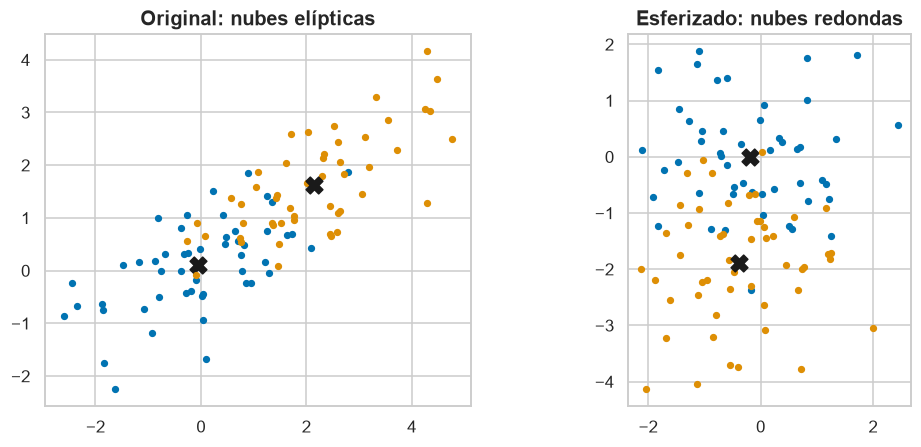

In [10]:
# Ejemplo corriente (4.3): esferizamos con su Sigma pooled S_h = U D U^T
d_e, U_e = np.linalg.eigh(S_h)
Esf_e = U_e / np.sqrt(d_e)                           # U D^{-1/2} (version por filas)
Xs_e, mus_e = X_e @ Esf_e, mu_h @ Esf_e              # puntos y centroides esferizados
print("autovalores de S_h:", d_e.round(2), "| cov. intra-clase esferizada = I:", np.allclose(Esf_e.T @ S_h @ Esf_e, np.eye(2)))
pred_s_e = (0.5 * (((Xt_e @ Esf_e)[:, None, :] - mus_e) ** 2).sum(2) - np.log(pi_e)).argmin(1)
print("euclidea esferizada + log pi == regla de 4.3:", np.array_equal(pred_s_e, pred_e))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, Z, M, t in zip(axes, [X_e, Xs_e], [mu_h, mus_e], ["Original: nubes elípticas", "Esferizado: nubes redondas"]):
    for k in range(2):
        ax.scatter(*Z[g_e == k].T, s=14, color=sns.color_palette("colorblind")[k])
        ax.scatter(*M[k], marker="X", s=120, color="k")
    ax.set_title(t); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

A la izquierda las nubes son elipses inclinadas, con dos ejes principales de varianzas muy distintas (los autovalores impresos). A la derecha, tras $UD^{-1/2}$, son redondas, y la distancia euclídea entre un punto y un centroide es la de Mahalanobis de §4.3. Las 10000 predicciones de test son las mismas que con la regla de §4.3: esferizar no cambia el clasificador, solo lo vuelve geométrico.

Ahora con más dimensiones: wine (vinos de 3 cultivares, con 13 mediciones químicas cada uno; $K=3$ clases, $p=13$ variables). La celda de abajo hace los dos pasos a mano: esferiza, chequea que la covarianza intra-clase queda en la identidad, y clasifica con distancia euclídea más $\log\pi_k$.

In [11]:
from sklearn.datasets import load_wine
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Wine: K=3 clases, p=13 variables. No se estandariza: LDA sin encoger no depende de la escala.
X_rda, y_rda = load_wine(return_X_y=True)
N_rda, p_rda = X_rda.shape
K_rda = len(np.unique(y_rda))
clases_rda = np.unique(y_rda)

pi_rda = np.array([np.mean(y_rda == k) for k in clases_rda])
mu_rda = np.array([X_rda[y_rda == k].mean(axis=0) for k in clases_rda])

# Covarianza agrupada W: los residuos respecto de la media de SU clase, sobre N-K
Xc_rda = X_rda - mu_rda[y_rda]
W_rda = Xc_rda.T @ Xc_rda / (N_rda - K_rda)

# Paso 1: eigen-descomposicion W = U D U^T y esferizado (version por filas)
d_rda, U_rda = np.linalg.eigh(W_rda)          # eigh: W es simetrica
Esf_rda = U_rda / np.sqrt(d_rda)              # U D^{-1/2}
Xs_rda = X_rda @ Esf_rda
mus_rda = mu_rda @ Esf_rda
print("covarianza intra-clase esferizada = I:", np.allclose(Esf_rda.T @ W_rda @ Esf_rda, np.eye(p_rda)))

# Paso 2: centroide mas cercano corregido por log(pi_k)
dist2_rda = ((Xs_rda[:, None, :] - mus_rda[None, :, :]) ** 2).sum(axis=2)
pred_rda = np.argmin(0.5 * dist2_rda - np.log(pi_rda), axis=1)
print("accuracy a mano:", (pred_rda == y_rda).mean())

covarianza intra-clase esferizada = I: True
accuracy a mano: 1.0


La primera línea impresa verifica lo que demostramos: $(UD^{-1/2})^T\,W\,(UD^{-1/2})=I$. La segunda es la clasificación a mano: una distancia euclídea más la corrección por $\pi_k$, sin invertir nada. (`sklearn` hace lo mismo por dentro en `LinearDiscriminantAnalysis`, con `solver="eigen"` o `"svd"`; no hace falta repetirlo.)

**Invarianza.** Si cambiás las variables con $x\to Ax$ ($A$ inversible), $\hat\mu_k\to A\hat\mu_k$ y $W\to AWA^T$, y los puntajes $\delta_k$ no cambian (las $A$ se cancelan): por eso LDA sin encoger no depende de la escala ni de rotaciones de las variables.

**¿Por qué nos importa?** Dos razones. **Interpretativa**: LDA deja de ser "una fórmula con una inversa" y pasa a ser "distancia euclídea tras una transformación"; todo lo que sigue sale de mirar el espacio esferizado. **Regularizadora**: los autovalores chicos de $W$ son los que $D^{-1/2}$ amplifica muchísimo, y son los que meten más ruido cuando $N$ es chico (con $N<p$ directamente hay autovalores nulos y $W$ no se puede invertir). Encoger con $\gamma$ es acercar cada autovalor hacia $\hat\sigma^2$: la mezcla $\hat\Sigma(\gamma)$ tiene los mismos ejes $U$ y autovalores $\gamma d_\ell+(1-\gamma)\hat\sigma^2$, así que los chicos se levantan. Es el gesto de ridge ($\lambda I$) puesto sobre la covarianza.

#### ⚠️ Confusión típica

Creer que **esferizar es lo mismo que estandarizar** (restar la media y dividir por el desvío). Estandarizar escala cada variable por separado y **deja las correlaciones**. Esferizar además las elimina, porque primero rota a los ejes principales de $W$ y recién después escala. Por eso LDA no es "distancia a los centroides con las variables estandarizadas", sino distancia euclídea *después de esferizar*.

**Puente.** Ya tenemos a LDA como "distancia euclídea a $K$ puntos". Y $K$ puntos, por pocos que sean, tienen una geometría muy particular.

### 4.3.3 LDA de rango reducido

**Pregunta guía: ¿cuántas dimensiones hacen falta, de verdad, para clasificar con $K$ clases?** A lo sumo $K-1$. Y más abajo vemos que a veces conviene usar menos todavía.

**La idea.** Los $K$ centroides están en $\mathbb{R}^p$, pero $K$ puntos siempre caben en un subespacio afín de dimensión a lo sumo $K-1$ (dos puntos definen una recta, tres un plano...). Con $p=13$ y $K=3$, los centroides están en un plano. Y para decidir a qué centroide estás más cerca, lo que pasa **fuera** de ese plano no ayuda: suma lo mismo a la distancia a todas las clases. Entonces se proyecta y se clasifica en el plano sin perder nada relevante.

Una analogía: tenés que decidir cuál de tres personas te queda más cerca. La altura a la que estás respecto del piso suma lo mismo a las tres distancias al cuadrado. Lo único que decide es tu posición sobre el piso donde están ellas.

> **Dónde se rompe.** La analogía vale en el espacio **esferizado** (donde distancia es la euclídea y "perpendicular" tiene sentido), no en el original. Y si $K-1\ge p$, como en las vocales ($K-1=p=10$), no hay "altura" que tirar: los centroides ocupan todo el espacio.

**Por qué podemos ignorar lo ortogonal.** Trabajamos en el espacio esferizado. Sea $\bar\mu^*$ el centroide global (el promedio de los $\mu_k^*$, ponderado por $\pi_k$). Sea $H_{K-1}$ el subespacio afín que contiene a los $\mu_1^*,\dots,\mu_K^*$ (no confundir con la matriz sombrero $\mathbf H$ de §4.2: acá $H_{K-1}$ es un subespacio, no una matriz) y $P$ la **proyección ortogonal** sobre la dirección de ese subespacio, centrada en $\bar\mu^*$ ($P$ se queda con la parte "sobre el piso"; $I-P$ con la "altura"). Cualquier vector se parte en una parte dentro y una fuera, ortogonales entre sí, así que por Pitágoras

$$\|x^*-\mu_k^*\|^2=\|P(x^*-\mu_k^*)\|^2+\|(I-P)(x^*-\mu_k^*)\|^2.$$

Como $\mu_k^*-\bar\mu^*$ está dentro del subespacio, $(I-P)(\mu_k^*-\bar\mu^*)=0$. Escribiendo $x^*-\mu_k^*=(x^*-\bar\mu^*)-(\mu_k^*-\bar\mu^*)$:

$$(I-P)(x^*-\mu_k^*)=(I-P)(x^*-\bar\mu^*),$$

que **no depende de $k$**. **El segundo sumando de Pitágoras es el mismo número para todas las clases, así que no cambia cuál es el mínimo.** Alcanza con mirar el subespacio de dimensión $\le K-1$. Con $K=3$ es un plano: se grafica con un color por clase sin resignar nada de lo que LDA usa para clasificar.

**¿Y si $K-1$ sigue siendo grande?** Podemos pedir un subespacio de dimensión $L<K-1$, "óptimo para LDA". Fisher definió **óptimo** como: que los centroides proyectados queden lo más **esparcidos** posible. Según ESL eso equivale a hacer componentes principales de los centroides ya esferizados (componentes principales: ESL §3.5.1 en breve, §14.5.1 en detalle). Las direcciones salen ordenadas, de más a menos separación, y se llaman **variables canónicas** (o discriminantes). Para armarlas necesitamos cuatro objetos; los presentamos en el orden en que se usan:

- $W$: la covarianza intra-clase de siempre ($p\times p$). No es la matriz diagonal de pesos $\mathbf W$ de IRLS en §4.4.1: comparten letra, no significado.
- $M$: la matriz de $K\times p$ cuyas filas son los centroides $\hat\mu_k$.
- $M^*=MW^{-1/2}$: los centroides **esferizados**. $W^{-1/2}=UD^{-1/2}U^T$ es la versión simétrica de la $D^{-1/2}U^T$ de antes (la misma, seguida de una rotación $U$ que no cambia distancias). Como es simétrica, sirve con una observación por fila, que es lo que usa `numpy`.
- $B^*$: la **covarianza *between*** (entre clases) de $M^*$, o sea qué tanto se dispersan los centroides esferizados alrededor del centroide global (ponderando cada uno por $\pi_k$). En el espacio original, la matriz *between* es $B=\sum_k\pi_k(\hat\mu_k-\bar\mu)(\hat\mu_k-\bar\mu)^T$ y vale $B^*=W^{-1/2}BW^{-1/2}$. Sirve para medir **cuánta separación entre clases hay en cada dirección**.

**El algoritmo** (ESL §4.3.3):

1. Calcular $M$ y $W$.
2. Esferizar los centroides: $M^*=MW^{-1/2}$.
3. Diagonalizar $B^*=V^*D_BV^{*T}$. Las columnas $v_\ell^*$ de $V^*$, ordenadas por autovalor, dan las coordenadas de los subespacios óptimos; **cada autovalor de $D_B$ dice cuánta separación entre clases hay en esa dirección**.
4. Volver a las variables originales para poder aplicar la regla a datos crudos: la $\ell$-ésima variable discriminante es

$$Z_\ell=v_\ell^TX,\qquad v_\ell=W^{-1/2}v_\ell^*.$$

$B^*$ viene de $K$ puntos centrados, así que su rango es a lo sumo $K-1$: sólo hay hasta $K-1$ discriminantes con autovalor distinto de cero. (ESL dice sólo "la covarianza de $M$"; en el código ponderamos por $\pi_k$, y con clases balanceadas da lo mismo salvo una constante.)

Probamos el algoritmo en wine (con $K-1=2$ discriminantes), y lo comparamos con `sklearn`.

In [12]:
# Discriminantes canonicos a mano: algoritmo de ESL 4.3.3 (W, pi_k, mu_rda ya calculados arriba)
# Paso 2: W^{-1/2} simetrica = U D^{-1/2} U^T
Wmh_rda = U_rda @ np.diag(d_rda ** -0.5) @ U_rda.T
Ms_rda = mu_rda @ Wmh_rda                        # M* = M W^{-1/2}  (K x p)

# Paso 3: B* = covarianza (ponderada por pi_k) de M*, y su eigen-descomposicion
mbar_rda = pi_rda @ Ms_rda
Bs_rda = (Ms_rda - mbar_rda).T @ np.diag(pi_rda) @ (Ms_rda - mbar_rda)
lam_rda, Vs_rda = np.linalg.eigh(Bs_rda)
orden_rda = np.argsort(lam_rda)[::-1]
lam_rda, Vs_rda = lam_rda[orden_rda], Vs_rda[:, orden_rda]

# Paso 4: v_l = W^{-1/2} v*_l ; solo K-1 autovalores son distintos de cero (rango de B*)
V_rda = Wmh_rda @ Vs_rda[:, :K_rda - 1]
Z_rda = (X_rda - mu_rda.T @ pi_rda) @ V_rda      # discriminantes (centrados)
print("autovalores de B*:", np.round(lam_rda[:4], 4), "(el resto ~ 0)")

# Chequeo: es el mismo problema que W^{-1} B a = lambda a
B_rda = (mu_rda - mu_rda.T @ pi_rda).T @ np.diag(pi_rda) @ (mu_rda - mu_rda.T @ pi_rda)   # B en el espacio original
lam2_rda = np.sort(np.linalg.eigvals(np.linalg.inv(W_rda) @ B_rda).real)[::-1]
print("autovalores de W^-1 B:", np.round(lam2_rda[:4], 4))
print("v^T W v = I:", np.allclose(V_rda.T @ W_rda @ V_rda, np.eye(K_rda - 1)))

autovalores de B*: [8.9287 4.0589 0.     0.    ] (el resto ~ 0)
autovalores de W^-1 B: [8.9287 4.0589 0.     0.    ]
v^T W v = I: True


discriminante 1: |corr| mano vs sklearn = 1.000000
discriminante 2: |corr| mano vs sklearn = 1.000000


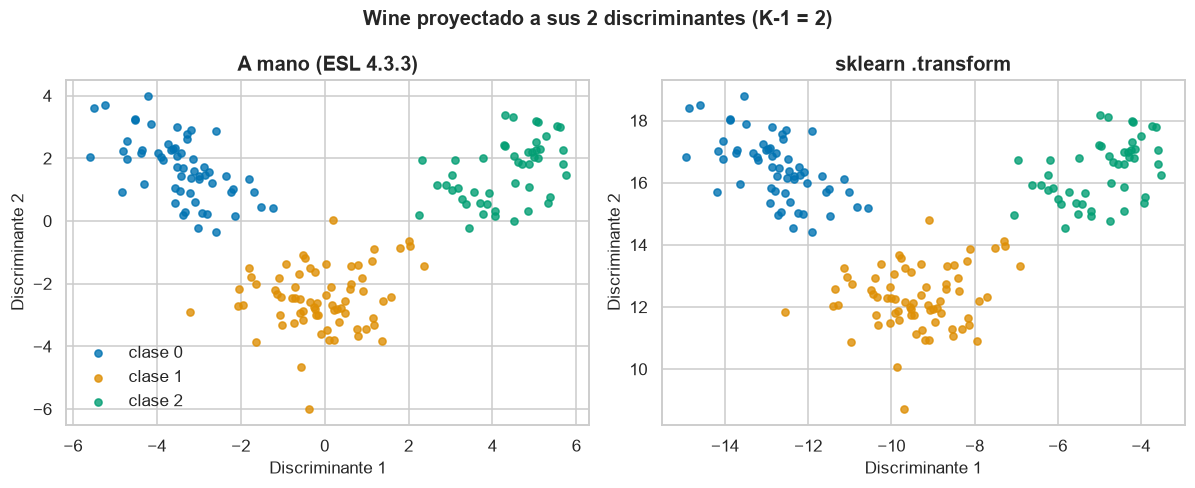

In [13]:
# Asi se hace en la industria: LDA(...).transform da los discriminantes
lda_tr_rda = LinearDiscriminantAnalysis(solver="eigen", n_components=2).fit(X_rda, y_rda)
Zsk_rda = lda_tr_rda.transform(X_rda)

# Coinciden salvo signo y escala por columna: comparamos con la correlacion absoluta
for l in range(2):
    c = abs(np.corrcoef(Z_rda[:, l], Zsk_rda[:, l])[0, 1])
    print(f"discriminante {l + 1}: |corr| mano vs sklearn = {c:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, Zp, titulo in zip(axes, [Z_rda, Zsk_rda], ["A mano (ESL 4.3.3)", "sklearn .transform"]):
    for k in clases_rda:
        ax.scatter(Zp[y_rda == k, 0], Zp[y_rda == k, 1], s=22, alpha=0.8, label=f"clase {k}")
    ax.set_title(titulo)
    ax.set_xlabel("Discriminante 1")
    ax.set_ylabel("Discriminante 2")
axes[0].legend()
fig.suptitle("Wine proyectado a sus 2 discriminantes (K-1 = 2)", fontweight="bold")
plt.tight_layout()
plt.show()

#### 🏭 Así se hace en la industria

La celda de arriba usa `LinearDiscriminantAnalysis(...).transform`. Los dos paneles tienen que ser la misma nube salvo un espejo o un cambio de escala de los ejes: cada discriminante está definido salvo signo, y `sklearn` normaliza los ejes distinto. Por eso comparamos con correlación absoluta y no con `allclose`.

**Qué mirar:** tres grupos bien separados en un plano que salió de un espacio de 13 variables. En wine $K-1=2$, así que **no perdimos nada** de lo que LDA necesita (la demostración de arriba). En las vocales, en cambio, $K-1=p$ y quedarse con 2 dimensiones sí es una reducción con pérdida, que encima resulta ser la mejor para generalizar (más abajo).

**Puente.** Todo esto salió suponiendo gaussianas con covarianza común. Fisher llegó al mismo subespacio de otra manera, sin mencionar distribuciones.

**La derivación de Fisher, sin gaussianas.** *Pregunta: ¿qué dirección $a$ conviene para proyectar?* Fisher pidió la combinación lineal $Z=a^TX$ (un número por punto: su proyección sobre la dirección $a$) con **la varianza entre clases maximizada respecto de la varianza intra-clase**. Para esa $Z$:

- la varianza **entre** clases (la de las medias de clase proyectadas) es $a^TBa$;
- la varianza **intra** clase (alrededor de esas medias) es $a^TWa$.

El problema (ESL 4.15) es maximizar el **cociente de Rayleigh** (un cociente de dos formas cuadráticas):

$$\max_a\frac{a^TBa}{a^TWa},$$

o, equivalentemente (ESL 4.16), $\max_a a^TBa$ sujeto a $a^TWa=1$ (el cociente no cambia si reescalás $a$, así que se puede fijar el denominador). Si $B$ y $W$ se normalizan con otro divisor, los autovalores se reescalan pero las direcciones no cambian.

**Es el mismo procedimiento del algoritmo.** Cambiamos de variable: $b=W^{1/2}a$, o sea $a=W^{-1/2}b$. Entonces $a^TWa=b^Tb$ y $a^TBa=b^TB^*b$, y el problema queda

$$\max_b\frac{b^TB^*b}{b^Tb}.$$

**Para una matriz simétrica, ese cociente se maximiza en el autovector de mayor autovalor $v_1^*$, y el máximo vale ese autovalor.** Volviendo a $a$: $a_1=W^{-1/2}v_1^*$, que es exactamente el $v_1$ del algoritmo. Las direcciones siguientes son ortogonales en $b$, que en $a$ significa ortogonales **respecto de $W$** ($a_i^TWa_j=0$).

Un detalle para quien vea la formulación de ESL: "$a$ es el autovector de mayor autovalor de $W^{-1}B$". Es lo mismo. Si $B^*v^*=\lambda v^*$ ($\lambda$, "lambda", es el autovalor de $v^*$) y $a=W^{-1/2}v^*$:

$$W^{-1}B\,a=W^{-1/2}\big(W^{-1/2}BW^{-1/2}\big)v^*=W^{-1/2}B^*v^*=\lambda\,a.$$

$W^{-1}B$ **no es simétrica**, pero tiene los mismos autovalores que la simétrica $B^*$, y sus autovectores son $a=W^{-1/2}v^*$. Por eso conviene resolverlo por la vía simétrica (ESL deja la identidad $a_1\leftrightarrow v_1$ como Ex. 4.1). Los $a_\ell$ se llaman **coordenadas discriminantes** (no confundir con las *funciones* discriminantes $\delta_k$) o también *variates* canónicos, porque hay una derivación alternativa por correlación canónica (ESL §12.5).

**Por qué Fisher mira la covarianza y no sólo los centroides.** En la Fig. 4.9 del libro, la dirección que une los centroides maximiza la separación de las medias, pero con nubes alargadas las clases proyectadas se **solapan**. Una dirección que tiene en cuenta la covarianza separa menos las medias y solapa mucho menos, que es lo que baja el error. Maximizar sólo $a^TBa$, sin el denominador $a^TWa$, da la dirección equivocada.

**Y el $\log\pi_k$ en el subespacio.** Clasificar en $L$ dimensiones es la misma regla restringida a esas coordenadas, con la corrección $\log\pi_k$ incluida. ESL muestra que equivale a un modelo gaussiano cuyos centroides caen en un subespacio de dimensión $L$, ajustado por máxima verosimilitud (Ex. 4.8). Con $\pi_k$ iguales, el corte óptimo queda en el medio de las medias proyectadas; con $\pi_k$ distintos, conviene correrlo hacia la clase más chica.

**¿Por qué nos importa?** Porque **reducir el rango también regulariza**. En las vocales (11 clases, 10 variables) la Fig. 4.10 del libro muestra el error de LDA en cada subespacio jerárquico, y la mejor tasa de error de test se da en dimensión **2**, no en 10. Con 2 discriminantes se estiman muchos menos parámetros (la frontera vive en un plano): baja la varianza a costa de un poco de sesgo. (Fig. 4.11: fronteras en ese plano; Fig. 4.4: el subespacio óptimo de dimensión 2 de esas 11 clases; Fig. 4.8: pares sucesivos de coordenadas, donde los centroides quedan cada vez menos esparcidos porque los autovalores de $B^*$ bajan.) En un subespacio de dimensión mayor, las fronteras son planos afines y ya no se dibujan como rectas.

En criollo: el número de discriminantes que te quedás, $L$, es otro hiperparámetro de complejidad, igual que $\alpha$ y $\gamma$, y se elige igual (validación o validación cruzada). Y es "truncar" más que "encoger": con $L$ discriminantes cada dirección entra con peso 1 o 0, mientras que ridge baja el volumen de forma continua. El resumen de ESL de todo el camino: (i) la clasificación gaussiana con covarianza común da fronteras lineales y se hace esferizando y yendo al centroide más cercano (módulo $\log\pi_k$); (ii) como sólo importan distancias relativas, todo se confina al subespacio de los centroides; (iii) ese subespacio se descompone en subespacios sucesivamente óptimos, y la descomposición es la de Fisher. (Al cierre de §4.3.3, ESL conecta este LDA con la regresión sobre la matriz indicadora, Ex. 4.3 y §12.5; acá no lo usamos.)

**Puente.** Tenemos tres diales de complejidad: $L$ (cuántas dimensiones), $\alpha$ (cuánta covarianza propia por clase) y $\gamma$ (cuánta forma de covarianza). Veamos $L$ y $\alpha$ funcionar con datos simulados, porque wine es demasiado chico para ver el fenómeno; $\gamma$ queda en texto.

#### En código: los diales $L$ y $\alpha$ con datos simulados

**Dial $L$: rango reducido.** Wine tiene $K-1=2$ y no deja ver el fenómeno de la Fig. 4.10: hace falta $K-1$ grande, con los centroides *realmente* en pocas dimensiones, y pocos datos. Simulamos $K=5$ clases en $p=10$ variables, con los centroides en un plano (2 dimensiones) más ruido con covarianza común, y sólo 15 puntos de entrenamiento por clase. Comparamos el error de test con $L=1,2,3,4$ discriminantes ($L=4=K-1$ es LDA completo).

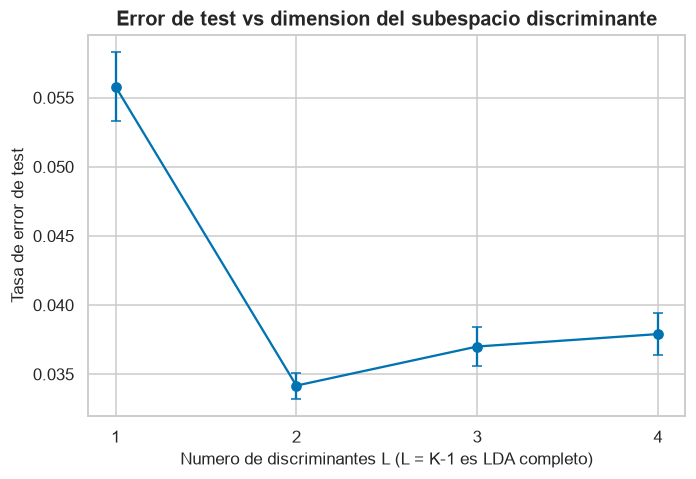

error medio por L: [0.056 0.034 0.037 0.038]


In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

K_s, p_s, n_por_clase, n_test, reps = 5, 10, 15, 1000, 30
rng_rda = np.random.default_rng(0)
Q_rda = np.linalg.qr(rng_rda.normal(size=(p_s, 2)))[0].T       # base ortonormal de un plano
M_true_rda = 2.5 * rng_rda.normal(size=(K_s, 2)) @ Q_rda       # centroides en ese plano
L_cov_rda = np.eye(p_s) + 0.4 * rng_rda.normal(size=(p_s, p_s))  # covarianza comun = L L^T

def muestra_rda(n):
    y = np.repeat(np.arange(K_s), n)
    return M_true_rda[y] + rng_rda.normal(size=(len(y), p_s)) @ L_cov_rda.T, y

err_rda = np.zeros((reps, K_s - 1))
for r in range(reps):
    Xtr, ytr = muestra_rda(n_por_clase)
    Xte, yte = muestra_rda(n_test)
    full = LDA(solver="svd").fit(Xtr, ytr)
    Ztr, Zte = full.transform(Xtr), full.transform(Xte)
    for L in range(1, K_s):
        # Gaussiana en el subespacio de L discriminantes (aprende pi_k y centroides ahi)
        clf = LDA(solver="svd").fit(Ztr[:, :L], ytr)
        err_rda[r, L - 1] = 1 - clf.score(Zte[:, :L], yte)

fig, ax = plt.subplots()
ax.errorbar(range(1, K_s), err_rda.mean(0), yerr=err_rda.std(0) / np.sqrt(reps), marker="o", capsize=3)
ax.set_xticks(range(1, K_s))
ax.set_title("Error de test vs dimension del subespacio discriminante")
ax.set_xlabel("Numero de discriminantes L (L = K-1 es LDA completo)")
ax.set_ylabel("Tasa de error de test")
plt.show()
print("error medio por L:", np.round(err_rda.mean(0), 3))

Mirá el gráfico y el vector impreso (celda de arriba): el error baja hasta $L=2$, la dimensión verdadera del plano de centroides, y de ahí no mejora: los discriminantes 3 y 4 sólo capturan ruido, que con pocos datos se estima mal. Es el mensaje de la Fig. 4.10: menos dimensiones, menos varianza. (La magnitud depende de los datos simulados.)

**Dial $\alpha$: QDA $\leftrightarrow$ LDA.** `sklearn` no trae el RDA de Friedman, así que lo escribimos a mano: para cada clase mezclamos $\hat\Sigma_k(\alpha)=\alpha\hat\Sigma_k+(1-\alpha)\hat\Sigma$ y calculamos $\delta_k$ con la diagonalización de 4.3.2 (término cuadrático y log-determinante). Simulamos 3 clases en $p=10$ con covarianzas **distintas** por clase y pocos datos.

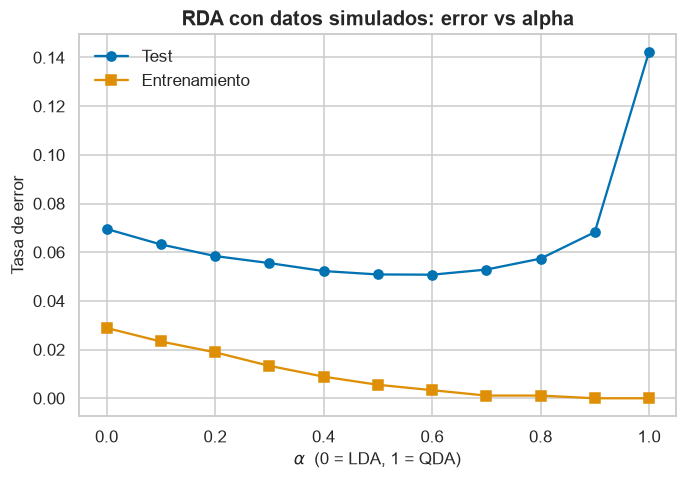

alpha con menor error de test: 0.6000000000000001
error de entrenamiento medio por alpha: [0.029 0.023 0.019 0.013 0.009 0.006 0.003 0.001 0.001 0.    0.   ]
error de test medio por alpha:          [0.07  0.063 0.058 0.056 0.052 0.051 0.051 0.053 0.057 0.068 0.142]


In [15]:
def rda_predecir_rda(Xtr, ytr, Xte, alpha, eps=1e-8):
    # Sigma_k(alpha) = alpha*Sigma_k + (1-alpha)*Sigma pooled (ESL 4.13); delta_k via eigh (4.3.2)
    ks = np.unique(ytr)
    mus = np.array([Xtr[ytr == k].mean(0) for k in ks])
    Rs = Xtr - mus[np.searchsorted(ks, ytr)]
    S_pool = Rs.T @ Rs / (len(ytr) - len(ks))
    deltas = []
    for i, k in enumerate(ks):
        Xk = Xtr[ytr == k] - mus[i]
        Sk = alpha * (Xk.T @ Xk / (len(Xk) - 1)) + (1 - alpha) * S_pool
        d, U = np.linalg.eigh(Sk)
        d = np.maximum(d, eps)                       # evita autovalores ~0 en QDA puro
        proy = (Xte - mus[i]) @ U                    # U^T (x - mu_k)
        deltas.append(-0.5 * np.sum(np.log(d)) - 0.5 * np.sum(proy ** 2 / d, axis=1)
                      + np.log(np.mean(ytr == k)))
    return ks[np.argmax(deltas, axis=0)]

# 3 clases, p=10, covarianzas DISTINTAS por clase, pocos datos de entrenamiento
rng2_rda = np.random.default_rng(1)
p2, K2 = 10, 3
mu2 = 1.2 * rng2_rda.normal(size=(K2, p2))
Ls2 = [np.eye(p2) + 0.2 * rng2_rda.normal(size=(p2, p2)) for _ in range(K2)]
def muestra2_rda(n):
    y = np.repeat(np.arange(K2), n)
    X = np.array([mu2[k] + Ls2[k] @ rng2_rda.normal(size=p2) for k in y])
    return X, y

alphas = np.linspace(0, 1, 11)
e_tr = np.zeros((20, len(alphas))); e_te = np.zeros_like(e_tr)
for r in range(20):
    Xtr, ytr = muestra2_rda(15); Xte, yte = muestra2_rda(500)
    for j, a in enumerate(alphas):
        e_tr[r, j] = np.mean(rda_predecir_rda(Xtr, ytr, Xtr, a) != ytr)
        e_te[r, j] = np.mean(rda_predecir_rda(Xtr, ytr, Xte, a) != yte)

fig, ax = plt.subplots()
ax.plot(alphas, e_te.mean(0), marker="o", label="Test")
ax.plot(alphas, e_tr.mean(0), marker="s", label="Entrenamiento")
ax.set_title("RDA con datos simulados: error vs alpha")
ax.set_xlabel(r"$\alpha$  (0 = LDA, 1 = QDA)")
ax.set_ylabel("Tasa de error")
ax.legend()
plt.show()
print("alpha con menor error de test:", alphas[e_te.mean(0).argmin()])
print("error de entrenamiento medio por alpha:", np.round(e_tr.mean(0), 3))
print("error de test medio por alpha:         ", np.round(e_te.mean(0), 3))

Qué mirar: el error de **entrenamiento** baja casi monótonamente con $\alpha$ (más flexibilidad, más ajuste), pero el de **test** no: su mínimo suele estar en el medio. Es la forma de la Fig. 4.7. Como con $\lambda$ en ridge, el $\alpha$ que mejor ajusta el entrenamiento es siempre el extremo más flexible ($\alpha=1$), así que no se elige mirando el error de entrenamiento sino con validación cruzada (partiendo de adentro del entrenamiento, nunca del test). El lugar exacto del mínimo depende de la semilla y del tamaño de muestra: no saques conclusiones del valor puntual.

**Dial $\gamma$: hacia la esfera** (en texto, sin simulación). `sklearn` lo implementa con el parámetro `shrinkage`. Ojo con la convención: su $s$ es el peso de la esfera, o sea $s=1-\gamma$ (con $\hat\sigma^2=\operatorname{tr}(\hat\Sigma)/p$). Sirve sobre todo cuando $N<p$: la covarianza muestral es singular y LDA sin encoger queda con una solución degenerada; tirar la covarianza hacia la esfera arregla el rango y baja la varianza de la estimación, el mismo gesto de ridge ($\hat\Sigma+\lambda I$ es invertible aunque $\hat\Sigma$ no lo sea). `shrinkage="auto"` elige $s$ con la fórmula de Ledoit–Wolf, sin validación cruzada. Consecuencia práctica: LDA sin encoger no depende de la escala de las variables (invarianza de arriba), pero con un `shrinkage` **fijo** sí (la esfera trata a todas las variables como si valieran lo mismo), y ahí conviene **estandarizar**, dentro de un `Pipeline`. Con `shrinkage="auto"` no hace falta: `sklearn` estandariza internamente.

#### ⚠️ Confusión típica

**Mezclar los dos diales.** $\alpha$ de (4.13) encoge **entre clases** (cada $\hat\Sigma_k$ hacia la común). $\gamma$ de (4.14) encoge **hacia la esfera** la propia $\hat\Sigma$. El `shrinkage` de `LinearDiscriminantAnalysis` es el segundo (y sólo existe con los solvers `lsqr` y `eigen`). `QuadraticDiscriminantAnalysis(reg_param=...)` no implementa el primero: encoge cada $\hat\Sigma_k$ hacia la identidad, no hacia la común. Por eso RDA lo escribimos a mano.

**Creer que "reducir el rango" es PCA sobre $X$.** PCA maximiza la varianza total de las proyecciones y no usa las etiquetas. Los discriminantes maximizan la varianza **entre clases relativa a la intra-clase**: se esferiza primero con $W$ y recién ahí se hace "PCA de los centroides". Un PCA puede tirar justo la dirección de menor varianza donde las clases se separan.

## 4.4 Regresión logística

📕 ESL §4.4 (con §4.3 como contraste)

**Pregunta guía: ¿cómo conseguimos probabilidades bien portadas y una frontera lineal sin tener que modelar cómo se distribuyen las $X$?**

Con LDA (§4.3) modelábamos cómo se **distribuyen las $X$ dentro de cada clase** y después dábamos vuelta todo con Bayes. La regresión logística hace otra cosa: modela **directamente** $\Pr(G\mid X=x)$ y deja la distribución de $X$ sin tocar (es la familia "discriminativa" de la clase 1, §7). El truco es pedirle linealidad no a la probabilidad sino a su **log-odds**.

Vamos en este orden: el modelo y, después, cinco subsecciones: cómo se ajusta (4.4.1), cómo se lee un ajuste (4.4.2), la inferencia (4.4.3), la versión con penalización L1 (4.4.4) y la comparación con LDA (4.4.5).

### El modelo: logits lineales

#### La idea en criollo

Queremos que $\Pr(G=k\mid x)$ dependa linealmente de $x$. Problema: una combinación lineal puede dar $-7$ o $12$, y una probabilidad vive en $[0,1]$ (y las $K$ tienen que sumar uno).

La salida: no modelar la probabilidad sino su **log-odds**. Los **odds** de la clase $k$ contra una clase de referencia son el cociente $\Pr(G=k\mid x)/\Pr(G=K\mid x)$ (cuántas veces es más probable una que la otra); el **log-odds** (o **logit**) es su logaritmo, y ése sí puede valer cualquier real. Entonces **lo lineal es el logit**; después se deshace el logaritmo y las probabilidades quedan en $[0,1]$ y suman uno solas.

#### Formalizándolo

Con la clase $K$ de referencia, $K-1$ logits ($\beta_{k0}$ es el intercepto de la clase $k$, $\beta_k$ el vector de pendientes):

$$\log\frac{\Pr(G=k\mid X=x)}{\Pr(G=K\mid X=x)} = \beta_{k0} + \beta_k^T x, \qquad k = 1,\dots,K-1 \qquad \text{(4.17)}.$$

Llamemos $\eta_k=\beta_{k0}+\beta_k^Tx$ (leelo "eta": el logit de la clase $k$). Aplicando la exponencial, $\Pr(G=k\mid x)=\Pr(G=K\mid x)\,e^{\eta_k}$. Como todo suma uno:

$$1 = \Pr(G=K\mid x)\Big(1+\sum_{\ell=1}^{K-1}e^{\eta_\ell}\Big) \;\Rightarrow\; \Pr(G=K\mid x) = \frac{1}{1+\sum_{\ell=1}^{K-1}e^{\eta_\ell}},$$

y reemplazando en la anterior:

$$\Pr(G=k\mid x) = \frac{e^{\eta_k}}{1+\sum_{\ell=1}^{K-1}e^{\eta_\ell}}, \qquad k=1,\dots,K-1 \qquad\text{(4.18)}.$$

Si ponés $\eta_K=0$ para la referencia, (4.18) es $e^{\eta_k}/\sum_{\ell=1}^{K}e^{\eta_\ell}$ para las $K$ clases: la **softmax** de los logits (la misma de §4.3, con $\delta_k$ en lugar de $\eta_k$). Y sumarle una constante a todos los logits no cambia nada (se cancela al dividir por $e^{\eta_K}$): solo cuentan las diferencias.

Con $\theta$ (todos los parámetros juntos) las escribimos $p_k(x;\theta)$. Dos observaciones:

- La clase de referencia es arbitraria: cambiarla reparametriza el modelo pero las probabilidades ajustadas son las mismas.
- Para $K=2$ queda **una sola** función lineal, $\log\frac{p}{1-p}=\beta^Tx$, o sea $p=\frac{1}{1+e^{-\beta^Tx}}$ (la **sigmoide**). **De 4.4.1 en adelante trabajamos este caso de dos clases.**

#### ¿Por qué nos importa?

Porque da un clasificador con frontera lineal (donde los logits se igualan) **y** probabilidades que por construcción caen en $[0,1]$ y suman uno, algo que la regresión lineal de indicadores de §4.2 no garantizaba.

#### ⚠️ Confusión típica

Creer que "logística" es una sigmoide aplicada a *cualquier cosa* y que lo lineal es la probabilidad. Lo lineal es el **logit**. La probabilidad es una S en $x$: un mismo aumento de $x$ la mueve mucho cerca de $p=0{,}5$ y casi nada cerca de 0 o 1.

### 4.4.1 Ajuste: verosimilitud, gradiente, Hessiano, Newton e IRLS

#### La idea en criollo

**Pregunta guía: ¿cómo elegimos $\beta$ si no hay fórmula cerrada?** Respuesta corta: eligiendo el $\beta$ que hace más probable lo que observamos (**máxima verosimilitud**) y subiendo hasta ese máximo con Newton, donde **cada paso de Newton resulta ser una regresión por cuadrados mínimos ponderados** (de ahí **IRLS**, *iteratively reweighted least squares*).

Es la misma receta de máxima verosimilitud de la clase 3 (observaciones independientes, producto, logaritmo, suma). Lo único que cambia es la distribución: allá $y_i\mid x_i$ era normal, la log-verosimilitud era $-RSS/2\sigma^2$ más constantes y salía la ecuación normal; acá $y_i$ es Bernoulli y **ya no hay $RSS$ que minimizar ni solución cerrada**. Lo que sobrevive es el argumento de curvatura, que vamos a ver abajo.

#### Paso 1: la log-verosimilitud

La **verosimilitud** de $\beta$ es la probabilidad que el modelo le asigna a las clases que realmente observamos (como los datos son independientes, el producto de las probabilidades de cada una). Tomamos logaritmo para que el producto sea suma: $\ell(\theta)=\sum_{i=1}^N\log p_{g_i}(x_i;\theta)$ (4.19), con $g_i$ la clase observada de la observación $i$. **Maximizar $\ell$ es elegir los parámetros que más "no se sorprenden" con los datos.**

Nos quedamos con $K=2$. Codificamos $y_i=1$ si $g_i=1$ e $y_i=0$ si $g_i=2$, y escribimos $p(x;\beta)=p_1(x;\beta)$. Incluimos el 1 del intercepto dentro de $x_i$, así $\beta$ tiene $p+1$ componentes. (Ojo: el libro usa $p$ para la cantidad de predictores y para la probabilidad $p(x;\beta)$; acá $p_i$ con subíndice es siempre la probabilidad.) Como $y_i$ es 0 o 1, el log de la probabilidad de la clase observada es $y_i\log p_i+(1-y_i)\log(1-p_i)$:

$$\ell(\beta)=\sum_{i=1}^N\Big\{y_i\log p(x_i;\beta)+(1-y_i)\log\big(1-p(x_i;\beta)\big)\Big\}.$$

Con $p_i = \frac{e^{\beta^Tx_i}}{1+e^{\beta^Tx_i}}$ tenemos $\log p_i=\beta^Tx_i-\log(1+e^{\beta^Tx_i})$ y $\log(1-p_i)=-\log(1+e^{\beta^Tx_i})$. Sustituyendo y juntando los $\log(1+e^{\beta^T x_i})$:

$$\ell(\beta)=\sum_{i=1}^N\Big\{y_i\,\beta^Tx_i-\log\big(1+e^{\beta^Tx_i}\big)\Big\}\qquad\text{(4.20)}.$$

#### Paso 2: el gradiente (score), o "hacia dónde sube $\ell$"

El **gradiente** de $\ell$ (en estadística, **score**) es el vector de pendientes de $\ell$ respecto de cada componente de $\beta$. En el máximo todas las pendientes son cero, así que **buscamos el $\beta$ donde el score se anula**. La derivada de $y_i\beta^Tx_i$ es $y_ix_i$; para el segundo término, por regla de la cadena:

$$\frac{\partial}{\partial\beta}\log\big(1+e^{\beta^Tx_i}\big)=\frac{e^{\beta^Tx_i}}{1+e^{\beta^Tx_i}}\,x_i=p_i\,x_i.$$

Entonces

$$\frac{\partial\ell}{\partial\beta}=\sum_{i=1}^Nx_i\big(y_i-p(x_i;\beta)\big)=0\qquad\text{(4.21, ecuaciones de score)}.$$

Son $p+1$ ecuaciones **no lineales** en $\beta$ (porque $p_i$ depende de $\beta$): por eso no hay fórmula cerrada. Mirá la primera: como la primera componente de $x_i$ es 1, da $\sum y_i=\sum p_i$, o sea el número **esperado** de unos según el modelo coincide con el observado (lo chequeamos en código).

#### Paso 3: el Hessiano, o "qué tan curvada está $\ell$"

El **Hessiano** es la matriz de segundas derivadas de $\ell$: dice cuánto cambia la pendiente, o sea la **curvatura**. Para derivar de nuevo necesitamos la derivada de $p_i$: con $\eta_i=\beta^Tx_i$ y $p_i=e^{\eta_i}/(1+e^{\eta_i})$, $\dfrac{dp_i}{d\eta_i}=\dfrac{e^{\eta_i}(1+e^{\eta_i})-e^{\eta_i}e^{\eta_i}}{(1+e^{\eta_i})^2}=\dfrac{e^{\eta_i}}{1+e^{\eta_i}}\cdot\dfrac{1}{1+e^{\eta_i}}=p_i(1-p_i)$, y por la cadena $\partial\eta_i/\partial\beta=x_i$. Como $\partial\,[x_i(y_i-p_i)]/\partial\beta^T=-x_i\,\partial p_i/\partial\beta^T$:

$$\frac{\partial^2\ell}{\partial\beta\,\partial\beta^T}=-\sum_{i=1}^Nx_ix_i^T\,p_i(1-p_i)\qquad\text{(4.22)}.$$

Este Hessiano es **definido negativo** si $\mathbf{X}$ tiene rango columna completo, porque $v^T\big(\sum x_ix_i^Tp_i(1-p_i)\big)v=\sum p_i(1-p_i)(x_i^Tv)^2>0$, y con el signo menos queda negativo. Traducción: $\ell$ es **cóncava** (curva hacia abajo en todas las direcciones), sin máximos locales; y hay un único máximo siempre que exista (con clases perfectamente separables no existe, ver 4.4.5). Es el mismo truco de $v^T\mathbf{X}^T\mathbf{X}v=\|\mathbf{X}v\|^2$ de la clase 3, con pesos. Y como en la clase 4, un $\lambda\|v\|^2$ (penalización cuadrática) lo haría definido incluso sin rango completo.

#### Paso 4: Newton = parábola en el punto actual y salto a su máximo

**Idea de Newton:** parados en $\beta^{old}$, reemplazamos $\ell$ por la parábola que la copia ahí (mismo valor, misma pendiente $g$, misma curvatura $H$) y **saltamos al máximo de esa parábola**. En una dimensión, $\ell(\beta)\approx\ell(\beta^{old})+g(\beta-\beta^{old})+\tfrac12H(\beta-\beta^{old})^2$; derivando e igualando a cero queda $\beta^{new}=\beta^{old}-H^{-1}g$. En varias dimensiones es lo mismo con $g$ el score y $H$ el Hessiano: es la fórmula (4.23). Como $H$ es definido negativo, la parábola abre hacia abajo y tiene máximo. Se repite desde el nuevo punto.

Pasemos a notación matricial: $\mathbf{y}$ el vector de respuestas, $\mathbf{X}$ la matriz $N\times(p+1)$ de los $x_i$, $\mathbf{p}$ el vector de probabilidades ajustadas con $\beta^{old}$, y $\mathbf{W}$ la matriz **diagonal** $N\times N$ de **pesos** con $W_{ii}=p_i(1-p_i)$. Entonces

$$g=\frac{\partial\ell}{\partial\beta}=\mathbf{X}^T(\mathbf{y}-\mathbf{p})\quad(4.24),\qquad H=\frac{\partial^2\ell}{\partial\beta\partial\beta^T}=-\mathbf{X}^T\mathbf{W}\mathbf{X}\quad(4.25),$$

y con los signos, **el paso de Newton queda**

$$\beta^{new}=\beta^{old}+(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T(\mathbf{y}-\mathbf{p}).$$

#### Paso 5: el truco de IRLS

**A dónde queremos llegar:** a una **ecuación normal ponderada**, $\mathbf{X}^T\mathbf{W}\mathbf{X}\,\beta=\mathbf{X}^T\mathbf{W}\mathbf{z}$, que es lo que resuelve una regresión por cuadrados mínimos ponderados con una respuesta $\mathbf{z}$ a determinar. Para lograrlo necesitamos "meter" un $\mathbf{W}$ delante de $(\mathbf{y}-\mathbf{p})$, y eso exige poder invertir $\mathbf{W}$: se puede porque $W_{ii}=p_i(1-p_i)>0$, ya que $0<p_i<1$ (la sigmoide nunca llega a 0 ni a 1 con $\beta$ finito).

Escribimos $\beta^{old}=(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{W}\mathbf{X}\beta^{old}$ (multiplicar por la identidad) y $\mathbf{X}^T(\mathbf{y}-\mathbf{p})=\mathbf{X}^T\mathbf{W}\,\mathbf{W}^{-1}(\mathbf{y}-\mathbf{p})$. Sacando factor común a la izquierda:

$$\beta^{new}=(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{W}\Big(\mathbf{X}\beta^{old}+\mathbf{W}^{-1}(\mathbf{y}-\mathbf{p})\Big)=(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{W}\mathbf{z}\quad(4.26),$$

con la **respuesta ajustada** $\mathbf{z}=\mathbf{X}\beta^{old}+\mathbf{W}^{-1}(\mathbf{y}-\mathbf{p})$ (4.27). **Esa es exactamente la solución de cuadrados mínimos ponderados** (4.28):

$$\beta^{new}\leftarrow\arg\min_\beta(\mathbf{z}-\mathbf{X}\beta)^T\mathbf{W}(\mathbf{z}-\mathbf{X}\beta).$$

Cómo leerlo: $p_i$ cambia con el logit $\eta_i$ a razón $W_{ii}$ (lo derivamos arriba), así que para correr $p_i$ hasta $y_i$ hay que mover el logit $(y_i-p_i)/W_{ii}$. Entonces $\mathbf{z}$ es "el $\mathbf{y}$ llevado a la escala del logit". Y $W_{ii}$ pesa más a las observaciones con $p$ cerca de 0,5 (donde $p(1-p)$ es máximo) y casi ignora las ya clarísimas. En cada iteración cambian $\mathbf{p}$, $\mathbf{W}$ y $\mathbf{z}$: de ahí el "reweighted".

#### Arranque, convergencia y multiclase

El libro sugiere arrancar con $\beta=0$. La convergencia no está garantizada (Newton puede pasarse de largo, *overshooting*); si $\ell$ baja, se corrige **reduciendo el paso a la mitad**. Para $K\ge3$ también hay IRLS, pero con $K-1$ respuestas y una matriz de pesos no diagonal por observación; ahí conviene trabajar con el vector $\theta$ expandido (ejercicio 4.4 del libro) o con descenso por coordenadas (`glmnet`; 📕 ESL §3.8.6).

#### ¿Por qué nos importa?

Porque es la primera vez que ves lo que se repite en todo el curso: un problema sin solución cerrada se resuelve como **una sucesión de problemas de cuadrados mínimos**. Y porque $(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}$ reaparece como covarianza de $\hat\beta$ en 4.4.3. No lo confundas con el SGD de la clase 2: Newton usa además la curvatura.

#### Los datos de prueba

El dataset del libro (South African Heart Disease) **no lo podemos descargar desde acá**, así que armamos uno **análogo y simulado**: siete factores de riesgo (`sbp`, `tobacco`, `ldl`, `famhist`, `obesity`, `alcohol`, `age`) con presión y obesidad crecientes con la edad, y una respuesta `chd` generada con coeficientes verdaderos que conocemos. Los números **no** van a coincidir con los del libro.

In [16]:
from scipy.optimize import brentq

rng_log = np.random.default_rng(42)
n_log = 462
age_log = np.clip(rng_log.normal(43, 14, n_log), 15, 64)
obesity_log = 25.5 + 0.05 * (age_log - 43) + rng_log.normal(0, 3.5, n_log)
sbp_log = 138 + 0.4 * (age_log - 43) + 1.0 * (obesity_log - 25.5) + rng_log.normal(0, 15, n_log)
tobacco_log = rng_log.gamma(0.8, 4.0, n_log) + 0.05 * (age_log - 15)   # sesgada a la derecha
ldl_log = np.clip(4.7 + 0.02 * (age_log - 43) + rng_log.normal(0, 1.6, n_log), 1, None)
famhist_log = rng_log.binomial(1, 0.4, n_log).astype(float)
alcohol_log = rng_log.gamma(0.7, 20, n_log)

nombres_log = ["sbp", "tobacco", "ldl", "famhist", "obesity", "alcohol", "age"]
df_log = pd.DataFrame(dict(sbp=sbp_log, tobacco=tobacco_log, ldl=ldl_log, famhist=famhist_log,
                           obesity=obesity_log, alcohol=alcohol_log, age=age_log))

# Coeficientes verdaderos (el intercepto se calibra para tener ~35% de casos, como 160/462)
beta_ver_log = np.array([0.006, 0.08, 0.17, 0.9, -0.03, 0.0, 0.045])
Xs_log = df_log.values
f_log = lambda b0: (1 / (1 + np.exp(-(b0 + Xs_log @ beta_ver_log)))).mean() - 0.35
b0_ver_log = brentq(f_log, -20, 5)
p_ver_log = 1 / (1 + np.exp(-(b0_ver_log + Xs_log @ beta_ver_log)))
y_log = rng_log.binomial(1, p_ver_log).astype(float)
df_log["chd"] = y_log

print(f"intercepto verdadero = {b0_ver_log:.3f} | casos = {int(y_log.sum())} de {n_log}")
print(df_log.groupby("chd")[["tobacco", "ldl", "age", "sbp", "obesity"]].median().round(1))
print("corr(sbp, obesity) =", df_log[["sbp", "obesity"]].corr().iloc[0, 1].round(2),
      "| corr(sbp, age) =", df_log[["sbp", "age"]].corr().iloc[0, 1].round(2))

intercepto verdadero = -4.230 | casos = 146 de 462
     tobacco  ldl   age    sbp  obesity
chd                                    
0.0      2.9  4.5  39.4  135.9     25.3
1.0      4.5  5.3  49.7  142.6     25.5
corr(sbp, obesity) = 0.29 | corr(sbp, age) = 0.3


#### En código: IRLS a mano

Implementamos (4.26)–(4.28). **Qué buscamos:** que los coeficientes de tres implementaciones coincidan y verificar las dos propiedades de la teoría (score nulo, $\sum y_i=\sum\hat p_i$). Tres cuidados: $\mathbf{X}^T\mathbf{W}\mathbf{X}$ se arma como `X.T @ (w[:, None] * X)` (sin la matriz diagonal $N\times N$); resolvemos con `np.linalg.solve` en vez de invertir; guardamos $\ell(\beta)$ en cada iteración.

iteración 0: log-verosimilitud = -320.233997
iteración 1: log-verosimilitud = -237.945053
iteración 2: log-verosimilitud = -232.009838
iteración 3: log-verosimilitud = -231.788416
iteración 4: log-verosimilitud = -231.787945
iteración 5: log-verosimilitud = -231.787945
iteración 6: log-verosimilitud = -231.787945

suma(y) = 146.0 | suma(p_hat) = 146.0  <- primera ecuación de score
score X'(y-p) ~ 0: 1e-10


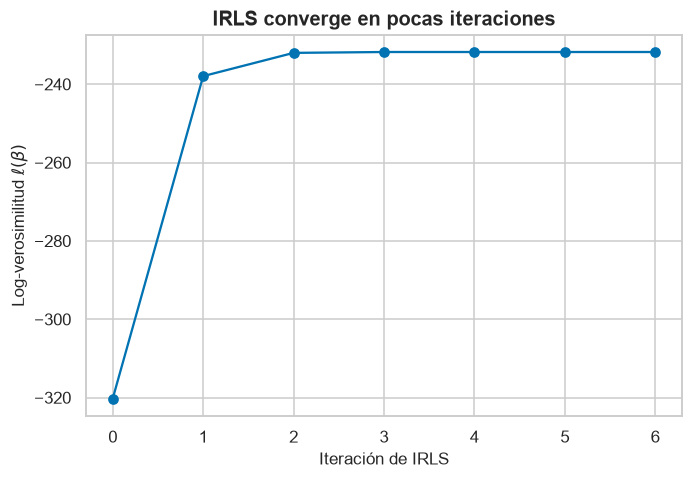

In [17]:
def loglik_log(beta, X, y):
    eta = X @ beta
    return np.sum(y * eta - np.logaddexp(0, eta))    # (4.20), estable numéricamente

def irls_log(X, y, tol=1e-10, max_iter=25):
    beta = np.zeros(X.shape[1])                      # arranque sugerido por el libro
    historia = [loglik_log(beta, X, y)]
    for _ in range(max_iter):
        p = 1 / (1 + np.exp(-(X @ beta)))
        w = p * (1 - p)                              # diagonal de W
        z = X @ beta + (y - p) / w                   # respuesta ajustada (4.27)
        XtWX = X.T @ (w[:, None] * X)
        beta = np.linalg.solve(XtWX, X.T @ (w * z))  # cuadrados mínimos ponderados (4.26)
        historia.append(loglik_log(beta, X, y))
        if abs(historia[-1] - historia[-2]) < tol:
            break
    return beta, historia, XtWX

X_log = np.column_stack([np.ones(n_log), df_log[nombres_log].values])   # columna de unos = intercepto
beta_irls_log, hist_log, XtWX_log = irls_log(X_log, y_log)

for i, l in enumerate(hist_log):
    print(f"iteración {i}: log-verosimilitud = {l:.6f}")

p_hat_log = 1 / (1 + np.exp(-(X_log @ beta_irls_log)))
print("\nsuma(y) =", y_log.sum(), "| suma(p_hat) =", p_hat_log.sum().round(6), " <- primera ecuación de score")
print("score X'(y-p) ~ 0:", np.abs(X_log.T @ (y_log - p_hat_log)).max().round(10))

fig, ax = plt.subplots()
ax.plot(range(len(hist_log)), hist_log, "o-")
ax.set_xlabel("Iteración de IRLS")
ax.set_ylabel(r"Log-verosimilitud $\ell(\beta)$")
ax.set_title("IRLS converge en pocas iteraciones")
plt.show()

La log-verosimilitud sube monótonamente y se estabiliza en la iteración 4 (a seis decimales, celda de IRLS de arriba: $-237{,}9\to-232{,}0\to-231{,}79\to-231{,}7879$); Newton converge muy rápido cerca del máximo. También se cumplen las propiedades de la teoría: $\sum y_i=\sum\hat p_i=146$ y el score es $\approx 0$ (del orden de $10^{-10}$). No hizo falta reducir el paso a la mitad.

#### 🏭 Así se hace en la industria

`statsmodels` (enfoque estadístico: errores estándar, tests) y `sklearn` (enfoque predictivo; con `C=np.inf` resuelve sin penalización). La tabla compara además dos cantidades que vamos a usar en 4.4.2: el **error estándar** (EE: cuánto se movería $\hat\beta_j$ de muestra a muestra) y el **Z-score** $Z_j=\hat\beta_j/\mathrm{EE}_j$ (a cuántos errores estándar de cero queda el coeficiente). Los EE salen de la diagonal de $(\mathbf{X}^T\hat{\mathbf{W}}\mathbf{X})^{-1}$; por qué, en 4.4.3.

In [18]:
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression

cov_log = np.linalg.inv(XtWX_log)                 # (X' W X)^{-1} evaluada en beta-sombrero
se_irls_log = np.sqrt(np.diag(cov_log))

res_sm_log = sm.Logit(y_log, X_log).fit(disp=0)   # Newton (la misma idea) con errores estándar
skl_log = LogisticRegression(C=np.inf, max_iter=5000).fit(X_log[:, 1:], y_log)

idx_log = ["(Intercept)"] + nombres_log
tabla_log = pd.DataFrame({
    "coef IRLS": beta_irls_log, "coef statsmodels": res_sm_log.params,
    "coef sklearn": np.r_[skl_log.intercept_, skl_log.coef_.ravel()],
    "EE IRLS": se_irls_log, "EE statsmodels": res_sm_log.bse,
    "Z IRLS": beta_irls_log / se_irls_log, "Z statsmodels": res_sm_log.tvalues,
}, index=idx_log)
print(tabla_log.round(3).to_string())
print("\ncoeficientes coinciden (IRLS vs statsmodels):", np.allclose(beta_irls_log, res_sm_log.params, atol=1e-6))
print("coeficientes coinciden (IRLS vs sklearn)    :", np.allclose(beta_irls_log, tabla_log["coef sklearn"], atol=1e-3))
print("errores estándar coinciden                  :", np.allclose(se_irls_log, res_sm_log.bse, atol=1e-6))

             coef IRLS  coef statsmodels  coef sklearn  EE IRLS  EE statsmodels  Z IRLS  Z statsmodels
(Intercept)     -6.230            -6.230        -6.230    1.243           1.243  -5.014         -5.014
sbp              0.015             0.015         0.015    0.008           0.008   1.961          1.961
tobacco          0.096             0.096         0.096    0.032           0.032   3.039          3.039
ldl              0.126             0.126         0.126    0.074           0.074   1.715          1.715
famhist          0.846             0.846         0.846    0.233           0.233   3.629          3.629
obesity         -0.069            -0.069        -0.069    0.034           0.034  -2.014         -2.014
alcohol          0.002             0.002         0.002    0.006           0.006   0.295          0.295
age              0.080             0.080         0.080    0.011           0.011   7.055          7.055

coeficientes coinciden (IRLS vs statsmodels): True
coeficientes coincide

Tres implementaciones, mismos números (`sklearn` coincide hasta la tolerancia del optimizador: usa L-BFGS, no Newton). `statsmodels.GLM(..., family=Binomial())` también daría lo mismo: es el GLM que el libro menciona en 4.4.3, implementado con IRLS.

#### ⚠️ Confusión típica

- Pensar que IRLS y "descenso por gradiente" son lo mismo. El gradiente usa solo la pendiente; Newton usa también la curvatura (el Hessiano), y por eso converge en una decena de iteraciones y no en cientos.
- Olvidarse de la columna de unos. En ESL el intercepto está *dentro* de $x_i$; sin ella el modelo no tiene constante y deja de valer $\sum y_i=\sum\hat p_i$.
- Que $p=0{,}5$ sea la frontera: lo es **bajo pérdida 0-1**. Si los errores cuestan distinto (clase 1, §6; ESL §2.4) conviene mover el umbral, y como la logística entrega $\hat p(x)$ lo hacés después de ajustar, sin tocar el modelo.

La pregunta que queda abierta (separabilidad perfecta, donde $\ell$ no tiene máximo finito) la retomamos en 4.4.5.

### 4.4.2 Cómo se lee un modelo logístico ajustado

#### La idea en criollo

**Pregunta guía: ¿qué me dice cada coeficiente?** Que $\hat\beta_j$ es el **cambio en el log-odds** de la clase 1 por cada unidad más de $x_j$, **con los demás predictores fijos**. Si lo exponenciás, $e^{\hat\beta_j}$ es el **odds ratio**: por cuánto se **multiplican los odds** por cada unidad más (cuidado: cambia el *odds*, no la probabilidad). Y el $Z_j$ de la tabla de arriba dice qué tan lejos de cero está el coeficiente en unidades de error estándar; $|Z|>2$ equivale aproximadamente a significativo al 5%, y se justifica en 4.4.3.

El libro (ESL §4.4.2) usa la logística en su modo "clásico" sobre datos reales de riesgo coronario: no para predecir mejor sino para **entender** qué factores pesan (**inferencia** y no predicción, clase 1 §1). Nosotros leemos la tabla de la comparación de implementaciones (más arriba), que es de datos simulados.

#### Ejemplo 1: odds ratio de `tobacco`

En esa tabla, el coeficiente de `tobacco` es $0{,}096$ (EE $0{,}032$, $Z=3{,}04$). Entonces una unidad más de `tobacco` multiplica los odds por $e^{0{,}096}=1{,}10$ (la celda de abajo calcula OR $=1{,}101$), unos 10% más de odds. Con el error estándar, un intervalo aproximado del 95% es $e^{\hat\beta\pm2\,\mathrm{EE}}$, que da $(1{,}033;\,1{,}173)$ (misma celda).

#### Ejemplo 2: el mensaje de fondo, predictores correlacionados

`sbp`, `obesity` y la edad están correlacionadas en nuestros datos (corr(`sbp`, `obesity`) $=0{,}29$ y corr(`sbp`, `age`) $=0{,}30$, en la celda de los datos). Compará cada una **sola** contra **con todas** (celda de abajo):

| | sola: coef., $Z$ | con todas: coef., $Z$ |
|---|---|---|
| `sbp` | $0{,}023$, $3{,}59$ | $0{,}015$, $1{,}96$ |
| `obesity` | $0{,}015$, $0{,}55$ | $-0{,}069$, $-2{,}01$ |

`sbp` pasa de muy significativa a marginal, y `obesity` cambia de signo. Los números exactos dependen de la semilla, pero el fenómeno es el que el libro señala: **el coeficiente de una variable depende de qué otras estén en el modelo**, y por lo tanto un coeficiente no es un efecto marginal.

#### ¿Por qué nos importa?

Porque es el problema de multicolinealidad de regresión lineal en escala de log-odds: con predictores correlacionados el modelo puede predecir bien aunque el reparto de coeficientes sea inestable.

In [19]:
# 1) ¿Las variables correlacionadas "se pisan"? sbp y obesity solas vs con todas
solo_log = {v: sm.Logit(y_log, sm.add_constant(df_log[[v]])).fit(disp=0) for v in ["sbp", "obesity"]}
for v, r in solo_log.items():
    print(f"{v:8s} sola  : coef = {r.params[v]: .3f}, Z = {r.tvalues[v]: .2f}")
    print(f"{v:8s} todas : coef = {res_sm_log.params[idx_log.index(v)]: .3f}, Z = {res_sm_log.tvalues[idx_log.index(v)]: .2f}")

# 2) Odds ratio de tobacco con IC aproximado del 95% (coef +/- 2 EE, como en el libro)
b_t, se_t = res_sm_log.params[2], res_sm_log.bse[2]
print(f"\ntobacco: OR = {np.exp(b_t):.3f}, IC95% ~ ({np.exp(b_t - 2*se_t):.3f}, {np.exp(b_t + 2*se_t):.3f})")

sbp      sola  : coef =  0.023, Z =  3.59
sbp      todas : coef =  0.015, Z =  1.96
obesity  sola  : coef =  0.015, Z =  0.55
obesity  todas : coef = -0.069, Z = -2.01

tobacco: OR = 1.101, IC95% ~ (1.033, 1.173)


#### ⚠️ Confusión típica

Leer un Z chico como "esta variable no importa". Lo que dice es que, **dado el resto del modelo**, su aporte adicional no se distingue del ruido; si sacás una y queda adentro otra correlacionada, la información sigue estando. Y $|Z|>2$ no dice que sea un *buen predictor*, sino que el coeficiente es estadísticamente distinto de cero.

> 🔗 **Conexión con las clases 3 y 5**: lo de `obesity` cambiando de signo es el experimento de la clase 3 (columnas casi redundantes: cada coeficiente salta y solo el efecto conjunto es estable), ahora en log-odds, y es la advertencia de la clase 4 (nube estirada). Lo mismo vale para un coeficiente en cero en el lasso de la clase 5: dice que, **dadas las demás variables que quedaron**, ésa no agrega algo distinguible, no que no esté relacionada con $G$. El libro elimina de a una la variable de menor $|Z|$ (selección de subconjuntos, la versión "dura" y discontinua); en 4.4.4 va la relajación continua, la penalización L1.

### 4.4.3 Inferencia: de dónde salen el error estándar y el Z-score

#### La idea en criollo

**Pregunta guía: ¿de dónde salen el EE y el Z de la tabla, y qué tan en serio tomarlos?** Cuando IRLS converge, el ajuste final **es** una regresión ponderada con pesos $\hat w_i=\hat p_i(1-\hat p_i)$ y respuesta $z_i=x_i^T\hat\beta+\frac{y_i-\hat p_i}{\hat p_i(1-\hat p_i)}$ (4.29). Por eso casi toda la inferencia de regresión lineal (clase 2) se traslada, pero valiendo **asintóticamente** (muestras grandes), no de forma exacta como con errores normales.

#### Formalizándolo

1. **Normalidad asintótica.** Por el teorema central del límite, $\hat\beta$ se distribuye aproximadamente $N\big(\beta,(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\big)$. El EE de $\hat\beta_j$ es la raíz del $j$-ésimo elemento de la diagonal de $(\mathbf{X}^T\hat{\mathbf{W}}\mathbf{X})^{-1}$ (lo calculamos en `se_irls_log`, en la tabla de comparación, y coincide con `statsmodels`), y $Z_j=\hat\beta_j/\mathrm{EE}_j$ se compara con una normal estándar: es el **test de Wald** de que $\beta_j=0$ con los demás en el modelo.
2. **Por qué esa covarianza y no $\sigma^2(\mathbf X^T\mathbf X)^{-1}$.** En cuadrados mínimos ponderados con pesos iguales a la inversa de $\mathrm{Var}(z_i)$, la covarianza es $(\mathbf X^T\mathbf W\mathbf X)^{-1}$. Acá se cumple: $\mathrm{Var}(y_i)=p_i(1-p_i)$ (Bernoulli), así que $\mathrm{Var}(z_i)=\frac{p_i(1-p_i)}{[p_i(1-p_i)]^2}=\frac1{w_i}$. La varianza **no hay que estimarla aparte** (la fija la Bernoulli), a diferencia de $\sigma^2$ en lineal. Es la justificación heurística del libro; la rigurosa pasa por la información de Fisher.
3. **Deviance, para comparar modelos.** La **deviance residual** de un modelo es $-2\ell$ (análoga al $RSS$), y la deviance entre dos modelos anidados es la diferencia: $D=-2(\ell_{chico}-\ell_{grande})$. Si los términos extra del grande valen cero, $D$ es aproximadamente $\chi^2$ con tantos grados de libertad como parámetros quitaste. Sirve para decidir si un **grupo** de términos aporta (los Z individuales no alcanzan, por ejemplo con una categórica de varias dummies), y cumple el papel del $F$ de la clase 2. (Notación: acá $D$ es la deviance; en §4.5.1 la misma letra será el criterio del perceptrón.)

*(Aviso: el libro agrega el estadístico de Pearson y los tests de score de Rao y de Wald como atajos que no requieren reajustar; **no los usamos más adelante**.)*

#### ¿Por qué nos importa?

Porque dice **qué tan en serio tomar cada coeficiente** y cómo comparar modelos candidatos.

#### ⚠️ Confusión típica

- Asumir que "$\hat\beta$ es normal" vale siempre. Es **asintótico**: con pocos datos o casi-separación, el Wald se vuelve poco confiable y los EE explotan; el test de deviance es más robusto.
- Confundir la deviance con $R^2$. Siempre baja al agregar variables (igual que el $RSS$), por eso se compara *entre modelos anidados* con su $\chi^2$ y no se mira sola.

### 4.4.4 Regresión logística con regularización L1

#### La idea en criollo

**Pregunta guía: ¿cómo seleccionamos variables y encogemos coeficientes cuando hay muchos predictores o están muy correlacionados?** Respuesta: es el lasso (📕 ESL §3.4.2) con la log-verosimilitud en lugar de la suma de cuadrados. La **penalización L1** es $\lambda\sum_j|\beta_j|$ (la suma de los módulos de los coeficientes, con $\lambda\ge0$ una perilla que decide cuánto castigar). Se le resta a $\ell$: cada coeficiente "cuesta" y solo se queda si compensa su costo; los que no, se vuelven **exactamente cero**.

#### Formalizándolo

$$\max_{\beta_0,\beta}\left\{\sum_{i=1}^N\Big[y_i(\beta_0+\beta^Tx_i)-\log\big(1+e^{\beta_0+\beta^Tx_i}\big)\Big]-\lambda\sum_{j=1}^p|\beta_j|\right\}\qquad\text{(4.31)}.$$

Dos convenciones, como en lasso: **no se penaliza el intercepto** $\beta_0$ y se **estandarizan** los predictores (si no, una variable medida en miles pagaría muy poco por un coeficiente grande y la penalidad dependería de las unidades).

(4.31) es **cóncavo**: todo máximo local es global, no hay máximos locales falsos. (Cóncavo no es lo mismo que estrictamente cóncavo: el máximo puede no ser único. Con dos columnas clonadas, $x_1=x_2$, la log-verosimilitud solo depende de $\beta_1+\beta_2$ y la penalización $|\beta_1|+|\beta_2|$ no distingue cómo se reparte ese total entre las dos, así que hay un continuo de soluciones.) Para hallarlo: repetir el IRLS de 4.4.1 resolviendo en cada paso un **lasso ponderado** (pesos $W_{ii}$, respuesta $z_i$), que se hace con descenso por coordenadas y *soft-thresholding* de la clase 5 (es lo que hace `glmnet`); o seguir el camino exacto con `glmpath`. Los caminos de coeficientes son suaves por tramos, **no** lineales por tramos como en el lasso de mínimos cuadrados, así que LAR no sirve directo.

Para las variables con coeficiente **distinto de cero**, el score queda $x_j^T(\mathbf{y}-\mathbf{p})=\lambda\cdot\mathrm{sign}(\beta_j)$ (4.32, con $x_j$ la columna $j$ estandarizada): las variables activas están **empatadas** en su correlación con el residuo $\mathbf{y}-\mathbf{p}$. Para las de coeficiente **cero** la condición es una desigualdad, $|x_j^T(\mathbf y-\mathbf p)|\le\lambda$ (el subgradiente del lasso; consecuencia estándar que el libro no escribe): la variable queda afuera mientras su correlación con el residuo no supere $\lambda$, que es la zona muerta del *soft-thresholding*. Con $\lambda=0$ es el score (4.21). En el otro extremo, si $\lambda\ge\max_j|x_j^T(\mathbf y-\hat{\mathbf p}_0)|$, con $\hat{\mathbf p}_0=\bar y\,\mathbf 1$ (las probabilidades del modelo con solo intercepto), la desigualdad se cumple para todas las variables y **todos los coeficientes quedan en cero**.

#### En `sklearn`

El parámetro es $C=1/\lambda$ **sin factor $N$**: minimiza $C\sum_i\text{pérdida}_i+\|\beta\|_1$. **Menos $C$ = más regularización**, al revés que $\lambda$. Es una trampa de equivalencias: ni el `alpha` de `Lasso` (costo $\tfrac1{2N}$) ni el $\lambda$ de (4.31) valen como $C$; escribí las dos funciones de costo una al lado de la otra antes de pasar un número entre implementaciones. Se pide L1 con `l1_ratio=1` (y `solver="liblinear"` o `saga`).

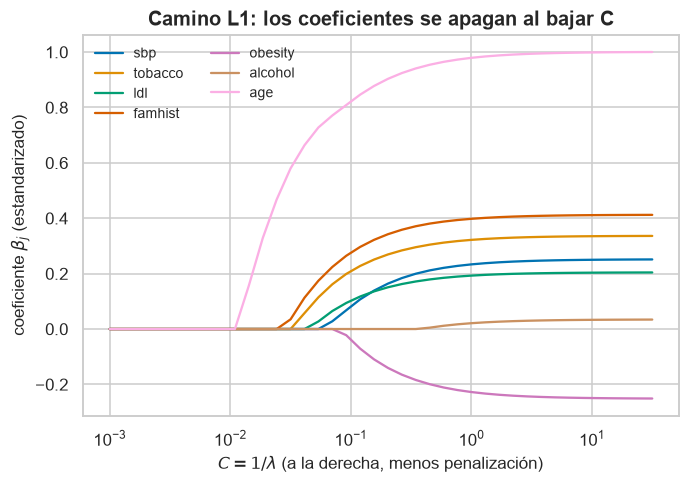

1/lambda_max = 0.0117: con C menor todos los coeficientes son cero
Se activan al subir C (el primero es el último en apagarse al bajarlo): ['age', 'famhist', 'tobacco', 'ldl', 'sbp', 'obesity', 'alcohol']


In [20]:
from sklearn.preprocessing import StandardScaler

Z_log = StandardScaler().fit_transform(df_log[nombres_log])      # predictores estandarizados (convención de 4.31)
lam_max = np.abs(Z_log.T @ (y_log - y_log.mean())).max()          # lambda a partir del cual todo queda en cero
Cs_log = np.logspace(-3, 1.5, 40)
camino_log = np.array([LogisticRegression(l1_ratio=1, C=C, solver="saga", max_iter=20000, tol=1e-6).fit(Z_log, y_log).coef_.ravel()
                       for C in Cs_log])                          # saga no penaliza el intercepto, como en 4.31

fig, ax = plt.subplots()
for j, nom in enumerate(nombres_log):
    ax.plot(Cs_log, camino_log[:, j], label=nom)
ax.set_xscale("log"); ax.set_xlabel(r"$C = 1/\lambda$ (a la derecha, menos penalización)"); ax.set_ylabel(r"coeficiente $\beta_j$ (estandarizado)")
ax.set_title("Camino L1: los coeficientes se apagan al bajar C"); ax.legend(ncol=2, fontsize=9); plt.show()

activa_log = {nom: Cs_log[np.argmax(camino_log[:, j] != 0)] for j, nom in enumerate(nombres_log)}   # menor C con coef. != 0
print(f"1/lambda_max = {1 / lam_max:.4f}: con C menor todos los coeficientes son cero")
print("Se activan al subir C (el primero es el último en apagarse al bajarlo):", sorted(activa_log, key=activa_log.get))

Leé el gráfico de derecha a izquierda: partimos de casi sin penalización (los coeficientes de la logística común) y, al bajar $C$, los coeficientes se encogen y las variables **salen una a una**, no todas juntas. Las menos informativas se apagan primero y las más informativas aguantan hasta el final: en nuestros datos `alcohol` sale primero, luego `obesity` y `sbp`, y `age`, `famhist` y `tobacco` son las últimas en irse (el último `print` da el orden completo, leído de atrás hacia adelante). Por debajo de $C=1/\lambda_{\max}$ (el primer `print`: $0{,}0117$) quedan todos en cero (el caso $\lambda\ge\lambda_{\max}$ de 4.4.4). El orden de salida se lee como un ranking de importancia, igual que en el lasso de la clase 5.

#### ¿Por qué nos importa?

Es el camino estándar cuando $p$ se acerca a $N$ o lo supera (genómica, texto), donde la logística sin penalizar ni siquiera existe (separación, 4.4.5).

> 🔗 **Conexión con la clase 5**: (4.32) es la ecuación del lasso ($\beta_j-a+\lambda\,\mathrm{sign}(\beta_j)=0$) con el residuo $\mathbf y-\mathbf p$ en lugar del residuo parcial, y los pesos $W_{ii}$ rompen el supuesto $\sum_ix_{ij}^2=N$ (queda $\sum_iW_{ii}x_{ij}^2$): misma técnica, $p$ problemas de una variable en ronda. En el eje $\|\beta(\lambda)\|_1$ el $\lambda$ chico es la derecha, $t$ grande de la forma con restricción. El orden en que se apagan las variables se lee como un ranking, igual que allá (esto de los pesos y el eje no lo escribe el libro: sale de repetir la cuenta de la clase).

### 4.4.5 ¿Logística o LDA?

#### La idea en criollo

**Pregunta guía: si las dos dan logits lineales en $x$, ¿en qué se diferencian?** En **cómo se estiman los coeficientes**, y por lo tanto en **qué supuestos** hacen falta. LDA es **generativo**: modela la densidad conjunta $\Pr(X,G)$ (gaussianas con covarianza común) y deriva la posterior. La logística es **discriminativa**: modela solo $\Pr(G\mid X)$ y deja $\Pr(X)$ libre.

#### Formalizándolo

De §4.3, los log-odds a posteriori de LDA son lineales **como consecuencia** de suponer gaussianas con covarianza común $\Sigma$ (4.9, 4.33): $\log\frac{\Pr(G=k\mid x)}{\Pr(G=K\mid x)}=\alpha_{k0}+\alpha_k^Tx$. La logística los tiene lineales **por construcción** (4.34): $\beta_{k0}+\beta_k^Tx$. Misma forma; cambia qué se hace con $\Pr(X)$, en $\Pr(X,G=k)=\Pr(X)\Pr(G=k\mid X)$ (4.35):

- **Logística:** maximiza la verosimilitud **condicional** (la multinomial de $\Pr(G=k\mid X)$). $\Pr(X)$ queda como una densidad arbitraria (se puede pensar como la distribución empírica, masa $1/N$ en cada observación).
- **LDA:** maximiza la verosimilitud **completa**, la de la conjunta $\Pr(X,G=k)=\phi(X;\mu_k,\Sigma)\pi_k$ (4.37; $\phi$ la densidad gaussiana). Los $\hat\mu_k,\hat\Sigma,\hat\pi_k$ son los de §4.3 y los parámetros lineales se obtienen **por plug-in** (se reemplazan en las fórmulas de 4.33). Acá la marginal de $X$ **sí importa**: es la **mezcla** $\Pr(X)=\sum_{k=1}^K\pi_k\,\phi(X;\mu_k,\Sigma)$ (4.38), que depende de los mismos parámetros.

**¿Qué aporta ese componente extra?** Más información sobre los parámetros, o sea **menor varianza**. Si las densidades verdaderas son gaussianas, ignorar la marginal cuesta, en el peor caso y asintóticamente, **alrededor de 30%** de eficiencia en la tasa de error (el libro cita a Efron, 1975): la condicional necesita ~30% más de datos para rendir igual. Otras consecuencias que lista el libro:

- Las observaciones **lejos de la frontera** (que la logística desvaloriza con los pesos $p(1-p)$) sí participan en la covarianza común de LDA. No todo es bueno: **LDA no es robusto a outliers groseros**.
- Con la formulación de mezcla, hasta las observaciones **sin etiqueta** aportan información (etiquetar es caro, no etiquetar es barato).
- La verosimilitud marginal actúa como **regularizador**. Con clases **perfectamente separables** el máximo de la logística **no existe**, mientras que LDA da coeficientes finitos para esos datos (ejercicio 4.5).

En la práctica los supuestos nunca valen del todo. El libro opina que la logística es la apuesta **más segura y robusta** por depender de menos supuestos, y agrega que en su experiencia ambos dan resultados muy parecidos incluso con LDA usado de forma inapropiada (p. ej. predictores cualitativos).

#### ¿Por qué nos importa?

Es el dilema generativo vs discriminativo: *más supuestos* = *menos varianza* si son ciertos, *más sesgo* si no. Te sirve para elegir con cuál empezar.

#### En código

Tres experimentos chicos. (0) El ejemplo corriente de §4.3: misma forma, otros coeficientes. (1) 200 réplicas ($N=100$, $p=5$) con tres escenarios: gaussiano con covarianza común (valen los supuestos de LDA), lognormal (asimétrico, no gaussiano) y gaussiano con 5% de outliers groseros en el entrenamiento. (2) Datos perfectamente separables.

In [21]:
# (0) Ejemplo corriente de 4.3 (X_e, g_e): misma forma, distintos coeficientes
lr_e = LogisticRegression(C=np.inf, max_iter=5000).fit(X_e, g_e)
for nombre, m in [("LDA", lda_e), ("Logística", lr_e)]:
    print(f"{nombre:10s} coef = {m.coef_[0].round(2)}, intercepto = {m.intercept_[0]:.2f}, error de test = {1 - m.score(Xt_e, gt_e):.3f}")

LDA        coef = [0.97 1.  ], intercepto = -1.88, error de test = 0.190
Logística  coef = [1.02 1.35], intercepto = -2.14, error de test = 0.191


Misma forma ($\beta_0+\beta^Tx$, acá con $p=2$), distintos coeficientes: LDA los saca de $\hat\mu_k$ y $\hat\Sigma$ por plug-in, la logística maximizando la verosimilitud condicional. Las dos rectas apuntan parecido y el error de test es prácticamente el mismo, porque en este ejemplo los datos sí son gaussianos con covarianza común: justo el escenario donde LDA no pierde.

Error de test medio (200 réplicas)
               LDA Logística
gaussiano  24.49 %   24.53 %
lognormal  27.82 %    26.7 %
outliers   36.96 %   31.66 %


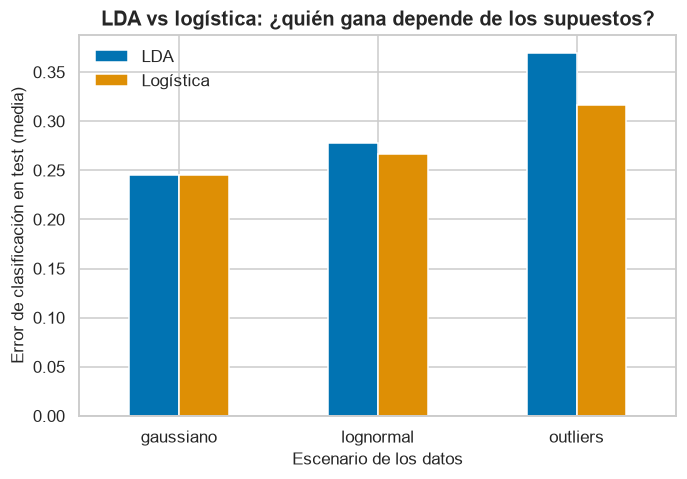

In [22]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def generar_log(rng, n, escenario, p=5, dif=1.0):
    y = rng.binomial(1, 0.5, n)
    X = rng.normal(size=(n, p)) + dif * y[:, None] * np.array([1, .8, .6, .4, .2])  # medias distintas, cov = I
    if escenario == "lognormal":
        X = np.exp(X / 1.2)                     # asimétrica, NO gaussiana
    return X, y

def outliers_log(rng, X, y, frac=0.05):
    X, y = X.copy(), y.copy()
    k = rng.choice(len(y), int(frac * len(y)), replace=False)
    X[k] = X[k] + rng.normal(0, 1, (len(k), X.shape[1])) * 25 * (1 - 2 * y[k, None])   # muy lejos, del lado equivocado
    return X, y

resultados_log = {}
for esc in ["gaussiano", "lognormal", "outliers"]:
    errs = {"LDA": [], "Logística": []}
    for semilla in range(200):
        rng = np.random.default_rng(semilla)
        Xtr, ytr = generar_log(rng, 100, "lognormal" if esc == "lognormal" else "gaussiano")
        if esc == "outliers":
            Xtr, ytr = outliers_log(rng, Xtr, ytr)
        Xte, yte = generar_log(np.random.default_rng(10_000 + semilla), 4000, "lognormal" if esc == "lognormal" else "gaussiano")
        for nombre, modelo in [("LDA", LinearDiscriminantAnalysis()),
                               ("Logística", LogisticRegression(C=np.inf, max_iter=5000))]:
            errs[nombre].append(1 - modelo.fit(Xtr, ytr).score(Xte, yte))
    resultados_log[esc] = {k: np.mean(v) for k, v in errs.items()}

res_df_log = pd.DataFrame(resultados_log).T
print("Error de test medio (200 réplicas)")
print((100 * res_df_log).round(2).astype(str) + " %")

ax = res_df_log.plot.bar(rot=0)
ax.set_xlabel("Escenario de los datos")
ax.set_ylabel("Error de clasificación en test (media)")
ax.set_title("LDA vs logística: ¿quién gana depende de los supuestos?")
plt.show()

Resultados (celda de arriba, error de test medio): gaussiano $24{,}49\%$ (LDA) vs $24{,}53\%$ (logística): **empatan** (con estas diferencias entre medias y $N=100$ no se nota la eficiencia extra de LDA). Lognormal: $27{,}82\%$ vs $26{,}70\%$, la logística apenas mejor donde el supuesto de LDA no vale. Con outliers: LDA pasa de $24{,}49\%$ a $36{,}96\%$ y la logística de $24{,}53\%$ a $31{,}66\%$. LDA sufre más porque la covarianza común se infla con todos los puntos, lejanos o no. Pero no sobreinterpretes $p(1-p)$: un outlier del lado equivocado igual aporta $x_i(y_i-p_i)$ al score con $|y_i-p_i|\approx1$. **La logística es más robusta acá, no inmune.**

In [23]:
rng_log = np.random.default_rng(3)
Xsep_log = np.r_[rng_log.normal(-2, 0.5, (20, 2)), rng_log.normal(2, 0.5, (20, 2))]
ysep_log = np.r_[np.zeros(20), np.ones(20)]
Xsep1_log = np.column_stack([np.ones(40), Xsep_log])

# Logística sin penalizar: los coeficientes crecen con cada iteración de Newton (no hay máximo finito)
beta_log = np.zeros(3)
for it in range(1, 16):
    p = 1 / (1 + np.exp(-np.clip(Xsep1_log @ beta_log, -30, 30)))
    w = np.clip(p * (1 - p), 1e-10, None)
    beta_log = beta_log + np.linalg.solve(Xsep1_log.T @ (w[:, None] * Xsep1_log), Xsep1_log.T @ (ysep_log - p))
    if it in (1, 3, 6, 10, 15):
        print(f"iteración {it:2d}: ||beta|| = {np.linalg.norm(beta_log):9.2f}")

lda_sep_log = LinearDiscriminantAnalysis().fit(Xsep_log, ysep_log)
print("\nLDA (finito y bien definido): coef =", lda_sep_log.coef_.round(2), " intercepto =", lda_sep_log.intercept_.round(2))

iteración  1: ||beta|| =      0.70
iteración  3: ||beta|| =      1.52
iteración  6: ||beta|| =      2.78
iteración 10: ||beta|| =      4.61
iteración 15: ||beta|| =      7.07

LDA (finito y bien definido): coef = [[14.76 14.38]]  intercepto = [1.38]


#### Separabilidad: el máximo no existe (matiz importante)

En la celda de arriba, con clases separables, $\|\hat\beta\|$ de la logística sin penalizar **crece sin parar** con cada iteración de Newton ($0{,}70$ en la 1, $7{,}07$ en la 15), mientras LDA da un número finito y estable. La razón: una vez que un hiperplano separa todo, multiplicar $\beta$ por una constante mayor que 1 acerca cada $p_i$ a 0 o 1 y **siempre** sube la log-verosimilitud, que tiende a 0 sin alcanzarlo. Entonces **el estimador de máxima verosimilitud no existe** ($\hat\beta$ diverge). Lo que sí se estabiliza es la **dirección** $\beta/\|\beta\|$, que apunta a un hiperplano separador. Por eso la frase del libro "la logística siempre encuentra un hiperplano separador" hay que leerla así: encuentra la *dirección* de uno, no un $\hat\beta$ finito. La verosimilitud marginal de LDA no permite esas degeneraciones.

La salida práctica es ridge (clase 4): $\ell$ no puede subir de 0 pero el peaje $\lambda\|\beta\|^2$ crece sin límite con $\|\beta\|$, así que el óptimo penalizado queda a distancia finita. Por eso `sklearn` usa L2 por defecto y `statsmodels` avisa cuando detecta separación perfecta.

#### ⚠️ Confusión típica

- Creer que "logística = no lineal y LDA = lineal". Las dos tienen frontera lineal.
- Creer que la logística es *siempre* mejor porque hace menos supuestos. Con datos gaussianos y $N$ chico LDA puede ganar por varianza, y con datos sin etiquetar LDA les saca provecho y la logística no.
- Pensar que "menos supuestos" es "sin supuestos": la logística sigue asumiendo el logit **lineal en $x$** (en la forma de $x$ que elijas).

#### ❓ La pregunta que quedó abierta

Si LDA y la logística suelen dar resultados parecidos, ¿hay una tercera manera de elegir una frontera lineal, que no modele ni densidades ni probabilidades? Sí: elegirla por **geometría**, buscando directamente un hiperplano que separe las clases. Eso es §4.5. Para abandonar de verdad la linealidad hay que agrandar el espacio de variables con funciones de base (📕 ESL cap. 5) o usar kernels (cap. 12).

## 4.5 Hiperplanos separadores

📕 ESL §4.5 (con §4.5.1 y §4.5.2) · puente a 📕 ESL cap. 12 (SVM)

**La pregunta de la sección:** si las clases se pueden separar con una recta (o un plano), ¿cómo encontramos esa frontera *directamente*, sin modelar densidades ni probabilidades? Hay dos respuestas, y la segunda mejora a la primera: el **perceptrón** (cualquier separador sirve) y el **hiperplano óptimo** (el separador que deja más margen). Antes de ninguna de las dos hace falta la geometría de un hiperplano. ESL avisa que el nivel matemático sube un escalón respecto de las secciones anteriores; vamos despacio.

### Geometría de un hiperplano

**Pregunta guía:** dada una frontera lineal, ¿cómo sé de qué lado cae un punto y a qué distancia está? **Respuesta corta:** el *signo* de $f(x)=\beta_0+\beta^Tx$ dice el lado, y $f(x)/\|\beta\|$ es la distancia con signo. Veamos de dónde sale.

#### La idea en criollo

Un **hiperplano** es la generalización de una recta (en $\mathbb{R}^2$) o de un plano (en $\mathbb{R}^3$): el conjunto de puntos que cumple una ecuación lineal. Divide el espacio en dos lados, y clasificar es preguntar de qué lado cae cada punto.

Pensá en una red de tenis. La red es la frontera: la pelota cae de un lado o del otro, y además podés preguntar **a qué distancia de la red** está.

> **Dónde se rompe la analogía.** La "distancia con signo" no es un valor absoluto: el signo dice de qué lado estás, y eso es justo lo que usa el clasificador. Y la red tiene orientación y altura fijas, mientras que un hiperplano en $\mathbb{R}^p$ se puede inclinar y correr de lugar de $p$ maneras independientes (aunque $(\beta,\beta_0)$ tenga $p+1$ números, multiplicarlos todos por una constante no cambia el hiperplano).

#### Formalizándolo

Un hiperplano (ESL lo llama *conjunto afín* $L$) es el conjunto de puntos $x$ donde

$$f(x) = \beta_0 + \beta^T x = 0 \qquad (4.39)$$

Acá $\beta$ ("beta") es un vector con una coordenada por variable: marca una dirección en el espacio de las variables. $\beta_0$ es el intercepto: corre el hiperplano de lugar. Y $\|\beta\|=\sqrt{\beta_1^2+\dots+\beta_p^2}$ es la longitud de $\beta$. Tres propiedades, que ESL lista en §4.5:

**1. $\beta$ es perpendicular a $L$.** *Qué buscamos:* saber hacia dónde "mira" el hiperplano. Tomá dos puntos $x_1,x_2$ sobre $L$: cumplen $\beta_0+\beta^Tx_1=0$ y $\beta_0+\beta^Tx_2=0$. Restando, **$\beta^T(x_1-x_2)=0$**. El vector $x_1-x_2$ yace dentro de $L$ (cualquier dirección dentro del plano se obtiene así) y su producto con $\beta$ da cero, así que $\beta$ es ortogonal a todo $L$. Dividiéndolo por su longitud tenemos el **vector normal unitario** $\beta^*=\beta/\|\beta\|$: apunta perpendicular a $L$ y mide 1.

**2. Para cualquier $x_0\in L$, $\beta^Tx_0=-\beta_0$.** Sale directo de $f(x_0)=0$.

**3. Distancia con signo.** *Qué buscamos:* la distancia de un punto cualquiera $x$ a $L$. Elegimos un punto $x_0$ cualquiera sobre $L$ (un "ancla" desde donde medir) y proyectamos el vector $x-x_0$ sobre la normal unitaria. Proyectar sobre un vector unitario $u$ es hacer $u^T(\cdot)$, y da la parte del segmento que es perpendicular a $L$, o sea la distancia:

$$\beta^{*T}(x-x_0)=\frac{1}{\|\beta\|}\left(\beta^Tx-\beta^Tx_0\right)=\frac{1}{\|\beta\|}\left(\beta^Tx+\beta_0\right)=\frac{f(x)}{\|\beta\|}\qquad (4.40)$$

En el segundo paso usamos la propiedad 2. **Conclusión: $f(x)/\|\beta\|$ es la distancia con signo de $x$ a $L$** (positiva de un lado, negativa del otro), y no depende de qué $x_0$ elegiste. Por eso $f(x)$ sola es proporcional a la distancia, y vale exactamente eso sólo si $\|\beta\|=1$.

**La figura del libro (ESL Fig. 4.15; no la reproducimos).** Está en $\mathbb{R}^2$, donde $L$ es una recta. Mirá tres elementos: un punto $x_0$ sobre la recta, el vector $\beta^*$ saliendo en perpendicular, y un punto $x$ cualquiera. La distancia con signo es la sombra del segmento $x_0\to x$ sobre $\beta^*$.

#### ¿Por qué nos importa?

Porque todo lo que sigue se escribe con esa cantidad. El perceptrón penaliza $-y_if(x_i)$ y el margen máximo pide que $y_if(x_i)/\|\beta\|$ sea grande para todos los puntos.

#### ⚠️ Confusión típica

Creer que $f(x)$ **es** la distancia. Si multiplicás $\beta$ y $\beta_0$ por 10, el hiperplano es el mismo pero $f(x)$ se multiplica por 10. Para comparar distancias, siempre dividí por $\|\beta\|$.

### 4.5.1 El algoritmo del perceptrón de Rosenblatt

**Pregunta guía:** ¿cómo encuentro *algún* hiperplano que separe las clases, sin partir de ningún modelo? **Respuesta corta:** arrancás con uno cualquiera y, cada vez que un punto queda del lado equivocado, lo empujás hacia ese punto, hasta que no quede ningún error.

#### La idea en criollo

Partís de un hiperplano cualquiera. Mirás los puntos que quedaron del lado equivocado. Agarrás uno y **empujás el hiperplano hacia él**, lo justo para acercarlo a clasificarlo bien. Repetís hasta que no quede ningún error.

ESL cuenta que los clasificadores de este tipo (combinación lineal de las variables y se devuelve el signo) se llamaban *perceptrones* en la ingeniería de fines de los 50 (Rosenblatt, 1958), y que sentaron las bases de las redes neuronales de los 80 y 90.

#### Formalizándolo

**Notación.** Codificamos las clases como $y_i\in\{-1,+1\}$ (la etiqueta del punto $i$). Un punto está **bien clasificado** si $y_if(x_i)>0$: el producto es positivo justo cuando el signo de $f$ coincide con la etiqueta. Llamamos $\mathcal{M}$ al **conjunto de los índices mal clasificados** (los $i$ con $y_if(x_i)\le0$).

**El criterio.** *Qué busca:* una cantidad que valga cero cuando no hay errores y crezca con la gravedad de cada error. Sumamos, para los mal clasificados, qué tan lejos quedaron de la frontera:

$$D(\beta,\beta_0)=-\sum_{i\in\mathcal{M}}y_i\,(x_i^T\beta+\beta_0)\qquad(4.41)$$

Para un mal clasificado $y_if(x_i)\le0$, y el signo menos lo da vuelta: **cada sumando es no negativo** (positivo si el punto está estrictamente del lado equivocado). Es la distancia de (4.40) sin dividir por $\|\beta\|$ ("sin normalizar"). Si $\mathcal{M}$ es vacío, $D=0$ y encontramos un hiperplano separador.

**Gradiente.** Con $\mathcal{M}$ fijo, $D$ es lineal en $(\beta,\beta_0)$, así que derivar es directo:

$$\frac{\partial D}{\partial\beta}=-\sum_{i\in\mathcal{M}}y_ix_i\ (4.42),\qquad\frac{\partial D}{\partial\beta_0}=-\sum_{i\in\mathcal{M}}y_i\ (4.43)$$

**El paso (fijate en los dos signos).** Para *bajar* $D$ hay que moverse en la dirección **opuesta** al gradiente, y el gradiente ya trae un menos. Los dos menos se cancelan: **$-\nabla D=+\sum_{i\in\mathcal{M}}y_ix_i$**. En lugar de sumar todos los mal clasificados y dar un solo paso, se da un paso **por cada observación mal clasificada que se visita** (por eso "estocástico"), usando sólo su término:

$$\begin{pmatrix}\beta\\ \beta_0\end{pmatrix}\leftarrow\begin{pmatrix}\beta\\ \beta_0\end{pmatrix}+\rho\begin{pmatrix}y_ix_i\\ y_i\end{pmatrix}\qquad(4.44)$$

con $\rho$ la tasa de aprendizaje (el tamaño del paso; ESL aclara que se puede tomar $\rho=1$). **¿Funciona?** Mirá qué pasa con el punto $i$ después del paso: $y_if_{nuevo}(x_i)=y_if_{viejo}(x_i)+\rho(\|x_i\|^2+1)$. Le sumamos una cantidad positiva a algo negativo: el punto queda más cerca de estar bien clasificado. (Si partís de $\beta=0$, cambiar $\rho$ sólo reescala el vector y no cambia el hiperplano.)

**Convergencia.** Si las clases son **linealmente separables** (existe al menos un hiperplano que las separa), se puede probar que el algoritmo se detiene en un número **finito** de pasos (ESL lo deja como Ejercicio 4.6; no lo demostramos). El esqueleto de la idea: *buscamos una cantidad que baje en cada actualización y no pueda bajar para siempre.*

- **Ordenar la notación.** Para no cargar $\beta$ y $\beta_0$ por separado, pegamos un 1 al final de cada punto, $x_i^*=(x_i,1)$, y juntamos todo en un solo vector, que seguimos llamando $\beta$. Así $f(x_i)=\beta^Tx_i^*$. Después, **solo para la prueba**, normalizamos: $z_i=x_i^*/\|x_i^*\|$. Dividir por una constante positiva no cambia de qué lado cae el punto, y hace que $\|z_i\|=1$: cada paso mide lo mismo. Es lo que hace el Ejercicio 4.6, que usa pasos normalizados ($\rho_i=1/\|x_i^*\|$ en (4.44)). Con el (4.44) sin normalizar, el tamaño del paso depende de $\|x_i^*\|$ y la cota de actualizaciones depende además de $\max_i\|x_i^*\|$, pero el argumento es el mismo.
- **La vara de medir, $\beta_{sep}$.** Como suponemos separabilidad, existe un separador. Como son finitos puntos, podemos escalarlo hasta que $y_i\beta_{sep}^Tz_i\ge1$ para todo $i$. Es una referencia fija: el algoritmo nunca la conoce, la usamos sólo para la prueba.
- **La cuenta.** Al actualizar con un mal clasificado, $\beta_{nuevo}=\beta_{viejo}+y_iz_i$. Entonces
$$\|\beta_{nuevo}-\beta_{sep}\|^2=\|\beta_{viejo}-\beta_{sep}\|^2+2y_iz_i^T(\beta_{viejo}-\beta_{sep})+\underbrace{\|z_i\|^2}_{=1}.$$
Como estaba mal clasificado, $y_iz_i^T\beta_{viejo}\le0$, y por la elección de $\beta_{sep}$, $y_iz_i^T\beta_{sep}\ge1$. **El término del medio es $\le-2$, y el total baja al menos 1.**
- **Cierre.** La distancia a $\beta_{sep}$ baja al menos 1 por actualización y nunca es negativa: sólo puede haber una cantidad finita de actualizaciones. (Es el esqueleto, no la prueba completa.)

**Los tres problemas** (ESL los resume citando a Ripley, 1996):

- Si los datos son separables hay **muchas soluciones**, y cuál encontrás depende del arranque (y del orden de visita).
- El número "finito" de pasos **puede ser enorme**: cuanto más chica la brecha entre las clases, más tarda.
- Si los datos **no son separables, no converge**: aparecen ciclos, largos y difíciles de detectar.

ESL agrega que el segundo problema suele aliviarse buscando el hiperplano en un espacio **agrandado** con transformaciones de base de las variables. Pero la separación perfecta no siempre es posible (dos observaciones de clases distintas pueden tener la misma entrada) y puede ni convenir: el modelo probablemente sobreajuste.

#### ¿Por qué nos importa?

Porque muestra en miniatura el problema de fondo: "separar los datos" no define una única frontera. Y porque es el ancestro de las redes neuronales, que retoman la idea de actualizar parámetros observación por observación.

> 🔗 **Conexión con la clase 2**: la actualización (4.44) tiene la forma del SGD de la clase 2, $\beta\leftarrow\beta+\eta\,e_i\,x_i$: un paso por observación, en la dirección de $x_i$ y escalado por un "error". La diferencia está en ese error: en cuadrados mínimos es el residuo $y_i-x_i^T\beta$ y se actualiza siempre; acá es sólo $y_i$ y se actualiza **únicamente** cuando el punto está mal clasificado.

#### En código

Implementamos el perceptrón a mano con `numpy`, usando (4.44) con $\rho=1$. Guardamos el hiperplano al final de cada época (una pasada por los datos) y la cantidad de errores de esa época. Los datos son 20 puntos en $\mathbb{R}^2$ (10 por clase) generados por nosotros, en el espíritu de la Figura 4.14 de ESL, que no reproducimos tal cual.

**Qué muestra la figura del libro (ESL Fig. 4.14).** Tres rectas sobre 20 puntos separables. La **naranja** es la regresión lineal sobre la respuesta $\pm1$ (§4.2 con dos clases) y **comete un error** aunque existe un separador perfecto: minimiza un error cuadrático, no el número de errores. Las dos **azules** son separadores del perceptrón con arranques aleatorios distintos: separan perfecto, pero son distintas entre sí. Esto último sí lo reproducimos abajo.

errores por época: [3, 3, 1, 0]
errores finales sobre train: 0


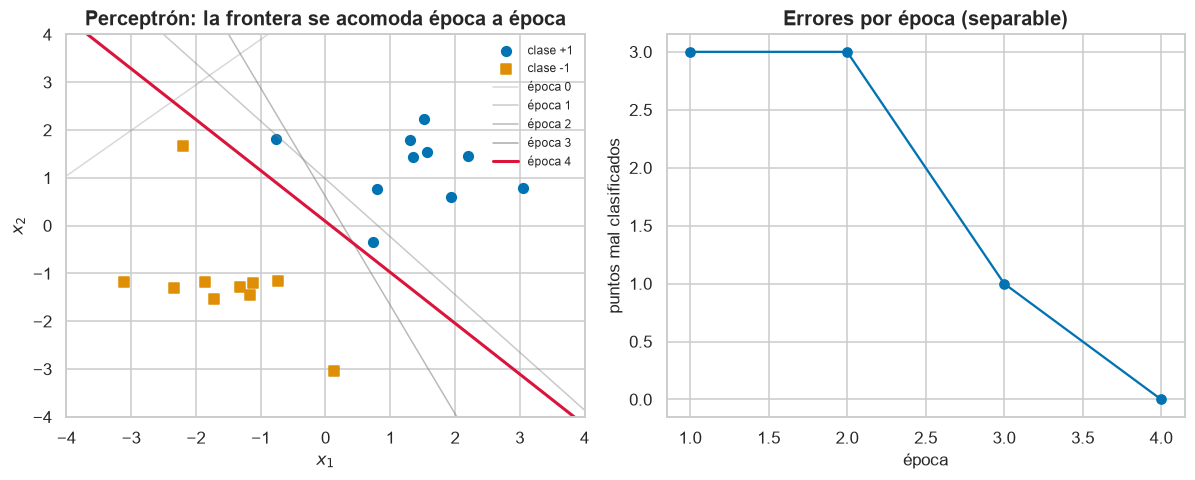

In [24]:
from sklearn.svm import SVC

def perceptron_hyp(X, y, semilla, max_epocas=100):
    # Arranque aleatorio y orden aleatorio de visita: las dos fuentes de no unicidad.
    rng = np.random.default_rng(semilla)
    w = rng.normal(size=X.shape[1])
    b = rng.normal()
    hist, errores = [(w.copy(), b)], []
    for _ in range(max_epocas):
        n_err = 0
        for i in rng.permutation(len(y)):
            if y[i] * (X[i] @ w + b) <= 0:      # mal clasificado: actualiza (4.44), rho = 1
                w, b = w + y[i] * X[i], b + y[i]
                n_err += 1
        errores.append(n_err)
        hist.append((w.copy(), b))
        if n_err == 0:                           # una época sin errores: separó todo
            break
    return w, b, hist, errores

# Datos separables: dos nubes bien distanciadas, 10 puntos por clase.
rng_hyp = np.random.default_rng(3)
X_hyp = np.vstack([rng_hyp.normal([-1.5, -1.0], 0.8, (10, 2)),
                   rng_hyp.normal([1.5, 1.0], 0.8, (10, 2))])
y_hyp = np.array([-1] * 10 + [1] * 10)

w_hyp, b_hyp, hist_hyp, err_hyp = perceptron_hyp(X_hyp, y_hyp, semilla=0)
print("errores por época:", err_hyp)
print("errores finales sobre train:", int(np.sum(y_hyp * (X_hyp @ w_hyp + b_hyp) <= 0)))

def dibujar_recta_hyp(ax, w, b, **kw):
    xs = np.array([-4.0, 4.0])
    if abs(w[1]) > 1e-9:
        ax.plot(xs, -(b + w[0] * xs) / w[1], **kw)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax = axes[0]
ax.scatter(*X_hyp[y_hyp == 1].T, label="clase +1", s=40)
ax.scatter(*X_hyp[y_hyp == -1].T, label="clase -1", s=40, marker="s")
pasos_hyp = np.unique(np.linspace(0, len(hist_hyp) - 1, 5).astype(int))
for k, idx in enumerate(pasos_hyp):
    ultimo = idx == pasos_hyp[-1]
    dibujar_recta_hyp(ax, *hist_hyp[idx], color="crimson" if ultimo else "gray",
                      alpha=1 if ultimo else 0.3 + 0.12 * k, lw=2 if ultimo else 1,
                      label=f"época {idx}")
ax.set(xlim=(-4, 4), ylim=(-4, 4), xlabel="$x_1$", ylabel="$x_2$",
       title="Perceptrón: la frontera se acomoda época a época")
ax.legend(fontsize=8)
axes[1].plot(range(1, len(err_hyp) + 1), err_hyp, marker="o")
axes[1].set(xlabel="época", ylabel="puntos mal clasificados",
            title="Errores por época (separable)")
plt.tight_layout()
plt.show()

En el panel izquierdo, las rectas grises son las fronteras a lo largo de las épocas (más oscuras a medida que avanzan) y la roja es la final. A la derecha, los errores por época bajan hasta cero: es el teorema de convergencia en acción. Con otras semillas pueden subir entre épocas: una actualización que arregla un punto puede romper otros, porque el algoritmo no minimiza la cantidad de errores sino $D$, un punto por vez.

Ahora los otros dos problemas: la **no unicidad** y la **no convergencia** sin separabilidad.

semilla 0: w = [4.32 4.05], b = -0.36, dirección = [0.73 0.68]
semilla 7: w = [2.22 1.22], b = 0.73, dirección = [0.88 0.48]


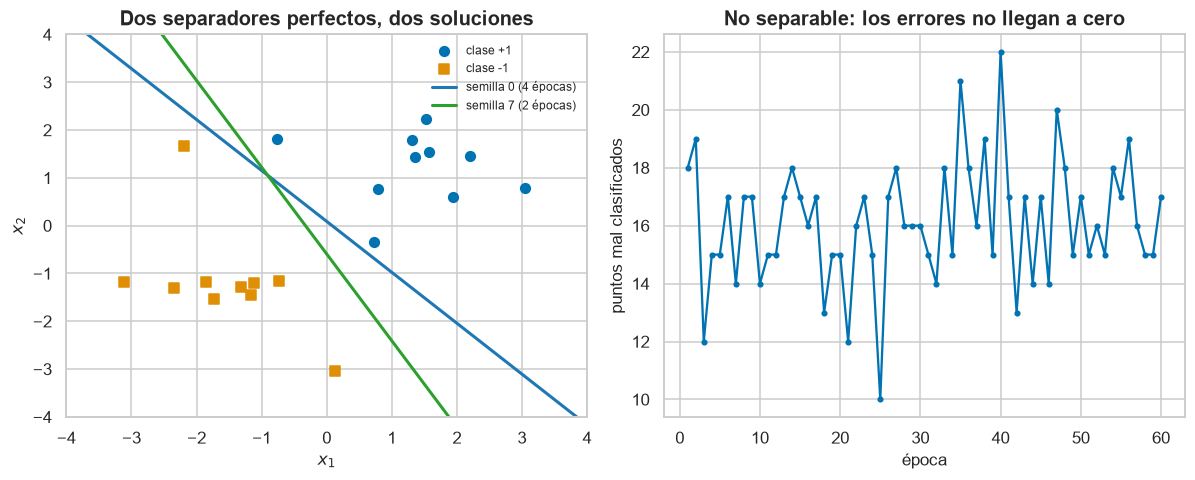

mínimo de errores en una época (no separable): 10 de 60


In [25]:
# (a) Mismos datos, distinta semilla (arranque y orden): dos hiperplanos separadores distintos.
corridas_hyp = [perceptron_hyp(X_hyp, y_hyp, semilla=s) for s in (0, 7)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax = axes[0]
ax.scatter(*X_hyp[y_hyp == 1].T, s=40, label="clase +1")
ax.scatter(*X_hyp[y_hyp == -1].T, s=40, marker="s", label="clase -1")
for (w, b, _, e), col, s in zip(corridas_hyp, ("tab:blue", "tab:green"), (0, 7)):
    dibujar_recta_hyp(ax, w, b, color=col, lw=2, label=f"semilla {s} ({len(e)} épocas)")
    print(f"semilla {s}: w = {np.round(w, 2)}, b = {b:.2f}, dirección = {np.round(w / np.linalg.norm(w), 2)}")
ax.set(xlim=(-4, 4), ylim=(-4, 4), xlabel="$x_1$", ylabel="$x_2$",
       title="Dos separadores perfectos, dos soluciones")
ax.legend(fontsize=8)

# (b) Datos que se solapan: no hay hiperplano separador, el perceptrón cicla.
rng2_hyp = np.random.default_rng(5)
Xn_hyp = np.vstack([rng2_hyp.normal([-0.7, -0.5], 1.0, (30, 2)),
                    rng2_hyp.normal([0.7, 0.5], 1.0, (30, 2))])
yn_hyp = np.array([-1] * 30 + [1] * 30)
_, _, _, err_n_hyp = perceptron_hyp(Xn_hyp, yn_hyp, semilla=0, max_epocas=60)
axes[1].plot(range(1, len(err_n_hyp) + 1), err_n_hyp, marker=".")
axes[1].set(xlabel="época", ylabel="puntos mal clasificados",
            title="No separable: los errores no llegan a cero")
plt.tight_layout()
plt.show()
print("mínimo de errores en una época (no separable):", min(err_n_hyp), "de", len(yn_hyp))

A la izquierda, dos rectas que clasifican **perfectamente** el entrenamiento y sin embargo son distintas: es el primer problema. ¿Cuál generaliza mejor? El perceptrón no tiene cómo decirlo. A la derecha, con clases que se solapan, el conteo de errores salta sin asentarse jamás: es el ciclo del que habla ESL (sólo cortamos por el tope de épocas).

#### ⚠️ Confusión típica

Pensar que "el perceptrón minimiza los errores de clasificación". Minimiza $D$, que pesa cada error por **qué tan lejos** quedó de la frontera. Y sin separabilidad ni siquiera converge a un mínimo de $D$ con paso fijo: cicla.

#### ❓ La pregunta que quedó abierta

Si hay infinitos separadores, ¿hay uno que merezca llamarse "el mejor"? ESL responde en la subsección siguiente: el de mayor **margen**.

### 4.5.2 El hiperplano separador óptimo

**Pregunta guía:** de todos los hiperplanos que separan, ¿cuál elijo? **Respuesta corta:** el que queda **más lejos del punto más cercano de cada clase**, el de la calle más ancha entre las dos nubes (Vapnik; ESL cita Vapnik, 1996). A esa distancia mínima la llamamos **margen**, $M$.

#### La idea en criollo

Pensá en tender una soga entre dos grupos de gente que no quieren mezclarse: no la tensás pegada a un grupo, la dejás lo más centrada posible.

> **Dónde se rompe la analogía.** Con la soga elegís a ojo. Acá hay un problema de optimización bien definido, y la calle puede estar inclinada en muchas dimensiones donde no hay ojo que valga. Y además la calle depende sólo de unos pocos puntos de los bordes, no de "los grupos" en conjunto.

ESL argumenta que esto da una solución única y que, al maximizar el margen en entrenamiento, suele dar **mejor clasificación en test**. Es una intuición, no un teorema.

#### Formalizándolo

**Ojo con una confusión:** (4.45) **no** es una generalización de (4.41). Cambia el criterio. El perceptrón minimiza $D$, y $D=0$ lo logra *cualquier* separador, por eso no puede elegir entre ellos. Acá, entre los separadores, **maximizamos el margen**:

$$\max_{\beta,\beta_0,\|\beta\|=1}M\quad\text{sujeto a}\quad y_i(x_i^T\beta+\beta_0)\ge M,\quad i=1,\dots,N\qquad(4.45)$$

Con $\|\beta\|=1$, $y_if(x_i)$ es la distancia con signo (por (4.40)). Las restricciones dicen: todos los puntos están a distancia al menos $M$ de la frontera, **del lado correcto**. Buscamos el mayor $M$ posible.

**Sacarse de encima $\|\beta\|=1$.** *Qué buscamos:* un problema más cómodo de resolver. Dividimos por la norma en lugar de pedirla igual a 1:

$$\frac{1}{\|\beta\|}y_i(x_i^T\beta+\beta_0)\ge M\ (4.46)\iff y_i(x_i^T\beta+\beta_0)\ge M\|\beta\|\ (4.47)$$

(ESL aclara que esto redefine $\beta_0$ por el reescalado.) Si $(\beta,\beta_0)$ cumple esto, **cualquier múltiplo positivo** también: ambos lados escalan igual. Sobra un grado de libertad, y lo fijamos a gusto con $\|\beta\|=1/M$. Entonces $M\|\beta\|=1$ y queda:

$$\min_{\beta,\beta_0}\tfrac12\|\beta\|^2\quad\text{sujeto a}\quad y_i(x_i^T\beta+\beta_0)\ge1,\quad i=1,\dots,N\qquad(4.48)$$

**Línea clave:** maximizar $M=1/\|\beta\|$ es lo mismo que minimizar $\|\beta\|$, y minimizar $\tfrac12\|\beta\|^2$ es equivalente y más cómodo de derivar (el $\tfrac12$ cancela el 2 de la derivada). Por (4.40), las restricciones definen una **franja vacía** (*slab*) alrededor de la frontera, de $1/\|\beta\|$ de cada lado (ancho total $2M$). Es un problema **convexo** (criterio cuadrático, restricciones lineales de desigualdad): tiene una única solución.

#### ¿Por qué pasar al dual?

**Pregunta:** (4.48) ya es un problema bien planteado, ¿para qué cambiarlo? Por dos razones, que se ven al terminar la cuenta. **(i)** En la versión transformada los datos entran **sólo a través de productos internos** $x_i^Tx_k$: eso es lo que en el cap. 12 permite reemplazarlos por otros productos y curvar la frontera sin cambiar el algoritmo. **(ii)** La solución resulta depender de **muy pocos puntos**, así que la frontera queda descripta por un puñado de observaciones. El camino es la técnica de Lagrange.

**Lagrangiano.** Es la técnica para minimizar con restricciones: cada restricción se suma multiplicada por un número $\alpha_i\ge0$ (un **multiplicador**, "alfa i"), de modo que violarla "cuesta". Es la misma herramienta que ya viste con las formas lagrangianas de ridge y lasso, sólo que ahora hay un $\alpha_i$ por observación. Cada restricción es $y_i(x_i^T\beta+\beta_0)-1\ge0$, y la función a minimizar respecto de $\beta$ y $\beta_0$ (**primal**) es

$$L_P=\tfrac12\|\beta\|^2-\sum_{i=1}^N\alpha_i\left[y_i(x_i^T\beta+\beta_0)-1\right]\qquad(4.49)$$

Derivamos e igualamos a cero. Respecto de $\beta$: $\beta-\sum_i\alpha_iy_ix_i=0$. Respecto de $\beta_0$: $-\sum_i\alpha_iy_i=0$. O sea,

$$\beta=\sum_{i=1}^N\alpha_iy_ix_i\ (4.50),\qquad0=\sum_{i=1}^N\alpha_iy_i\ (4.51)$$

**Línea clave: (4.50) dice que $\beta$ es una combinación de los puntos, con pesos $\alpha_i$.**

**El dual.** Reemplazamos (4.50) y (4.51) en (4.49) para eliminar $\beta$ y $\beta_0$. Abrimos: $L_P=\tfrac12\|\beta\|^2-\sum_i\alpha_iy_ix_i^T\beta-\beta_0\sum_i\alpha_iy_i+\sum_i\alpha_i$. Por (4.51) el término con $\beta_0$ vale cero. Por (4.50), $\sum_i\alpha_iy_ix_i^T\beta=\|\beta\|^2$. Queda $\sum_i\alpha_i-\tfrac12\|\beta\|^2$, y escribiendo $\|\beta\|^2=\sum_i\sum_k\alpha_i\alpha_ky_iy_kx_i^Tx_k$ (por (4.50), dos veces):

$$L_D=\sum_{i=1}^N\alpha_i-\tfrac12\sum_{i=1}^N\sum_{k=1}^N\alpha_i\alpha_ky_iy_kx_i^Tx_k\quad\text{sujeto a }\alpha_i\ge0,\ \sum_i\alpha_iy_i=0\qquad(4.52)$$

Es el **dual de Wolfe**: el mismo problema escrito sólo en términos de los $\alpha_i$. Se **maximiza**, y es un problema convexo más simple para el que hay software estándar. **Línea clave: $\beta$ y $\beta_0$ desaparecieron y los datos aparecen sólo como $x_i^Tx_k$.** Esa es la razón (i) de arriba, y la puerta al capítulo 12.

**Condiciones KKT.** Las de Karush–Kuhn–Tucker son las condiciones que tiene que cumplir el óptimo de un problema con restricciones de desigualdad. Ya tenemos varias: (4.50), (4.51), $\alpha_i\ge0$ y las restricciones originales. Falta la que explica la razón (ii), la **holgura complementaria**:

$$\alpha_i\left[y_i(x_i^T\beta+\beta_0)-1\right]=0\quad\forall i\qquad(4.53)$$

*Por qué aparece:* si una restricción está **floja** (el punto está estrictamente adentro), moverla no cambia el óptimo, así que su multiplicador tiene que valer cero. Si $\alpha_i>0$, la restricción está **activa**: se cumple con igualdad. Un producto que da cero significa que un factor es cero:

- si $\alpha_i>0$, entonces $y_i(x_i^T\beta+\beta_0)=1$: el punto está **justo sobre el borde de la franja**;
- si $y_i(x_i^T\beta+\beta_0)>1$, el punto está adentro de su zona y $\alpha_i=0$.

Los $x_i$ con $\alpha_i>0$ se llaman **puntos soporte** (*support points*): son los que "sostienen" la franja. **Línea clave: por (4.50), $\beta$ es una combinación lineal de los puntos soporte; el resto no influye.** $\beta_0$ se despeja de (4.53) en cualquier punto soporte. Se clasifica con

$$\hat G(x)=\operatorname{sign}\hat f(x),\quad\hat f(x)=x^T\hat\beta+\hat\beta_0\qquad(4.54)$$

Ningún punto de entrenamiento cae dentro de la franja (por construcción), pero los de test sí pueden.

#### ¿Por qué nos importa?

Resuelve la no unicidad del perceptrón y cambia la mirada sobre qué datos importan. La solución del hiperplano se define con los puntos soporte, "se concentra en los puntos que cuentan"; LDA, en cambio, depende de **todos** los datos, incluso los lejanos a la frontera. ESL advierte dos cosas: identificar los soportes requirió usar todos los datos, y si las clases son realmente gaussianas, LDA es óptimo y el hiperplano separador paga el precio de fijarse en los datos de borde, que son los más ruidosos.

**Relación con la logística.** Cuando hay un hiperplano separador, la logística **sin penalizar no tiene estimador de máxima verosimilitud**: la log-verosimilitud puede llevarse hacia 0 (su máximo, ESL Ejercicio 4.5) sólo mandando $\|\hat\beta\|\to\infty$, y nunca se alcanza a distancia finita. Solo se estabiliza la **dirección** de $\hat\beta$ (ver 4.4.5). En el ejemplo de ESL (Fig. 4.16) esa solución y la de margen máximo son muy parecidas, y ESL señala un rasgo común: la logística pondera más a los puntos cerca de la frontera que a los lejanos. Cuando **no** hay separabilidad, (4.48) no tiene solución factible; ESL propone el *support vector machine* del cap. 12, que permite solapamiento y minimiza una medida de cuánto se solapa.

#### En código

Primero resolvemos a mano el dual (4.52) con `scipy.optimize.minimize` (cuadrático, con $\alpha_i\ge0$ y la restricción lineal $\sum_i\alpha_iy_i=0$). De ahí sacamos $\beta$ con (4.50) y $\beta_0$ despejando (4.53) en un punto soporte (el de mayor $\alpha_i$).

In [26]:
from scipy.optimize import minimize

# Dual (4.52): maximizar sum(alpha) - 1/2 alpha' Q alpha, con Q_ik = y_i y_k x_i.x_k, alpha >= 0 y sum(alpha_i y_i) = 0.
Q_dual = (y_hyp[:, None] * X_hyp) @ (y_hyp[:, None] * X_hyp).T
res_dual = minimize(lambda a: 0.5 * a @ Q_dual @ a - a.sum(), np.zeros(len(y_hyp)),
                    jac=lambda a: Q_dual @ a - 1, bounds=[(0, None)] * len(y_hyp),
                    constraints={"type": "eq", "fun": lambda a: a @ y_hyp}, method="SLSQP")
alpha_dual = res_dual.x
beta_dual = (alpha_dual * y_hyp) @ X_hyp                  # (4.50)
s_dual = np.argmax(alpha_dual)                            # un punto soporte
beta0_dual = y_hyp[s_dual] - X_hyp[s_dual] @ beta_dual    # despejar (4.53) en un soporte (y_i = +-1)
print("converge:", res_dual.success)
print("soportes (alpha > 1e-6):", np.where(alpha_dual > 1e-6)[0])
print("beta:", beta_dual.round(3), "| beta0:", round(beta0_dual, 3))
print("(4.51) sum alpha_i y_i =", round(alpha_dual @ y_hyp, 8))

converge: True
soportes (alpha > 1e-6): [ 4  9 18]
beta: [1.324 0.684] | beta0: 0.766
(4.51) sum alpha_i y_i = -0.0


#### 🏭 Así se hace en la industria

`sklearn.svm.SVC(kernel="linear", C=1e10)` resuelve (4.48). Con $C$ enorme el solver no tolera ninguna violación del margen, que reproduce el margen duro de esta sección ($C$ cobra sentido recién en el cap. 12). **Verificamos a mano** lo que derivamos: los soportes están a distancia $1/\|\beta\|$, vale (4.50) y (4.51), $\alpha_i>0$ sólo en los soportes, y coincide con el dual de recién.

In [27]:
svm_hyp = SVC(kernel="linear", C=1e10).fit(X_hyp, y_hyp)
beta_hyp = svm_hyp.coef_[0]
beta0_hyp = svm_hyp.intercept_[0]
norma_hyp = np.linalg.norm(beta_hyp)
f_hyp = X_hyp @ beta_hyp + beta0_hyp                  # f(x) = x^T beta + beta_0
sop_hyp = svm_hyp.support_                            # índices de los puntos soporte

# sklearn guarda alpha_i * y_i para los soportes (dual_coef_).
ay_hyp = svm_hyp.dual_coef_[0]
print("puntos soporte (índices):", sop_hyp)
print("margen 1/||beta||:", round(1 / norma_hyp, 4))
print("y_i f(x_i) en soportes (debe ser 1):", np.round(y_hyp[sop_hyp] * f_hyp[sop_hyp], 4))
print("distancia con signo de soportes (debe ser 1/||beta||):",
      np.round(y_hyp[sop_hyp] * f_hyp[sop_hyp] / norma_hyp, 4))
no_sop_hyp = np.setdiff1d(np.arange(len(y_hyp)), sop_hyp)
print("y_i f(x_i) mínimo entre no soportes (debe ser > 1):",
      round((y_hyp[no_sop_hyp] * f_hyp[no_sop_hyp]).min(), 4))
print("KKT (4.50): beta == sum alpha_i y_i x_i ->",
      np.allclose(beta_hyp, ay_hyp @ X_hyp[sop_hyp]))
print("KKT (4.51): sum alpha_i y_i == 0        ->", np.isclose(ay_hyp.sum(), 0, atol=1e-6))
print("alpha_i >= 0 (alpha_i y_i con el signo de y_i) ->",
      bool(np.all(ay_hyp * y_hyp[sop_hyp] > 0)))
print("dual a mano == SVC: beta", np.allclose(beta_dual, beta_hyp, atol=1e-2),
      "| beta0", np.isclose(beta0_dual, beta0_hyp, atol=1e-2),
      "| mismos soportes", set(np.where(alpha_dual > 1e-6)[0]) == set(sop_hyp))

puntos soporte (índices): [ 4  9 18]
margen 1/||beta||: 0.6713
y_i f(x_i) en soportes (debe ser 1): [0.9999 1.0003 1.0001]
distancia con signo de soportes (debe ser 1/||beta||): [0.6712 0.6715 0.6714]
y_i f(x_i) mínimo entre no soportes (debe ser > 1): 1.1444
KKT (4.50): beta == sum alpha_i y_i x_i -> True
KKT (4.51): sum alpha_i y_i == 0        -> True
alpha_i >= 0 (alpha_i y_i con el signo de y_i) -> True
dual a mano == SVC: beta True | beta0 True | mismos soportes True


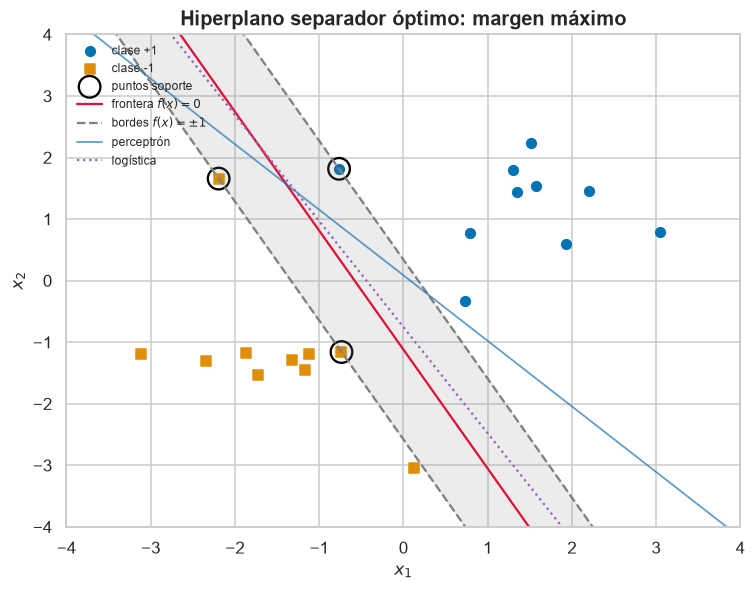

perceptrón s=0   margen = 0.2439
perceptrón s=7   margen = 0.4951
óptimo (SVC)     margen = 0.6712
logística        margen = 0.6301


In [28]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(*X_hyp[y_hyp == 1].T, s=40, label="clase +1")
ax.scatter(*X_hyp[y_hyp == -1].T, s=40, marker="s", label="clase -1")
ax.scatter(*X_hyp[sop_hyp].T, s=200, facecolors="none", edgecolors="black",
           linewidths=1.5, label="puntos soporte")
xs = np.array([-4.0, 4.0])
for nivel, estilo, etiqueta in ((0, "-", "frontera $f(x)=0$"),
                                (1, "--", "bordes $f(x)=\\pm 1$"), (-1, "--", None)):
    ax.plot(xs, -(beta0_hyp - nivel + beta_hyp[0] * xs) / beta_hyp[1],
            color="crimson" if nivel == 0 else "gray", ls=estilo, label=etiqueta)
ax.fill_between(xs, -(beta0_hyp - 1 + beta_hyp[0] * xs) / beta_hyp[1],
                -(beta0_hyp + 1 + beta_hyp[0] * xs) / beta_hyp[1], color="gray", alpha=0.15)
# Para comparar: uno de los separadores del perceptrón.
dibujar_recta_hyp(ax, *corridas_hyp[0][:2], color="tab:blue", lw=1.2, alpha=0.7, label="perceptrón")
# Logística sin penalizar (C enorme): converge hacia un separador; su dirección se estabiliza aunque ||beta|| crece.
lr_hyp = LogisticRegression(C=1e10, max_iter=10000).fit(X_hyp, y_hyp)
b_lr, b0_lr = lr_hyp.coef_[0], lr_hyp.intercept_[0]
dibujar_recta_hyp(ax, b_lr, b0_lr, color="tab:purple", lw=1.5, ls=":", label="logística")
ax.set(xlim=(-4, 4), ylim=(-4, 4), xlabel="$x_1$", ylabel="$x_2$",
       title="Hiperplano separador óptimo: margen máximo")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

# Margen mínimo (distancia al punto más cercano) del perceptrón vs. el óptimo.
for nombre, (w, b) in (("perceptrón s=0", corridas_hyp[0][:2]), ("perceptrón s=7", corridas_hyp[1][:2]),
                       ("óptimo (SVC)", (beta_hyp, beta0_hyp)),
                       ("logística", (b_lr, b0_lr))):
    print(f"{nombre:16s} margen = {(y_hyp * (X_hyp @ w + b) / np.linalg.norm(w)).min():.4f}")

En el gráfico, los puntos con círculo negro son los soportes: caen sobre las rectas punteadas ($f=\pm1$), salvo la tolerancia numérica del solver, y la frontera roja pasa por la mitad de la franja gris. Los demás puntos no tocan la franja: si los movés un poco sin cruzar el borde, el hiperplano no cambia. En el último `print`, el margen del hiperplano óptimo es el mayor; los dos del perceptrón quedan por debajo (separan bien, pero sin garantía de holgura). La recta violeta punteada es la logística sin penalizar: queda cerca de la del margen óptimo, no idéntica (el `print` da su margen, algo menor), y es lo que anticipa ESL en su Fig. 4.16.

#### ⚠️ Confusión típica

Creer que los $\alpha_i$ o los soportes se pueden conocer **antes** de resolver: son un resultado del problema, no un filtro previo. Y suponer que $\|\beta\|=1/M$ es una condición del problema: es una elección arbitraria de escala, permitida porque los múltiplos positivos de $(\beta,\beta_0)$ definen el mismo hiperplano.

#### ❓ La pregunta que quedó abierta

Sin separabilidad, (4.48) no tiene solución factible. ¿Qué hacemos? Ampliar la base puede dar separación artificial por sobreajuste. La salida del libro es el *support vector machine* del 📕 ESL cap. 12, que tolera solapamiento pero penaliza cuánto se solapa. Ahí cobra sentido el $C$ que dejamos "infinito".

## 🧵 El hilo conductor

Todo el capítulo responde una pregunta: ¿cómo trazamos fronteras lineales entre clases? Para dos clases, todas terminan en la **misma forma**, $\hat G(x)=\operatorname{sign}(\beta_0+\beta^Tx)$, y difieren en **cómo eligen $\beta$** (Fig. 4.14 y 4.16 de ESL muestran los contrastes). Hay dos caminos:

- **Generativo:** modela cómo se generan los $X$ dentro de cada clase y aplica Bayes (LDA, QDA, RDA, §4.3). LDA usa todos los datos, asumiendo gaussianas con covarianza común; esferizando (§4.3.2) se reduce a "centroide más cercano", y los centroides viven en un subespacio de a lo sumo $K-1$ dimensiones (§4.3.3).
- **Discriminativo:** modela directamente $\Pr(G\mid X)$ (logística, §4.4) o directamente la frontera, sin probabilidades (§4.5). La logística maximiza una verosimilitud y sirve además para interpretar (Z-scores, odds ratios, deviance: §4.4.2 a 4.4.3). El perceptrón se conforma con cualquier separador, y el hiperplano óptimo elige el de mayor margen apoyándose sólo en los puntos soporte. **Cuando es separable, la logística sin penalizar queda muy cerca del hiperplano de margen** (su $\hat\beta$ ni existe, pero la dirección se estabiliza): la Fig. 4.16 de ESL las muestra muy parecidas y la celda del margen de §4.5.2 lo confirma con números.

La regresión sobre indicadoras (§4.2) es el punto de partida ingenuo, y su falla (*masking*) motiva todo lo demás. En dos clases, su vector de coeficientes es proporcional al de LDA; el corte coincide solo si las clases están balanceadas (§4.3, Extra).

**Con las clases previas.**

- *Clase 1:* todo el capítulo es la teoría de la decisión con los modelos puestos (regla de Bayes, matriz de pérdida, familias generativa / discriminativa / funciones discriminantes). El perceptrón y el hiperplano óptimo son la tercera familia, y como no modelan probabilidades no dan una medida de confianza.
- *Clases 2 y 3:* mínimos cuadrados e IRLS, máxima verosimilitud y SVD son la maquinaria de §4.2 a 4.4; el perceptrón es un SGD con otro "error".
- *Clases 4 y 5:* la regularización reaparece en RDA y en la logística L1. El margen máximo da vuelta los roles: se minimiza $\|\beta\|$ con el ajuste como restricción, y en vez de apagar variables (lasso) se apagan observaciones (los $\alpha_i=0$).

Seguimos hacia el capítulo 5 (expansiones de base) y el cap. 12 (SVM), que llevan estas fronteras a espacios no lineales.

## ✅ Autoevaluación

Son 10 preguntas, ordenadas por sección del capítulo. Las 3, 6 y 10 piden hacer la cuenta, y la 7, la 8 y la 9 son del tipo "¿qué pasa si...?". Intentá antes de abrir cada respuesta.

### §4.2 Regresión lineal sobre indicadoras

**1.** ¿Por qué la regresión sobre indicadoras puede fallar con $K\ge3$ aunque las clases sean separables linealmente?

<details><summary>Respuesta</summary>

Por *masking*: con $K=3$ y una clase en el medio, su ajuste lineal $\hat f_k$ es una recta que queda por debajo de la de alguna de las otras dos en todo el rango, así que nunca es la mayor y esa clase no se predice jamás. Las clases *sí* son separables linealmente, pero la regresión lineal sobre indicadoras no minimiza errores de clasificación, minimiza cuadrados. Se arregla agregando términos de grado mayor (el libro indica que grado $K-1$ puede hacer falta en el peor caso), o usando LDA o logística.

</details>

### §4.3 LDA y QDA (con RDA, §4.3.1)

**2.** ¿Qué supuesto hace que las fronteras de LDA sean lineales? ¿Y qué le pasa a la frontera si lo relajás de a poco con el parámetro $\alpha$ de RDA (§4.3.1)?

<details><summary>Respuesta</summary>

Densidades gaussianas por clase con **la misma** matriz de covarianza $\Sigma$: al comparar $\log\Pr(G=k\mid x)$ entre dos clases, el término cuadrático $x^T\Sigma^{-1}x$ se cancela y queda una función lineal. RDA interpola, $\hat\Sigma_k(\alpha)=\alpha\hat\Sigma_k+(1-\alpha)\hat\Sigma$: con $\alpha=0$ es LDA (frontera lineal), con $\alpha=1$ es QDA (cuadrática), y en el medio la frontera se va curvando de a poco. $\alpha$ se elige por validación.

</details>

**3.** Con $p=10$ predictores y $K=3$ clases, contá los parámetros de LDA y de QDA.

<details><summary>Respuesta</summary>

LDA: medias $K p=30$, $\Sigma$ común $p(p+1)/2=55$, priors $K-1=2$, en total 87. QDA: medias 30, una $\Sigma_k$ por clase $3\cdot55=165$, priors 2, en total 197. Son las fórmulas $Kp+p(p+1)/2+(K-1)$ y $Kp+K\,p(p+1)/2+(K-1)$ de la notebook (§4.3, "Costo en parámetros"). Ojo: si contás sólo lo que determina la frontera (las diferencias $\delta_k-\delta_K$, como hace ESL) son $(K-1)(p+1)=22$ para LDA y $(K-1)\{p(p+3)/2+1\}=132$ para QDA. Son dos cuentas de cosas distintas, y en las dos QDA necesita muchos más parámetros, por eso necesita más datos.

</details>

### §4.3.1–4.3.3 RDA, cómputo de LDA y rango reducido

**4.** ¿Cuántas dimensiones como máximo tiene el subespacio de LDA de rango reducido y por qué? ¿Por qué reducirlo puede mejorar el error de test?

<details><summary>Respuesta</summary>

$\min(p, K-1)$: los $K$ centroides generan un subespacio afín de dimensión a lo sumo $K-1$, y toda la información discriminante (con $\Sigma$ común) vive ahí. Reducir más regulariza: cada discriminante extra agrega parámetros por estimar, y si casi no separa clases la varianza que se agrega no compensa (la Fig. 4.10 de las vocales tiene el mejor test en dimensión 2, no en 10).

</details>

### §4.4 Regresión logística

**5.** En IRLS para logística, ¿por qué hay que *re*ponderar y qué pesos aparecen?

<details><summary>Respuesta</summary>

El Hessiano es $-\mathbf X^T\mathbf W\mathbf X$ con $W_{ii}=p_i(1-p_i)$. El paso de Newton equivale a resolver un problema de cuadrados mínimos ponderados sobre la respuesta ajustada $\mathbf z$, y en cada iteración cambia $p_i$, así que cambian tanto los pesos $\mathbf W$ como la respuesta $\mathbf z$.

</details>

**6.** En nuestro ajuste de riesgo coronario (§4.4.2, datos simulados), el coeficiente de `tobacco` es $0{,}096$ con error estándar $0{,}032$. ¿Por cuánto se multiplican los odds por cada unidad más? Dá un intervalo aproximado al 95 %.

<details><summary>Respuesta</summary>

El logit es lineal en `tobacco`, así que +1 unidad suma $0{,}096$ al log-odds y multiplica los odds por $e^{0{,}096}=1{,}10$ (+10 %). El intervalo sale de $0{,}096\pm2\cdot0{,}032=(0{,}032;\,0{,}160)$, y exponenciando, $(1{,}03;\,1{,}17)$. Es un cambio en los *odds*, no en la probabilidad. El $Z=0{,}096/0{,}032\approx3$ supera 2, así que el coeficiente es significativo al 5 %. (El libro, con los datos reales de Sudáfrica, da $0{,}081$ con error estándar $0{,}026$: misma cuenta, odds $\times1{,}08$, intervalo $(1{,}03;\,1{,}14)$, $Z\approx3{,}1$.)

</details>

**7.** En `sklearn`, ¿qué les pasa a los coeficientes de una logística L1 si bajás $C$ de $10$ a $0{,}01$? ¿Qué relación tiene $C$ con el $\lambda$ del libro?

<details><summary>Respuesta</summary>

$C=1/\lambda$, así que bajar $C$ es subir $\lambda$: más penalidad, coeficientes más chicos y cada vez más ceros exactos (las variables salen una a una, las menos informativas primero: en el camino de §4.4.4, `alcohol`, luego `obesity` y `sbp`, y al final `age`, `famhist` y `tobacco`). Con $C$ muy chico todos los coeficientes quedan en cero: pasa cuando $\lambda\ge\max_j|x_j^T(\mathbf y-\hat{\mathbf p}_0)|$, con $\hat{\mathbf p}_0=\bar y$ (el modelo con solo intercepto), o sea $C\le1/\lambda_{\max}$; en nuestros datos $1/\lambda_{\max}=0{,}0117$, así que con $C=0{,}01$ ya no queda ninguna variable. Para las variables activas vale (4.32), $x_j^T(\mathbf y-\mathbf p)=\lambda\,\mathrm{sign}(\beta_j)$: todas las activas empatan en su correlación con el residuo.

</details>

**8.** ¿Qué pasa con la logística sin regularizar si las clases son perfectamente separables? ¿Y si le agregás una penalización L2?

<details><summary>Respuesta</summary>

El máximo de la verosimilitud no existe a distancia finita: $\|\hat\beta\|\to\infty$, las probabilidades tienden a 0 y 1 y IRLS no converge a nada estable (los errores estándar explotan). Lo que sí se estabiliza es la *dirección* de $\hat\beta$, que apunta a un hiperplano separador. LDA, en cambio, da estimaciones finitas para los mismos datos. Con una penalización L2 (el $C$ finito de `sklearn`) el óptimo vuelve a existir y es finito.

</details>

**9.** ¿Qué pasa si los datos no son gaussianos: LDA o logística?

<details><summary>Respuesta</summary>

La logística suele ser una apuesta más segura: no asume nada sobre la distribución de $X$, sólo que el logit es lineal. LDA aprovecha esa información extra cuando es cierta (más eficiente: el libro calcula hasta alrededor de 30 % de pérdida de eficiencia en la tasa de error si se ignora) y se degrada cuando no, sobre todo con outliers groseros. Pero el libro agrega que en su experiencia ambos modelos dan resultados muy parecidos aun cuando LDA se usa de forma inapropiada (p. ej. con predictores cualitativos). En nuestra simulación de §4.4.5: con datos gaussianos empataron (24,5 %); con lognormales la diferencia fue de un punto (27,8 % contra 26,7 %); con outliers LDA perdió bastante más (37,0 % contra 31,7 %).

</details>

### §4.5 Hiperplanos separadores

**10.** Sea el hiperplano $f(x)=-5+3x_1+4x_2$ y el punto $x=(3,\,2)$ con etiqueta $y=-1$. (a) ¿A qué distancia de la frontera está $x$? ¿Lo clasifica bien? (b) Si fuera un paso del perceptrón con $\rho=1$, ¿cómo quedan $\beta$ y $\beta_0$? (c) Si $\beta$ define un hiperplano con margen $M$ y $\|\beta\|=1/M$ (normalización del libro), ¿qué propiedad tienen los vectores soporte?

<details><summary>Respuesta</summary>

(a) $f(x)=-5+9+8=12$. Como $\|\beta\|=\sqrt{3^2+4^2}=5$, la distancia con signo es $12/5=2{,}4$, del lado positivo. La etiqueta es $-1$, así que $y\,f(x)=-12<0$: está mal clasificado. (b) Actualización (4.44) con $\rho=1$: $\beta\leftarrow(3,4)+(-1)(3,2)=(0,2)$ y $\beta_0\leftarrow-5+(-1)=-6$. El nuevo $f(x)=-6+0\cdot3+2\cdot2=-2$: ahora $y\,f(x)=2>0$, bien clasificado con un solo paso. (c) Los vectores soporte están exactamente a distancia $M=1/\|\beta\|$ del hiperplano, y son los únicos puntos con multiplicador de Lagrange $\alpha_i>0$ (condiciones KKT); la solución es combinación lineal sólo de ellos.

</details>